# INTERP

## Old

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import seaborn as sns
import os

if os.path.exists('output/ism/') is False:
    os.makedirs('output/ism/')

def visualize_crispr_data(ism_path, influence_path, 
                          ism_crop_min=None, ism_crop_max=None, 
                          inf_crop_min=None, inf_crop_max=None, 
                          delta=None, i=None):
    
    # --- Helper Function for Drawing Logos ---
    def draw_logo(ax, df, x_col='Pos', cols=['> A', '> C', '> G', '> T']):
        letters = {}
        for char in ['A', 'C', 'G', 'T']:
            tp = TextPath((0, 0), char, size=1)
            bbox = tp.get_extents()
            trans = Affine2D().translate(-bbox.x0, -bbox.y0).scale(1/bbox.width, 1/bbox.height)
            letters[char] = tp.transformed(trans)

        colors = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
        ref_col = next((c for c in ['WT', 'Ref', 'Base', 'Reference'] if c in df.columns), None)

        for idx, row in df.iterrows():
            x_pos = row[x_col]
            scores = {c[-1]: row[c] for c in cols}
            wt_char = row[ref_col] if ref_col else None
            
            pos_scores = sorted({k: v for k, v in scores.items() if v >= 0}.items(), key=lambda x: x[1])
            neg_scores = sorted({k: v for k, v in scores.items() if v < 0}.items(), key=lambda x: abs(x[1]))
            
            def plot_stack(stack_scores, y_start):
                curr_y = y_start
                for char, h in stack_scores:
                    if abs(h) < 1e-6: continue
                    
                    if wt_char and char == wt_char:
                        linewidth = 1.0; edgecolor = 'black'; zorder = 10
                    else:
                        linewidth = 0; edgecolor = 'none'; zorder = 1

                    path = letters[char]
                    trans = Affine2D().scale(0.7, h).translate(x_pos - 0.35, curr_y)
                    patch = PathPatch(path, facecolor=colors[char], edgecolor=edgecolor, linewidth=linewidth, transform=trans + ax.transData, zorder=zorder)
                    ax.add_patch(patch)
                    curr_y += h

            plot_stack(pos_scores, 0)
            plot_stack(neg_scores, 0)
                
        ax.set_xlim(df[x_col].min() - 0.5, df[x_col].max() + 0.5)
        ax.autoscale_view()

    # --- 1. Process ISM ---
    print(f"Processing ISM file: {ism_path}")
    df_ism = pd.read_csv(ism_path)
    score_cols = ['> A', '> C', '> G', '> T']
    
    means = df_ism[score_cols].mean(axis=1)
    df_norm = df_ism.copy()
    for col in score_cols:
        df_norm[col] = df_ism[col] - means

    if ism_crop_min is not None and ism_crop_max is not None:
        mask_min = df_norm['Pos'] >= ism_crop_min
        mask_max = df_norm['Pos'] < ism_crop_max
        if mask_min.any() and mask_max.any():
            start_row = df_norm[mask_min].index[0]
            end_row = df_norm[mask_max].index[-1] + 1
            df_norm = df_norm.iloc[start_row:end_row]
        
    fig, ax = plt.subplots(figsize=(10, 5))
    draw_logo(ax, df_norm)
    
    cut_pos = 46.5
    ax.axvline(x=cut_pos, color='black', linestyle='--', linewidth=2, label='Cut Site')
    
    ax.set_xlabel("Position", fontsize=20)
    ax.set_ylabel("ISM Score", fontsize=20)
    plt.tight_layout()
    plt.savefig(f'output/ism/ism_logo_delta_{delta}_run_{i}.pdf')
    plt.show()
    plt.close()
    
    # --- 2. Process Influence Map ---
    print(f"Processing Influence file: {influence_path}")
    df_inf = pd.read_csv(influence_path)
    
    if inf_crop_min is not None and inf_crop_max is not None:
        df_inf = df_inf.iloc[inf_crop_min:inf_crop_max, inf_crop_min:inf_crop_max]
    
    grid_kws = {"height_ratios": (.05, .95), "hspace": .3}
    f, (ax_cbar, ax_heatmap) = plt.subplots(2, gridspec_kw=grid_kws, figsize=(10, 10))
    
    sns.heatmap(df_inf, 
                ax=ax_heatmap,
                cbar_ax=ax_cbar,
                cmap='coolwarm', 
                center=0, 
                xticklabels=True, # Ensure labels are generated
                yticklabels=True,
                cbar_kws={
                    'label': 'Pairwise Interaction Score', 
                    'orientation': 'horizontal'
                })
    
    # Colorbar formatting - Larger font (20) for label
    ax_cbar.set_xlabel('Pairwise Interaction Score', fontsize=30, labelpad=10)
    ax_cbar.xaxis.set_label_position('top') 
    ax_cbar.tick_params(labelsize=14)

    # --- NEW: X and Y Ticks formatting (Every 5th label, big font) ---
    def format_ticks(ax_target, axis_type='x'):
        # Step 1: Set larger font (18) for all labels initially
        ax_target.tick_params(axis=axis_type, labelsize=18)
        
        labels = ax_target.get_xticklabels() if axis_type == 'x' else ax_target.get_yticklabels()
        
        # Step 2: Loop through and hide labels not divisible by 5
        for n, label in enumerate(labels):
            try:
                val = int(label.get_text())
                if val % 5 != 0:
                    label.set_visible(False)
            except ValueError:
                if n % 5 != 0:
                    label.set_visible(False)

    format_ticks(ax_heatmap, 'x')
    format_ticks(ax_heatmap, 'y')

    # Optionally adjust tick length to distinguish them visually
    ax_heatmap.tick_params(axis='both', which='major', length=4)
    
    plt.tight_layout()
    plt.savefig(f'output/ism/influence_map_delta_{delta}_run_{i}.pdf')
    plt.savefig(f'output/ism/influence_map_delta_{delta}_run_{i}.svg')
    plt.show()
    plt.close()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import seaborn as sns
import os

if os.path.exists('output/ism/') is False:
    os.makedirs('output/ism/')

def visualize_crispr_data_wide(ism_path, influence_path, 
                          ism_crop_min=None, ism_crop_max=None, 
                          inf_crop_min=None, inf_crop_max=None, 
                          delta=None, i=None):
    
    # --- Helper Function for Drawing Logos ---
    def draw_logo(ax, df, x_col='Pos', cols=['> A', '> C', '> G', '> T']):
        letters = {}
        for char in ['A', 'C', 'G', 'T']:
            tp = TextPath((0, 0), char, size=1)
            bbox = tp.get_extents()
            trans = Affine2D().translate(-bbox.x0, -bbox.y0).scale(1/bbox.width, 1/bbox.height)
            letters[char] = tp.transformed(trans)

        colors = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
        ref_col = next((c for c in ['WT', 'Ref', 'Base', 'Reference'] if c in df.columns), None)

        for idx, row in df.iterrows():
            x_pos = row[x_col]
            scores = {c[-1]: row[c] for c in cols}
            wt_char = row[ref_col] if ref_col else None
            
            pos_scores = sorted({k: v for k, v in scores.items() if v >= 0}.items(), key=lambda x: x[1])
            neg_scores = sorted({k: v for k, v in scores.items() if v < 0}.items(), key=lambda x: abs(x[1]))
            
            def plot_stack(stack_scores, y_start):
                curr_y = y_start
                for char, h in stack_scores:
                    if abs(h) < 1e-6: continue
                    
                    if wt_char and char == wt_char:
                        linewidth = 1.0; edgecolor = 'black'; zorder = 10
                    else:
                        linewidth = 0; edgecolor = 'none'; zorder = 1

                    path = letters[char]
                    # Kept your original 0.7 scale/0.35 offset
                    trans = Affine2D().scale(0.7, h).translate(x_pos - 0.35, curr_y)
                    patch = PathPatch(path, facecolor=colors[char], edgecolor=edgecolor, linewidth=linewidth, transform=trans + ax.transData, zorder=zorder)
                    ax.add_patch(patch)
                    curr_y += h

            plot_stack(pos_scores, 0)
            plot_stack(neg_scores, 0)
                
        ax.set_xlim(df[x_col].min() - 0.5, df[x_col].max() + 0.5)
        ax.autoscale_view()

    # --- 1. Process ISM ---
    print(f"Processing ISM file: {ism_path}")
    df_ism = pd.read_csv(ism_path)
    score_cols = ['> A', '> C', '> G', '> T']
    
    means = df_ism[score_cols].mean(axis=1)
    df_norm = df_ism.copy()
    for col in score_cols:
        df_norm[col] = df_ism[col] - means

    if ism_crop_min is not None and ism_crop_max is not None:
        mask_min = df_norm['Pos'] >= ism_crop_min
        mask_max = df_norm['Pos'] < ism_crop_max
        if mask_min.any() and mask_max.any():
            start_row = df_norm[mask_min].index[0]
            end_row = df_norm[mask_max].index[-1] + 1
            df_norm = df_norm.iloc[start_row:end_row]
        
    # WIDER FIGURE: Increased width from 10 to 20
    fig, ax = plt.subplots(figsize=(20, 6)) 
    draw_logo(ax, df_norm)
    
    cut_pos = 46.5
    ax.axvline(x=cut_pos, color='black', linestyle='--', linewidth=2, label='Cut Site')
    
    # BIGGER FONTS
    ax.set_xlabel("Position", fontsize=22, fontweight='bold')
    ax.set_ylabel("ISM Score", fontsize=22, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    plt.tight_layout()
    plt.savefig(f'output/ism/ism_logo_delta_{delta}_run_{i}_wide.pdf', bbox_inches='tight')
    plt.show()
    plt.close()
    
    # --- 2. Process Influence Map ---
    print(f"Processing Influence file: {influence_path}")
    df_inf = pd.read_csv(influence_path)
    
    if inf_crop_min is not None and inf_crop_max is not None:
        df_inf = df_inf.iloc[inf_crop_min:inf_crop_max, inf_crop_min:inf_crop_max]
    
    grid_kws = {"height_ratios": (.05, .95), "hspace": .3}
    # Matrix kept at 10x10 to remain square, but fonts are increased
    f, (ax_cbar, ax_heatmap) = plt.subplots(2, gridspec_kw=grid_kws, figsize=(12, 12))
    
    sns.heatmap(df_inf, 
                ax=ax_heatmap,
                cbar_ax=ax_cbar,
                cmap='coolwarm', 
                center=0, 
                xticklabels=True, 
                yticklabels=True,
                cbar_kws={
                    'label': 'Pairwise Interaction Score', 
                    'orientation': 'horizontal'
                })
    
    # BIGGER FONTS for Heatmap
    ax_heatmap.set_xlabel('Position', fontsize=22, fontweight='bold', labelpad=15)
    ax_heatmap.set_ylabel('Position', fontsize=22, fontweight='bold', labelpad=15)
    
    ax_cbar.set_xlabel('Pairwise Interaction Score', fontsize=20, fontweight='bold', labelpad=10)
    ax_cbar.xaxis.set_label_position('top') 
    ax_cbar.tick_params(labelsize=16)

    def format_ticks(ax_target, axis_type='x'):
        # Step 1: Set larger font for all labels initially
        ax_target.tick_params(axis=axis_type, labelsize=18) # Increased to 18
        
        labels = ax_target.get_xticklabels() if axis_type == 'x' else ax_target.get_yticklabels()
        
        # Step 2: Loop through and hide labels not divisible by 5
        for n, label in enumerate(labels):
            try:
                val = int(label.get_text())
                if val % 5 != 0:
                    label.set_visible(False)
            except ValueError:
                if n % 5 != 0:
                    label.set_visible(False)

    format_ticks(ax_heatmap, 'x')
    format_ticks(ax_heatmap, 'y')

    ax_heatmap.tick_params(axis='both', which='major', length=6)
    
    plt.tight_layout()
    plt.savefig(f'output/ism/influence_map_delta_{delta}_run_{i}_wide.pdf', bbox_inches='tight')
    plt.savefig(f'output/ism/influence_map_delta_{delta}_run_{i}_wide.svg', bbox_inches='tight')
    plt.show()
    plt.close()

ISM and Influence Map Visualization Run: 1
Processing ISM file: ISM/ism_FORECasT K562_delta_-10_1.csv


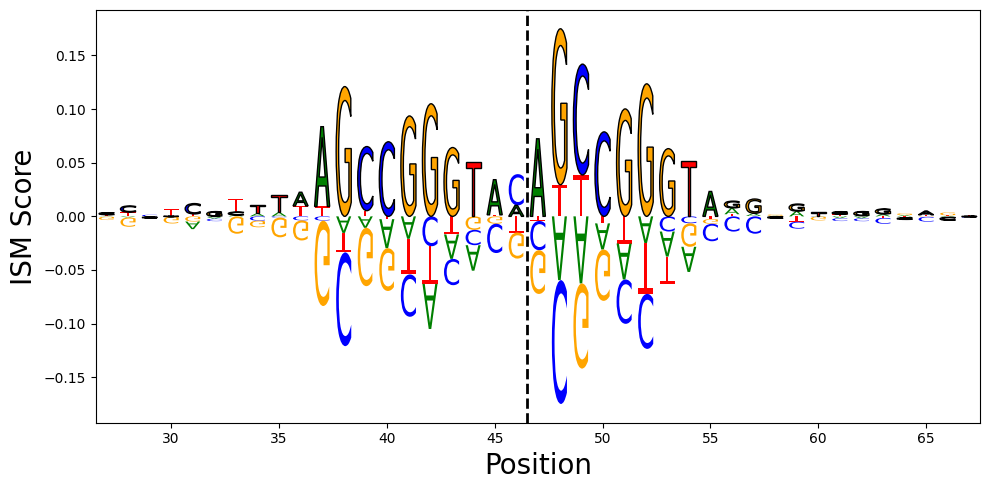

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-10_rank_1.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\2131479200.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


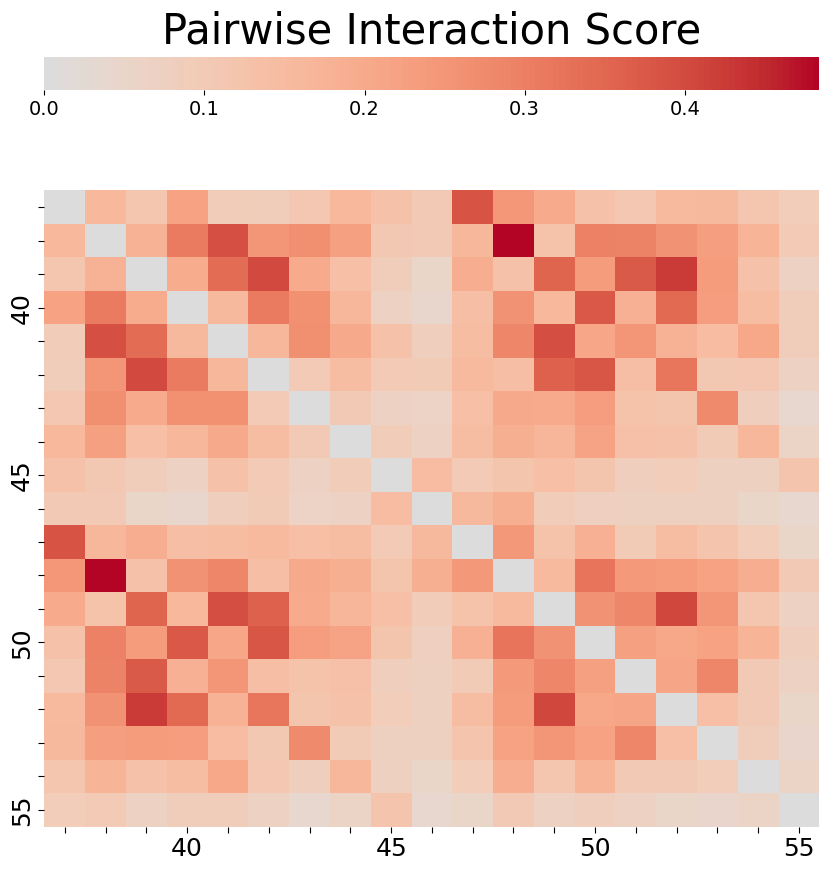

ISM and Influence Map Visualization Run: 2
Processing ISM file: ISM/ism_FORECasT K562_delta_-10_2.csv


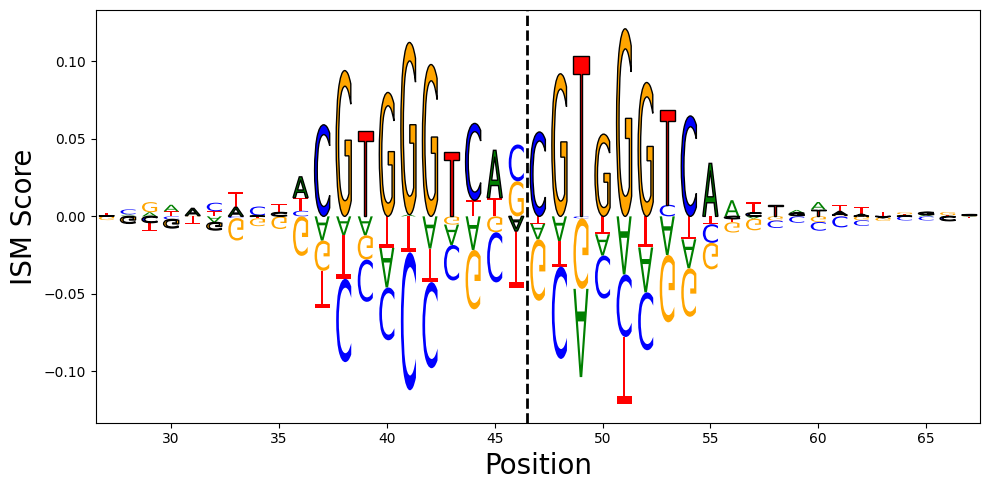

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-10_rank_2.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\2131479200.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


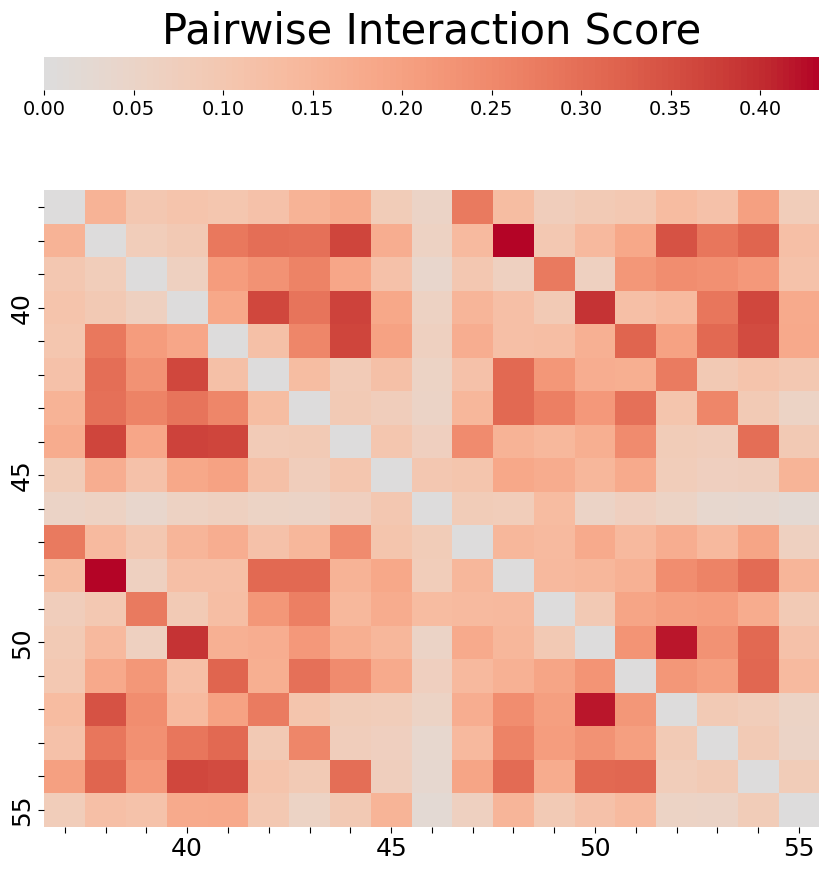

ISM and Influence Map Visualization Run: 3
Processing ISM file: ISM/ism_FORECasT K562_delta_-10_3.csv


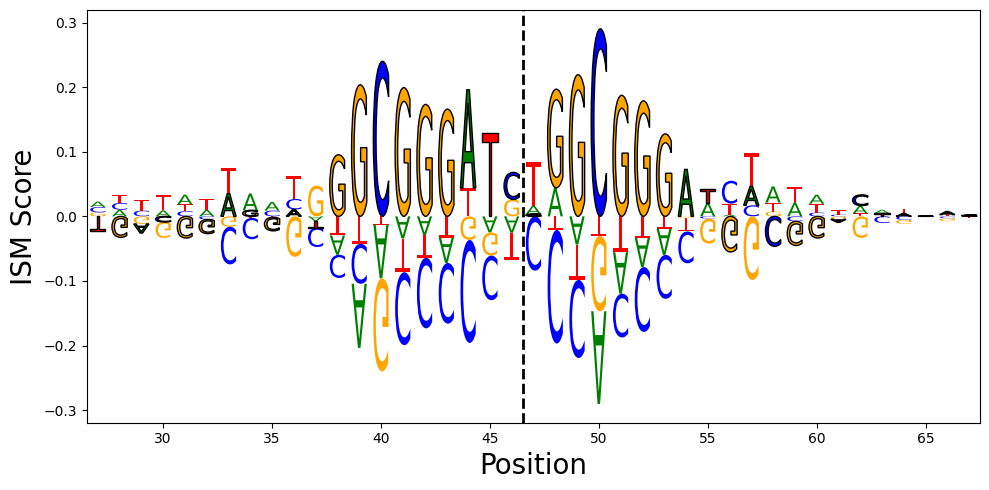

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-10_rank_3.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\2131479200.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


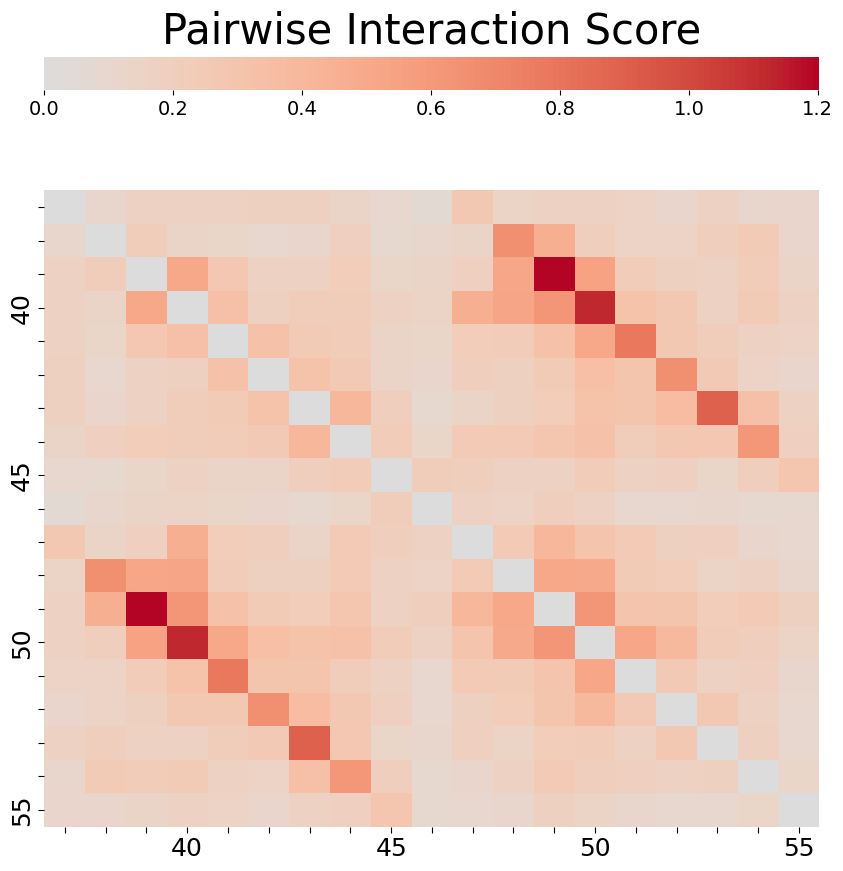

ISM and Influence Map Visualization Run: 1
Processing ISM file: ISM/ism_FORECasT K562_delta_-5_1.csv


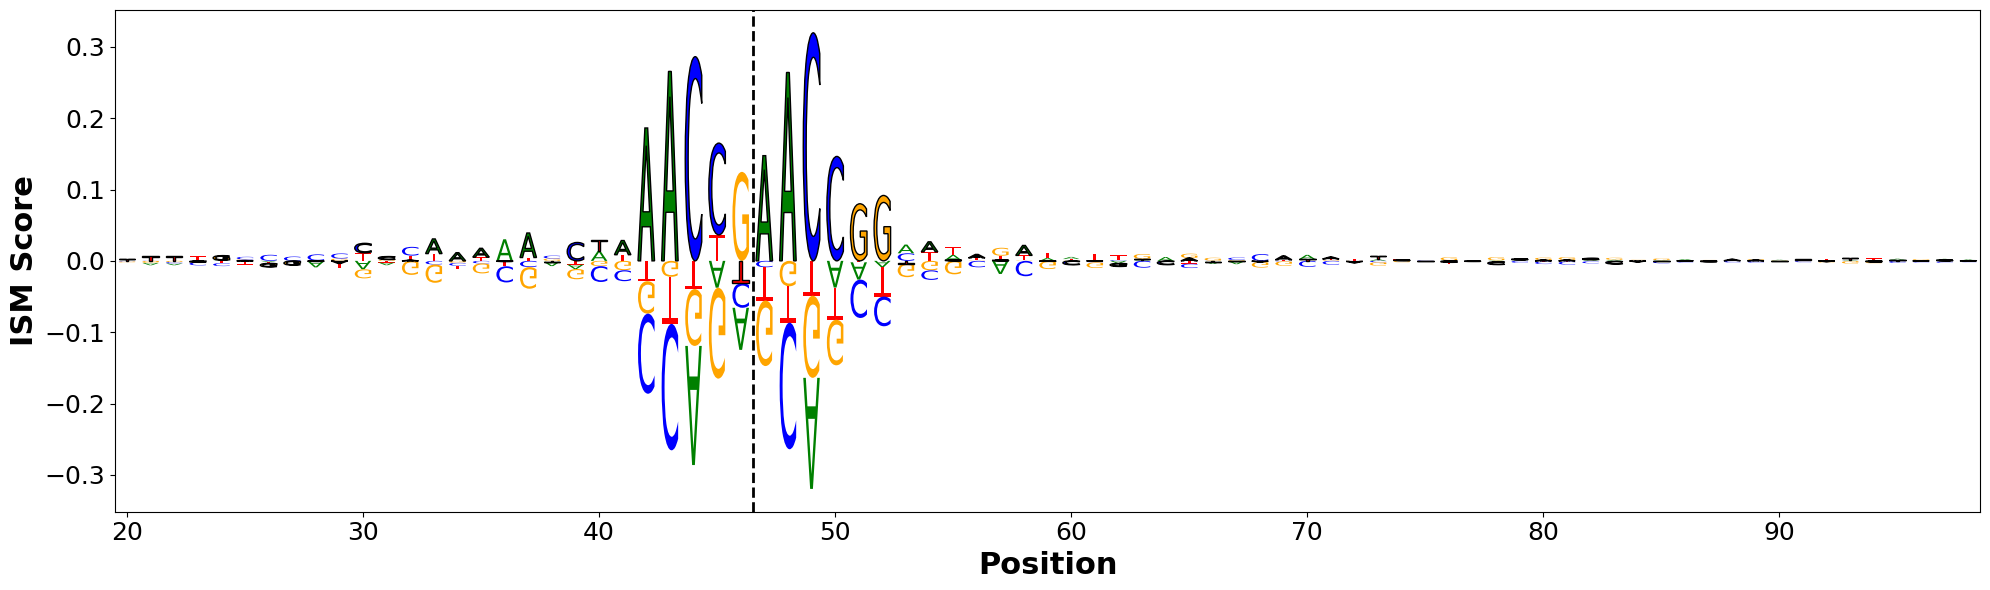

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-5_rank_1.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


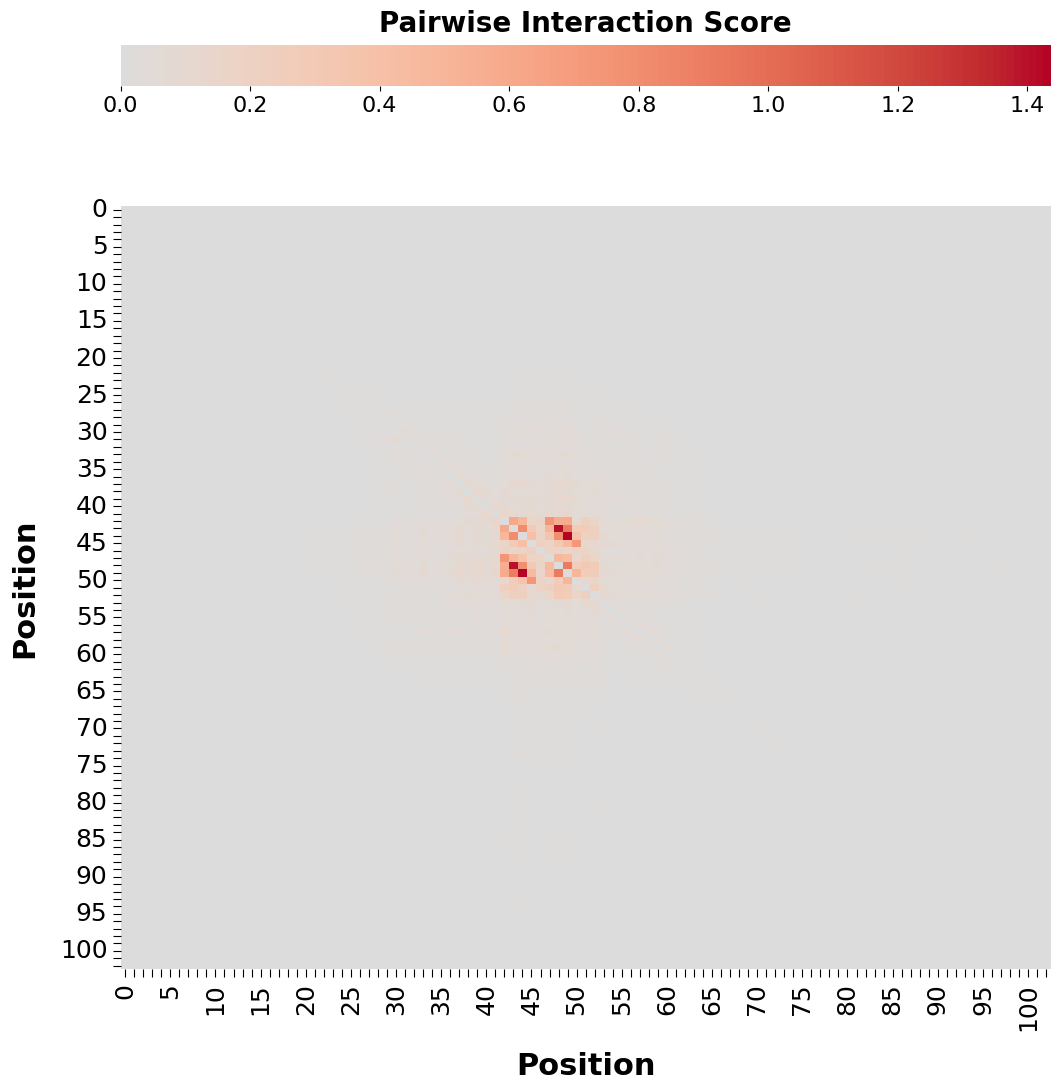

ISM and Influence Map Visualization Run: 2
Processing ISM file: ISM/ism_FORECasT K562_delta_-5_2.csv


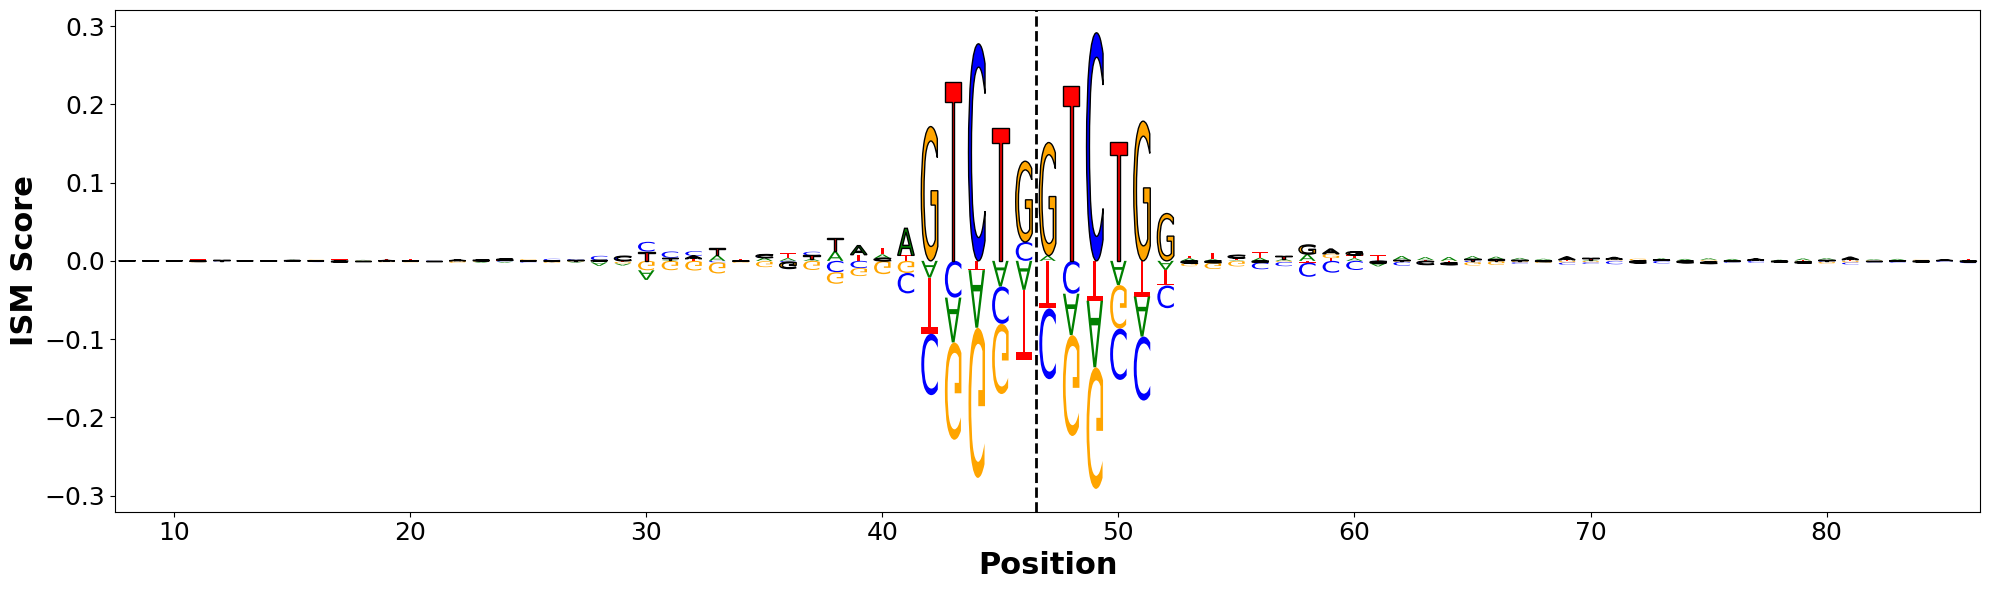

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-5_rank_2.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


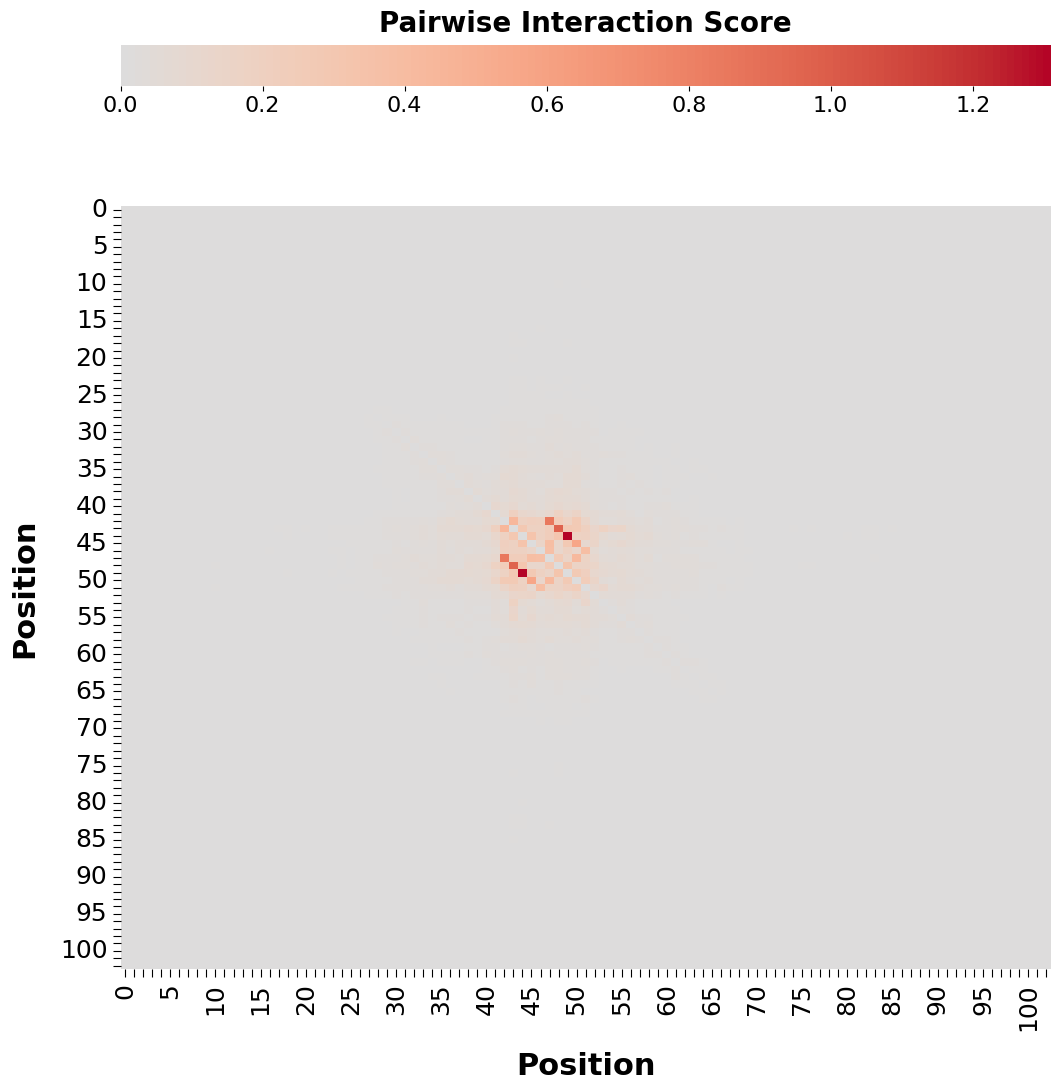

ISM and Influence Map Visualization Run: 3
Processing ISM file: ISM/ism_FORECasT K562_delta_-5_3.csv


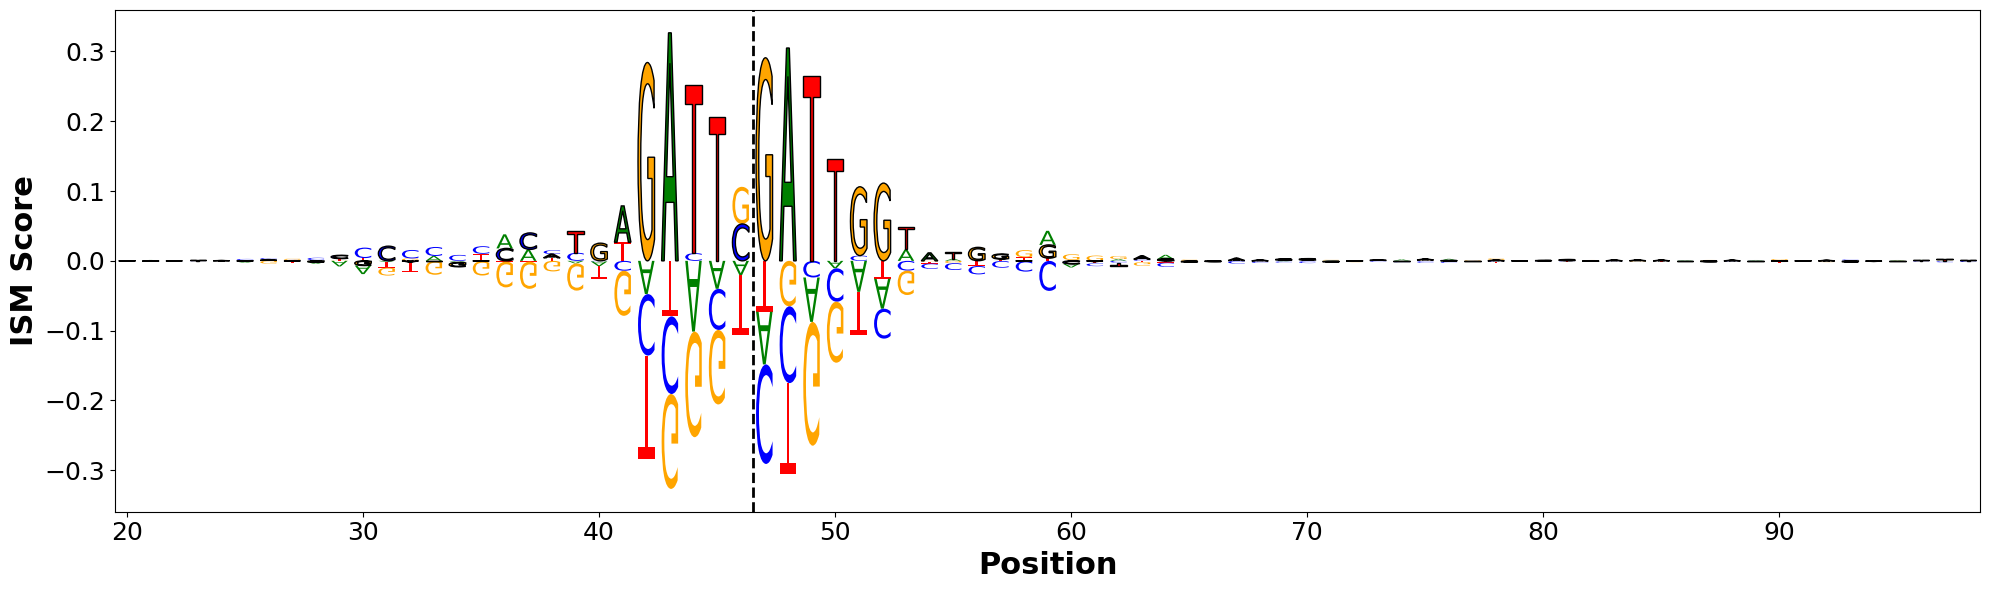

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-5_rank_3.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


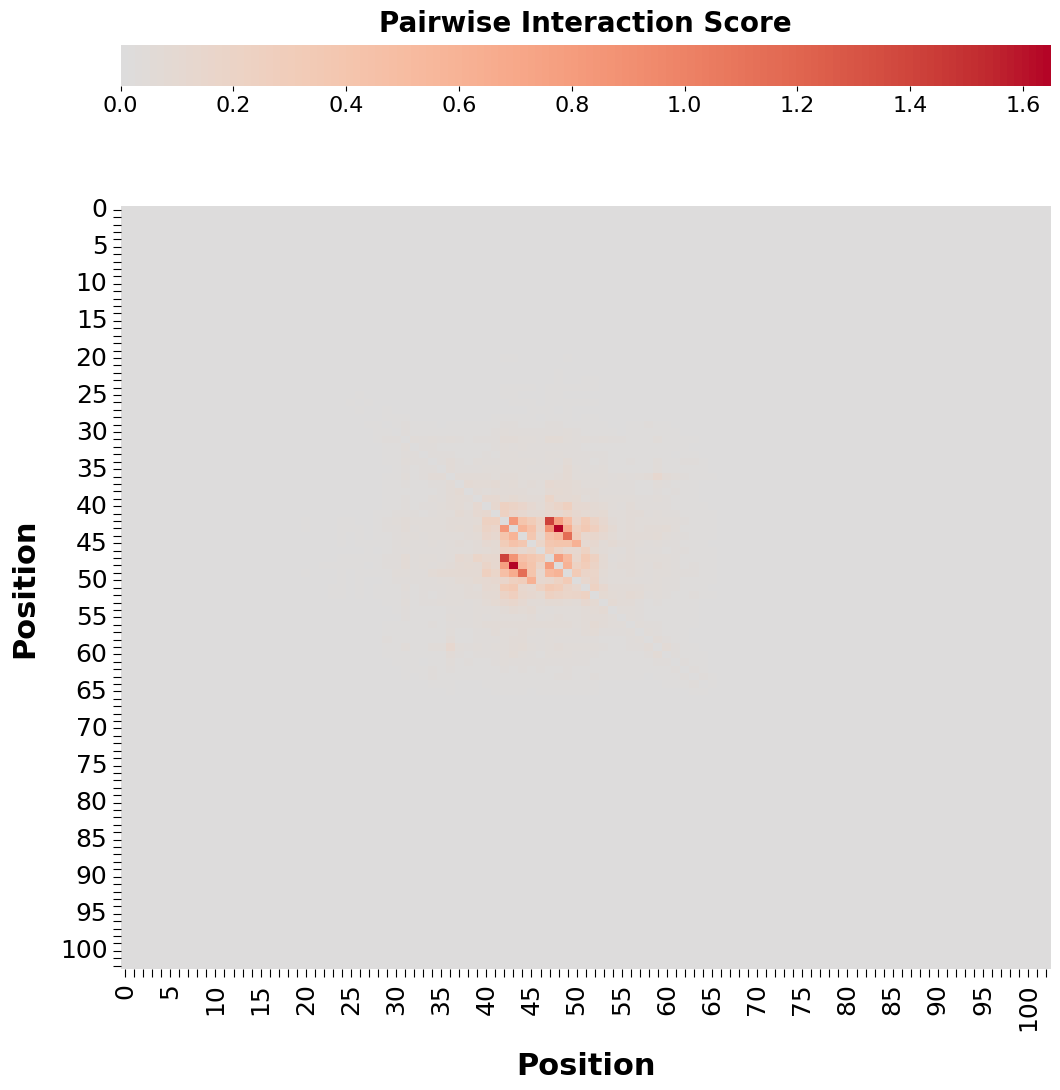

ISM and Influence Map Visualization Run: 1
Processing ISM file: ISM/ism_FORECasT K562_delta_-7_1.csv


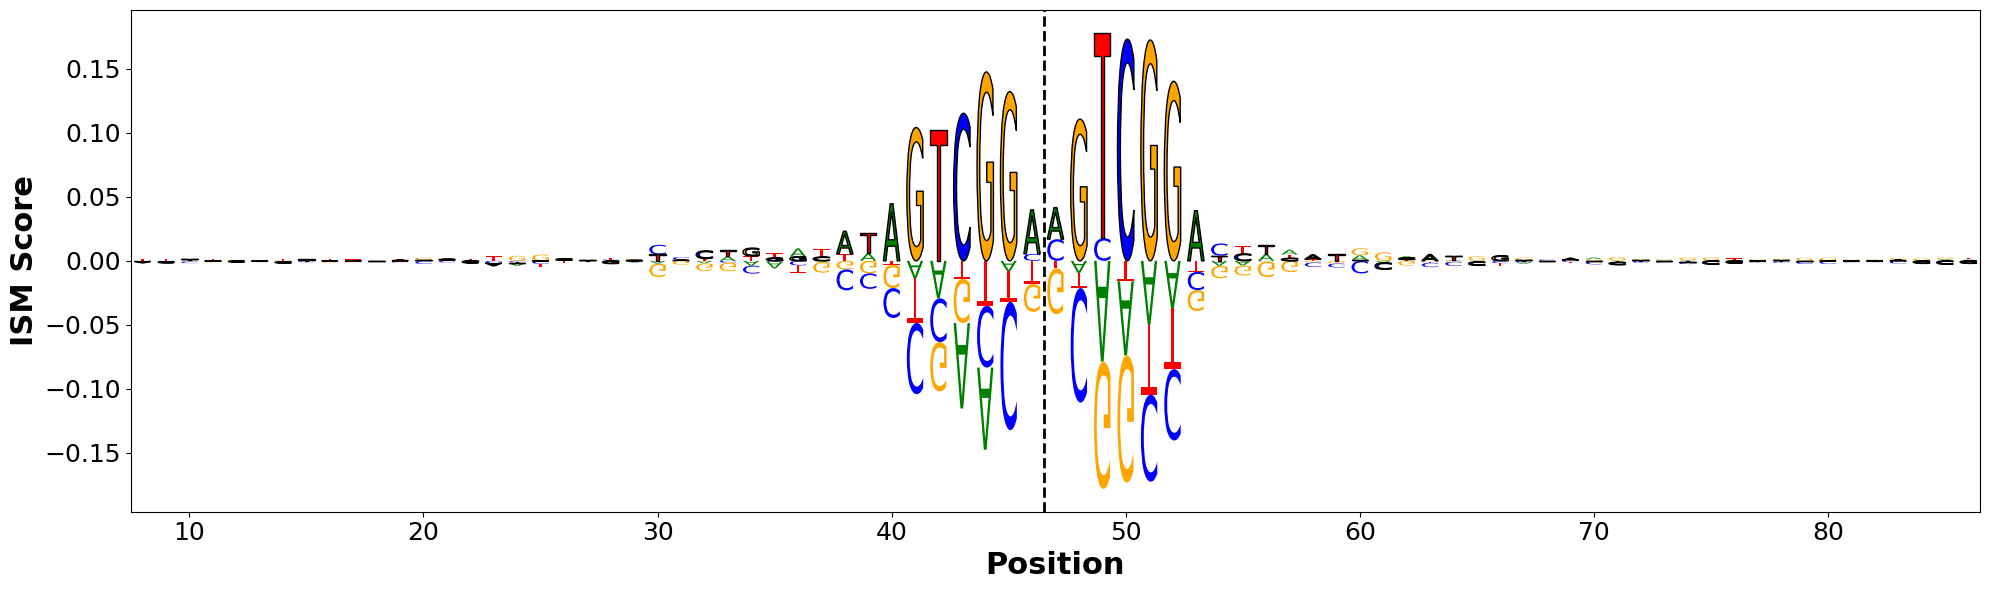

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-7_rank_1.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


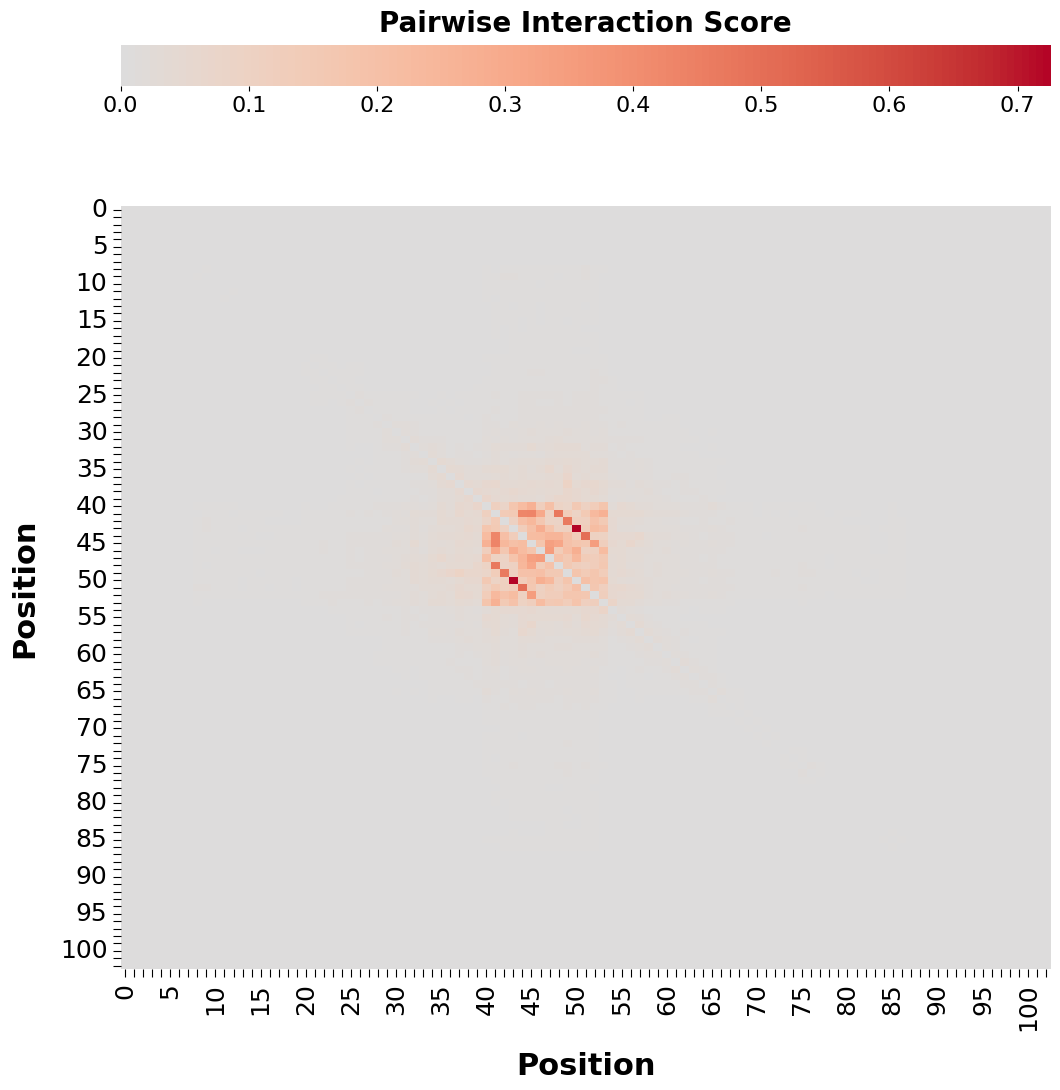

ISM and Influence Map Visualization Run: 2
Processing ISM file: ISM/ism_FORECasT K562_delta_-7_2.csv


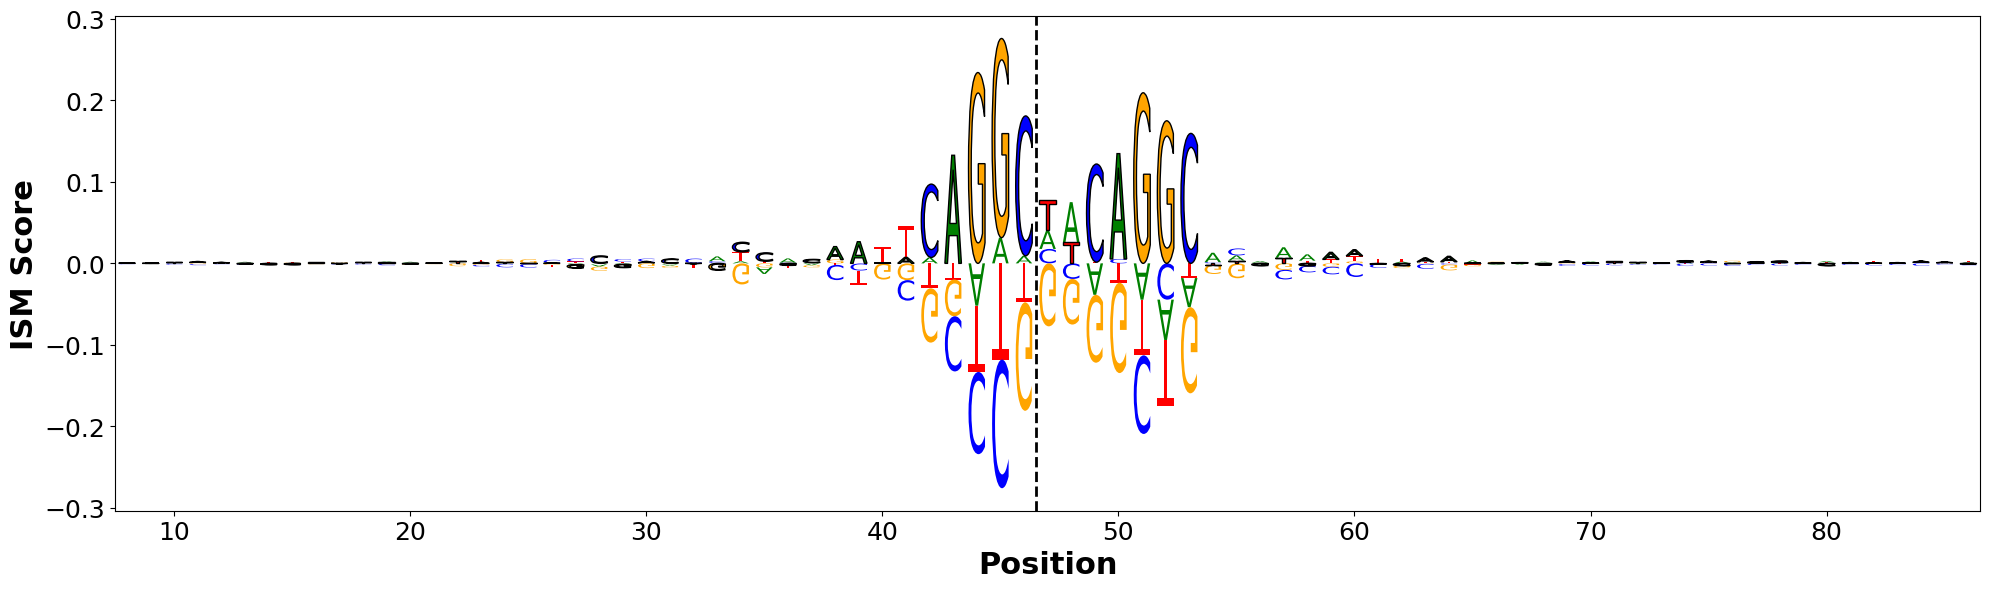

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-7_rank_2.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


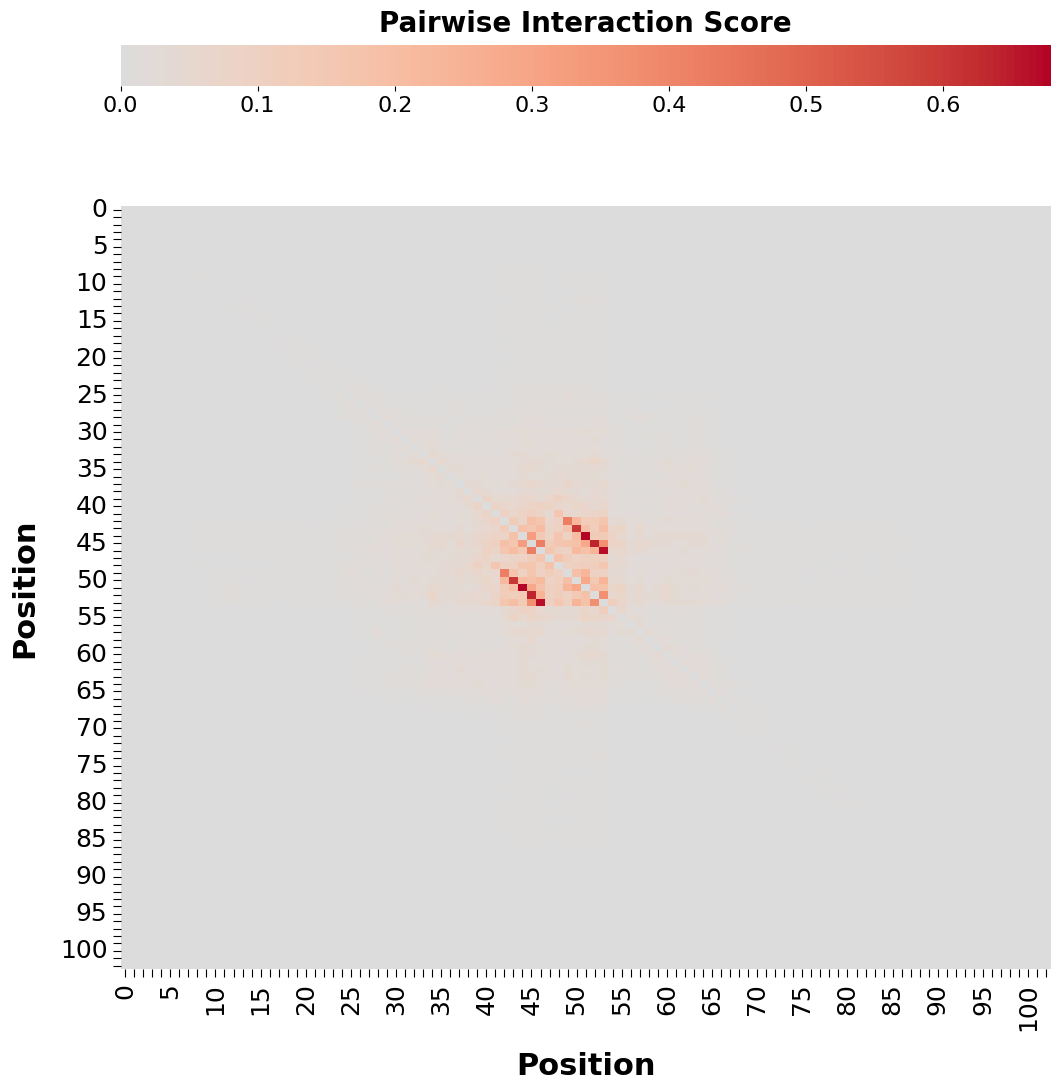

ISM and Influence Map Visualization Run: 3
Processing ISM file: ISM/ism_FORECasT K562_delta_-7_3.csv


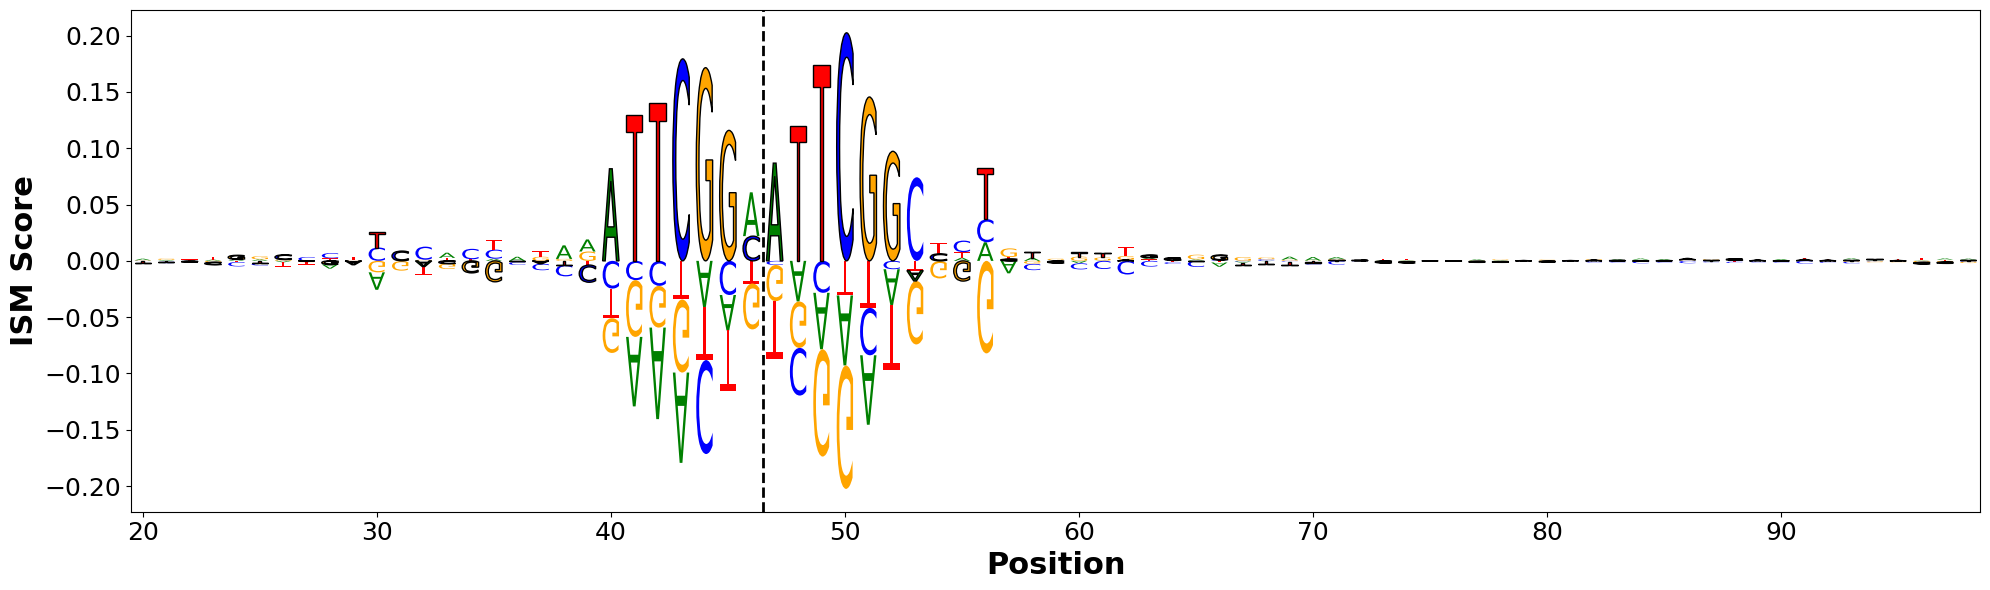

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-7_rank_3.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


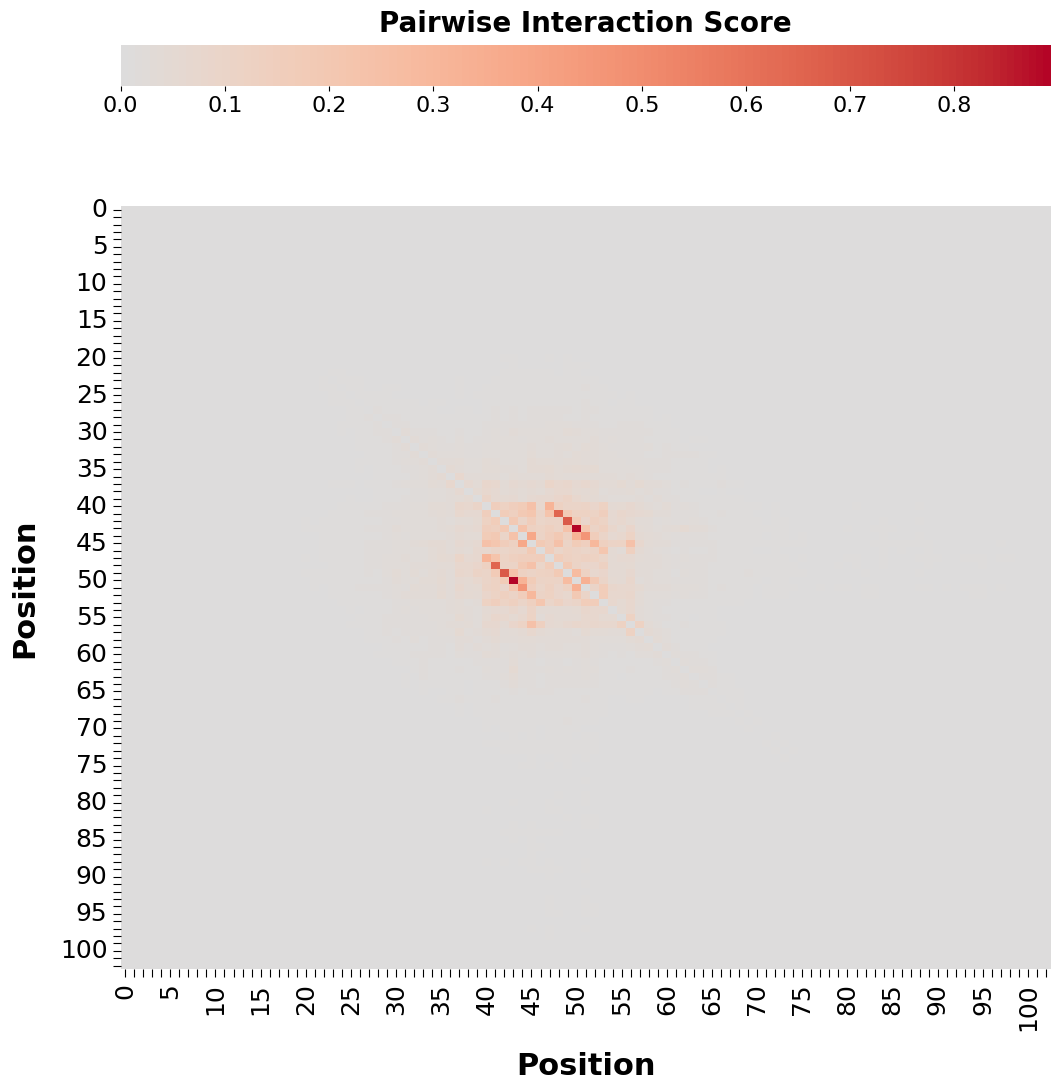

ISM and Influence Map Visualization Run: 1
Processing ISM file: ISM/ism_FORECasT K562_delta_-10_1.csv


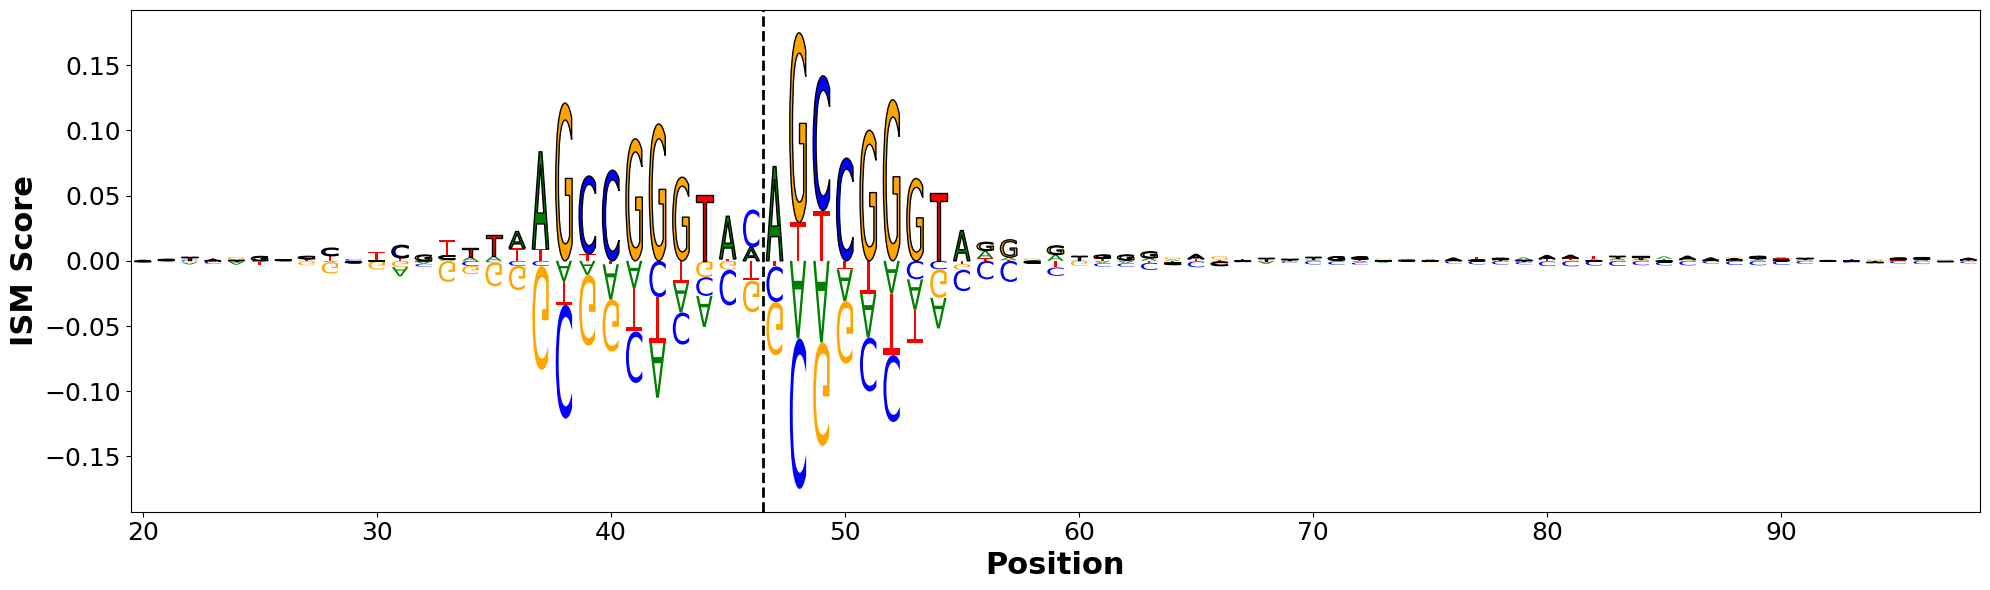

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-10_rank_1.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


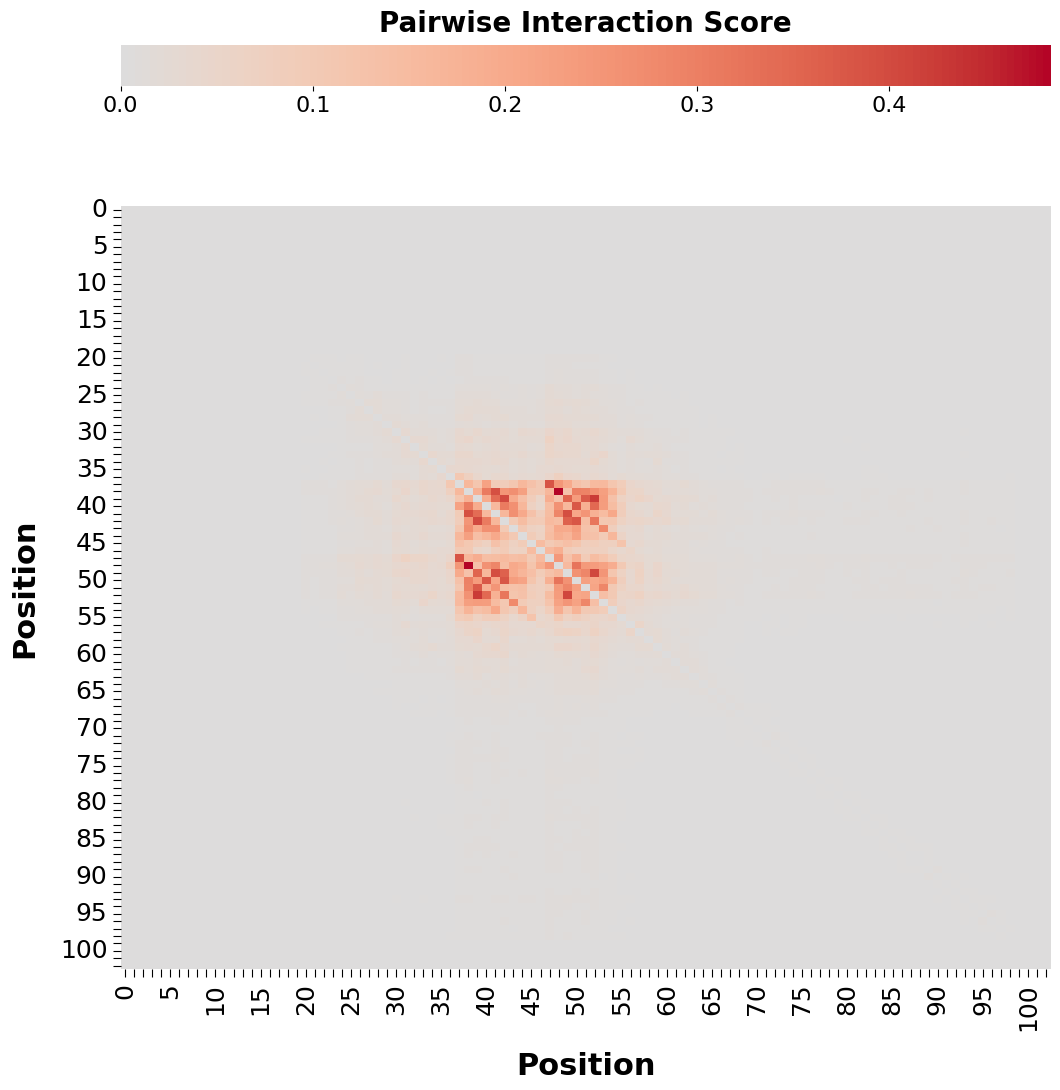

ISM and Influence Map Visualization Run: 2
Processing ISM file: ISM/ism_FORECasT K562_delta_-10_2.csv


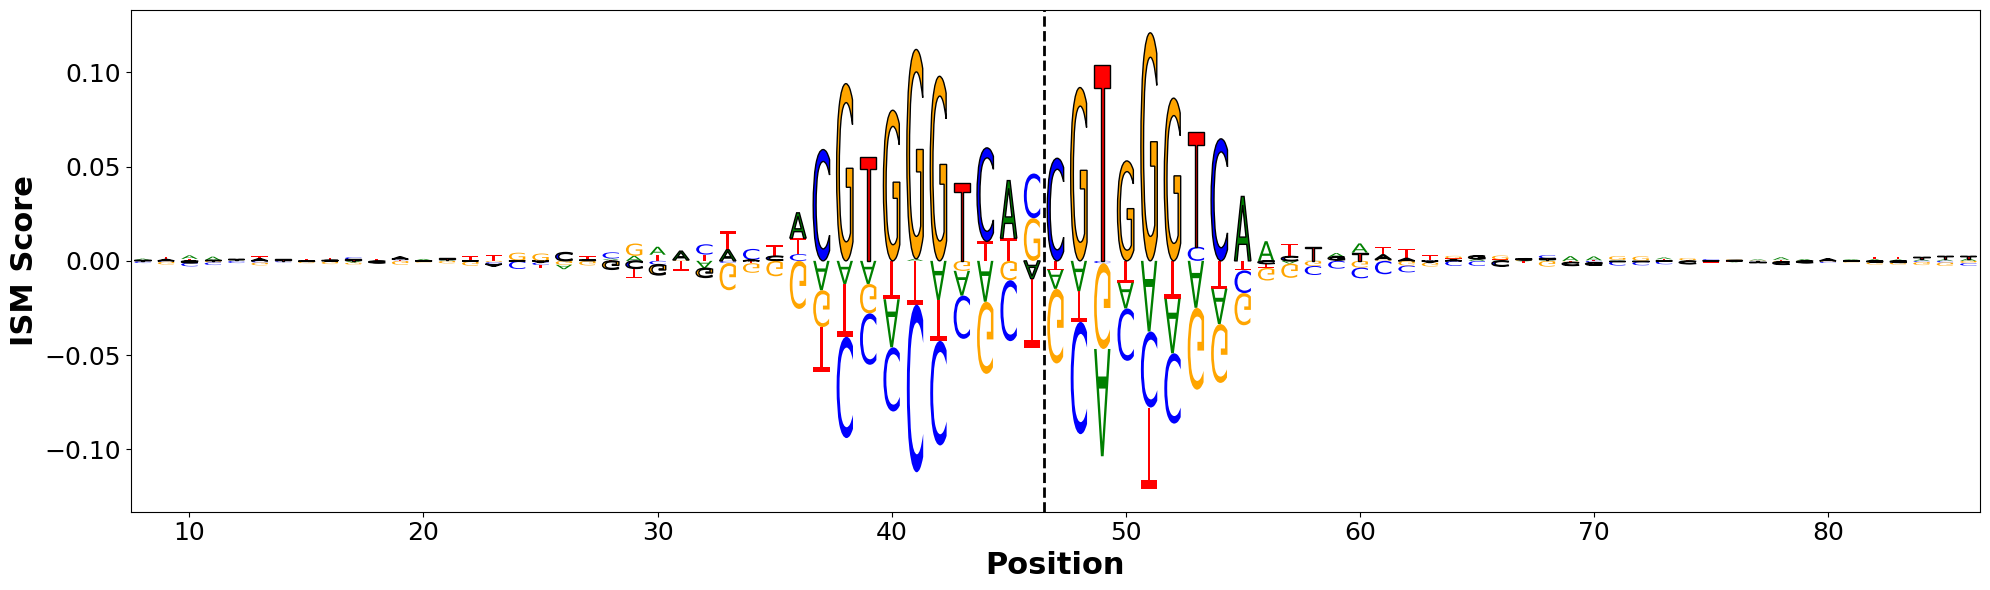

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-10_rank_2.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


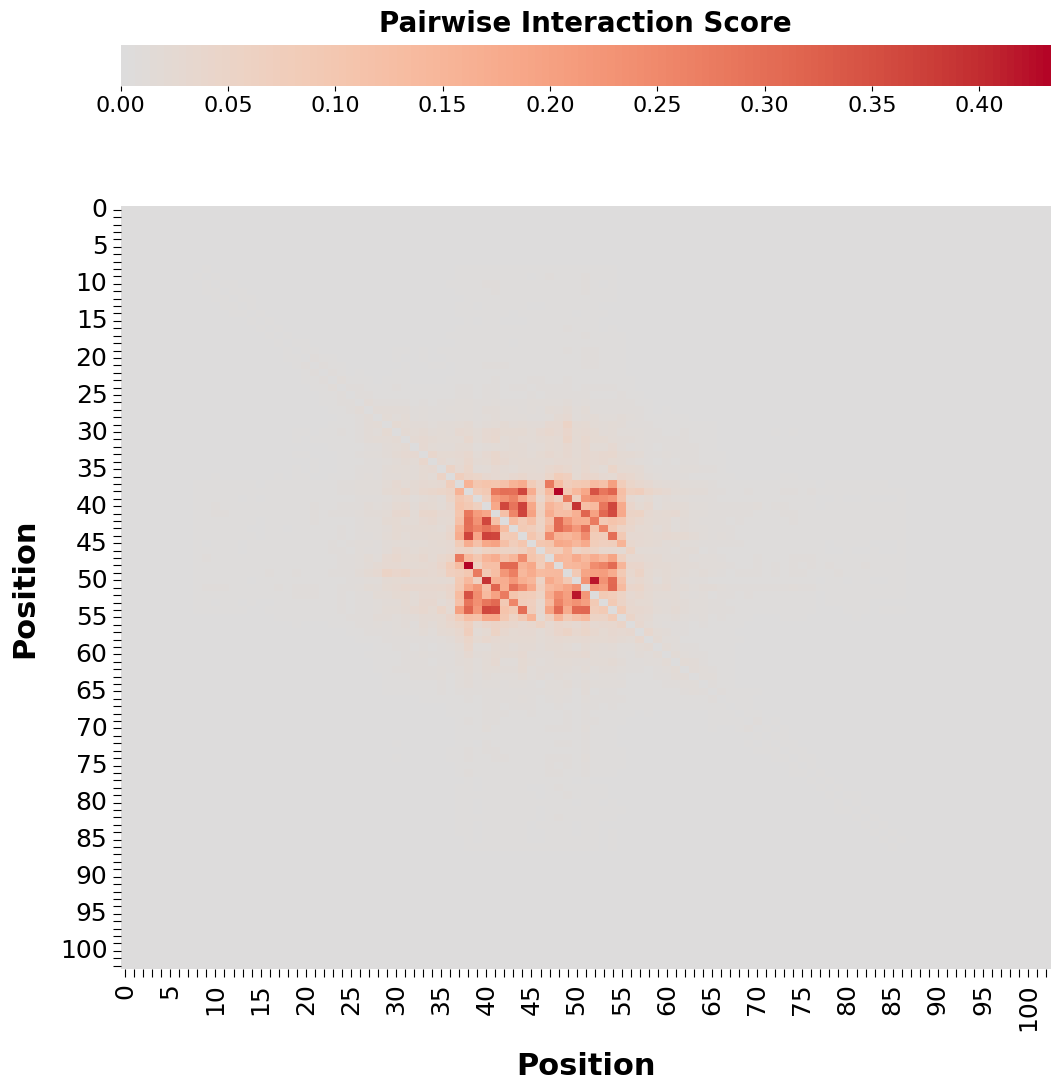

ISM and Influence Map Visualization Run: 3
Processing ISM file: ISM/ism_FORECasT K562_delta_-10_3.csv


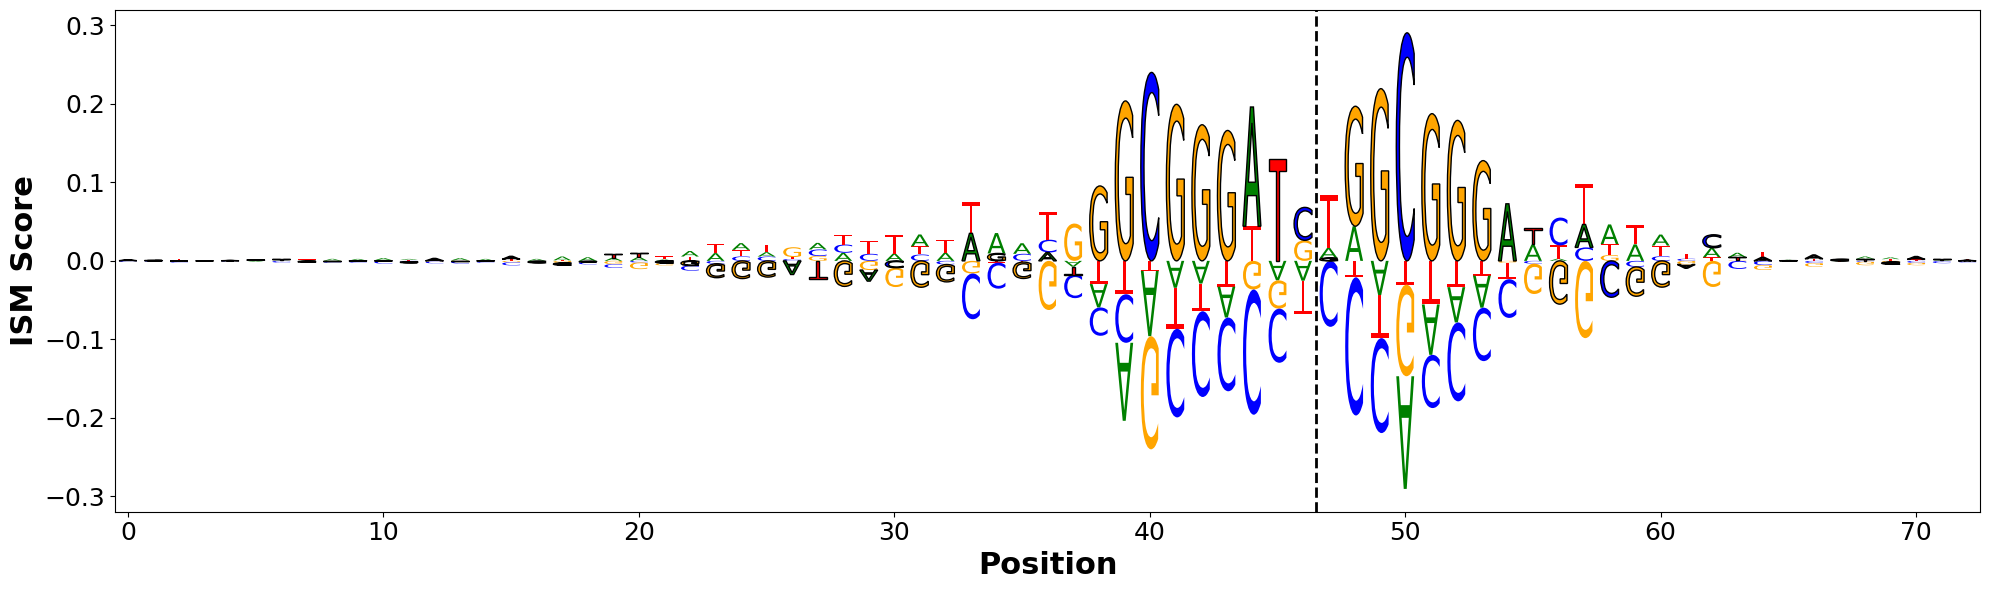

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-10_rank_3.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


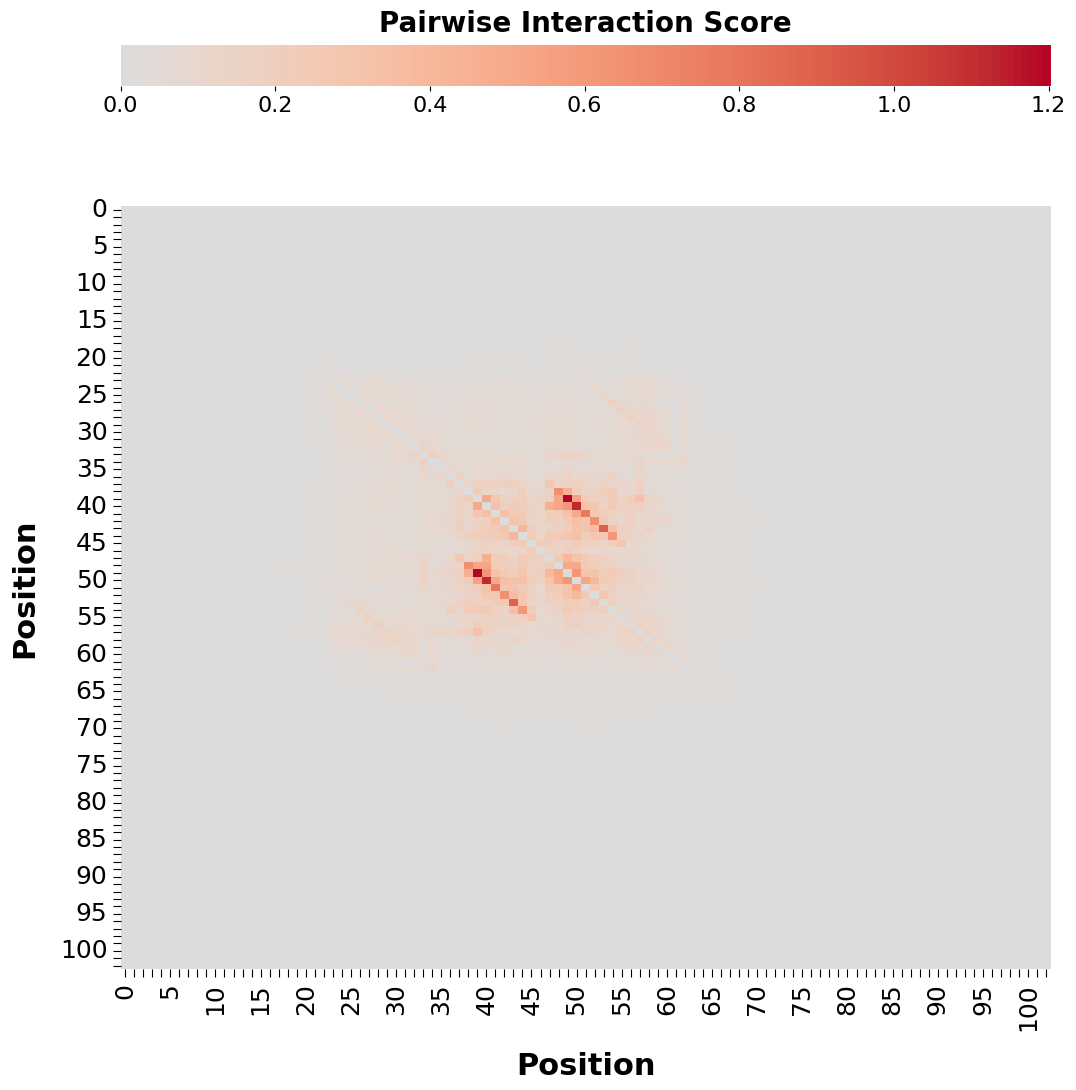

ISM and Influence Map Visualization Run: 1
Processing ISM file: ISM/ism_FORECasT K562_delta_-15_1.csv


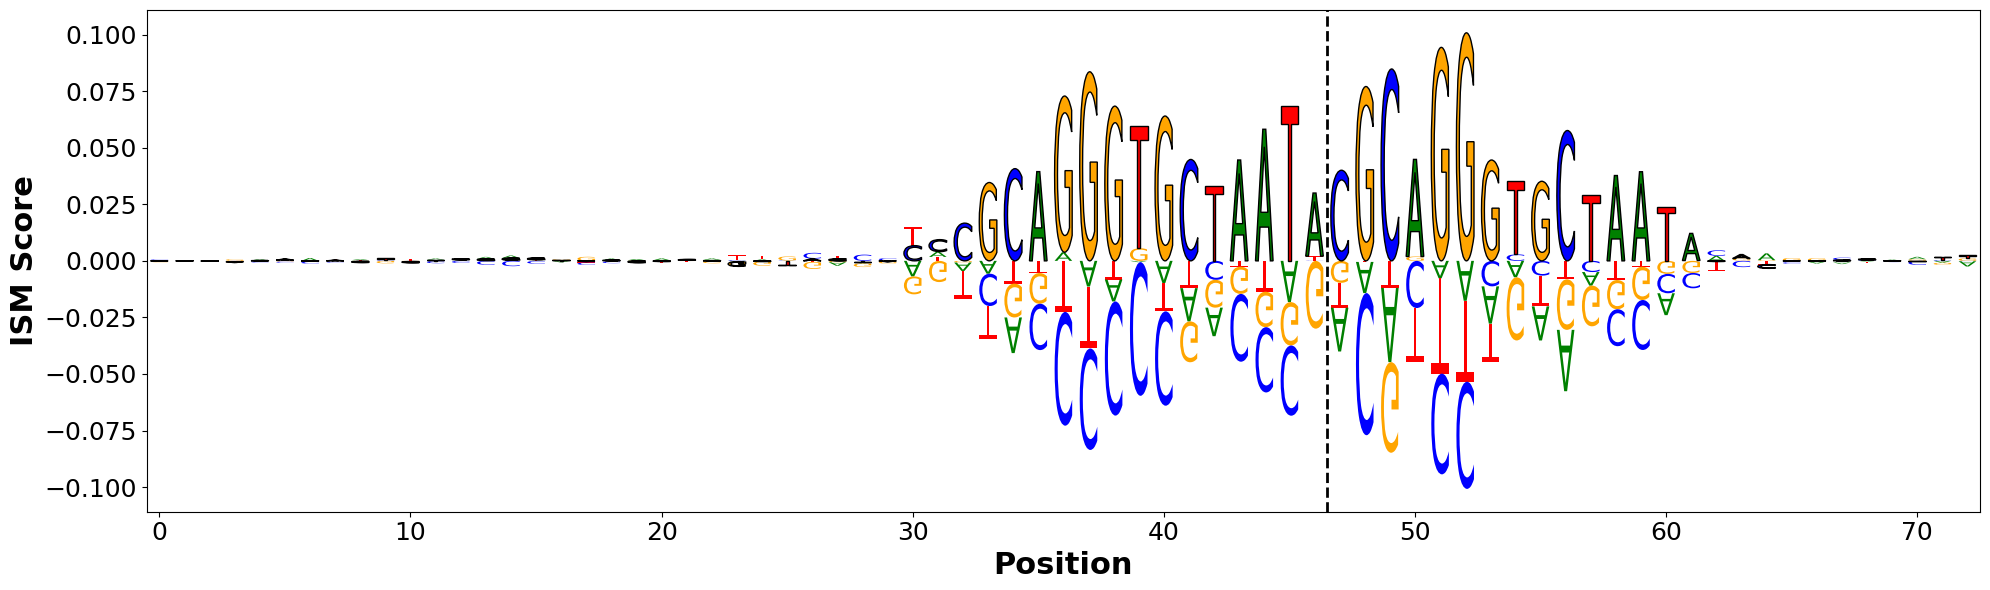

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-15_rank_1.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


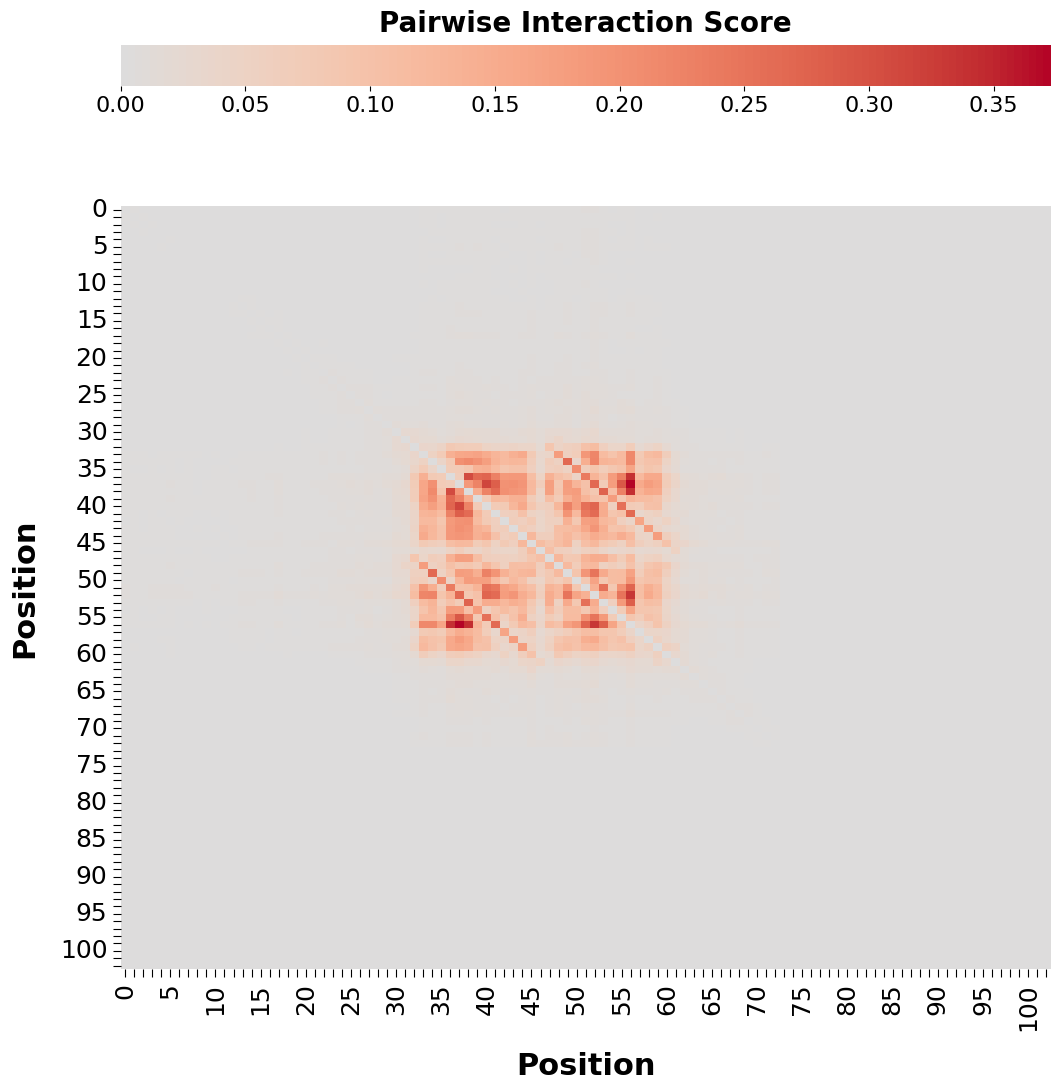

ISM and Influence Map Visualization Run: 2
Processing ISM file: ISM/ism_FORECasT K562_delta_-15_2.csv


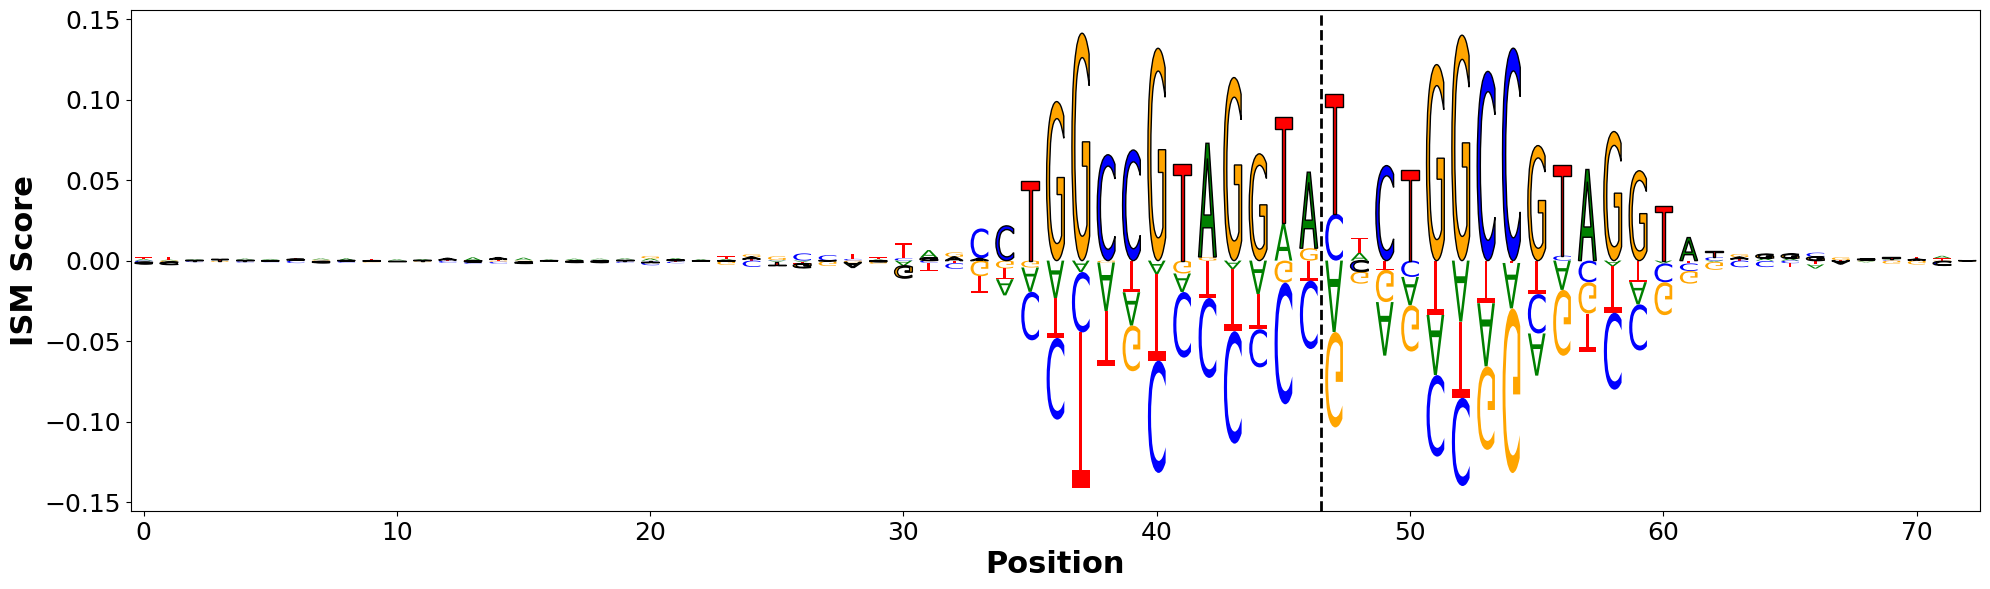

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-15_rank_2.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


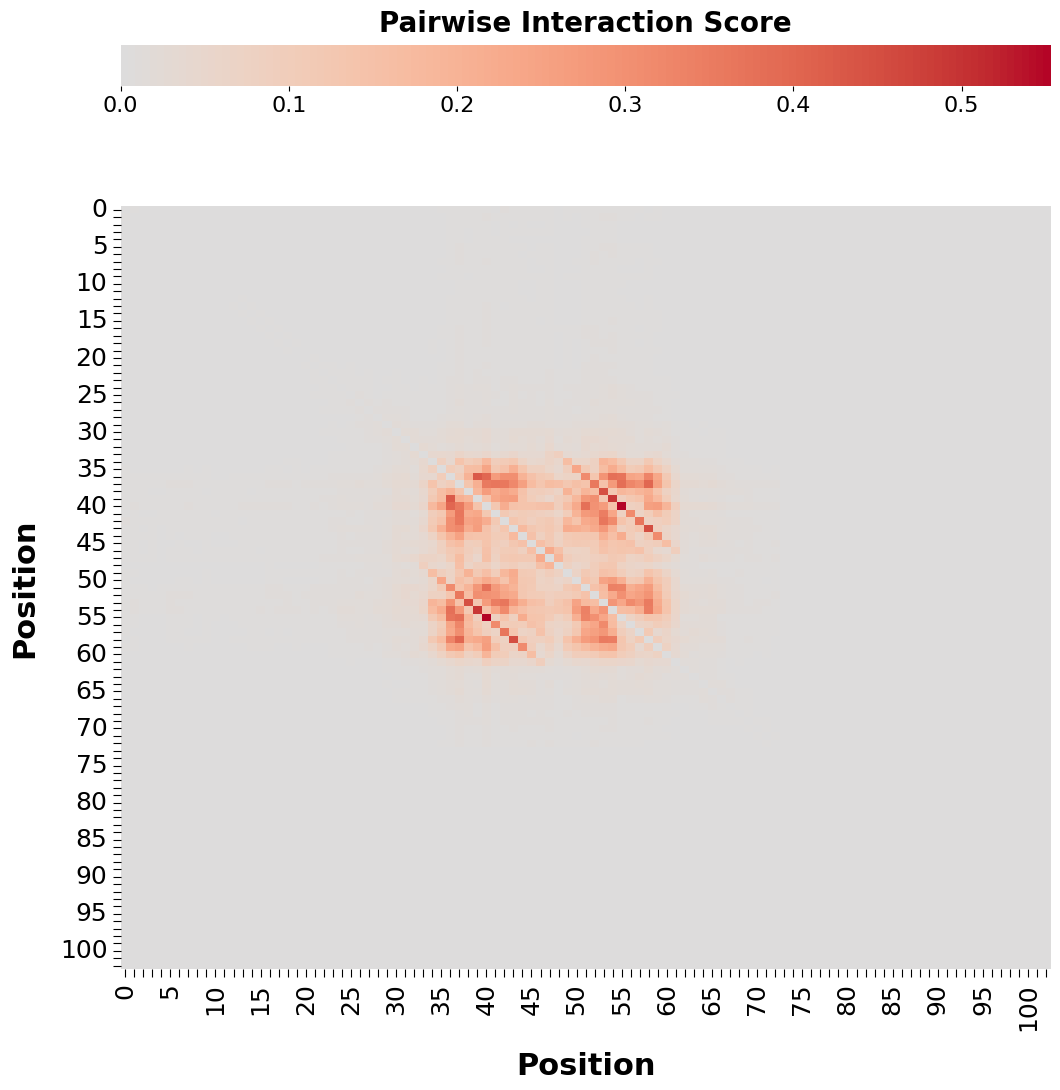

ISM and Influence Map Visualization Run: 3
Processing ISM file: ISM/ism_FORECasT K562_delta_-15_3.csv


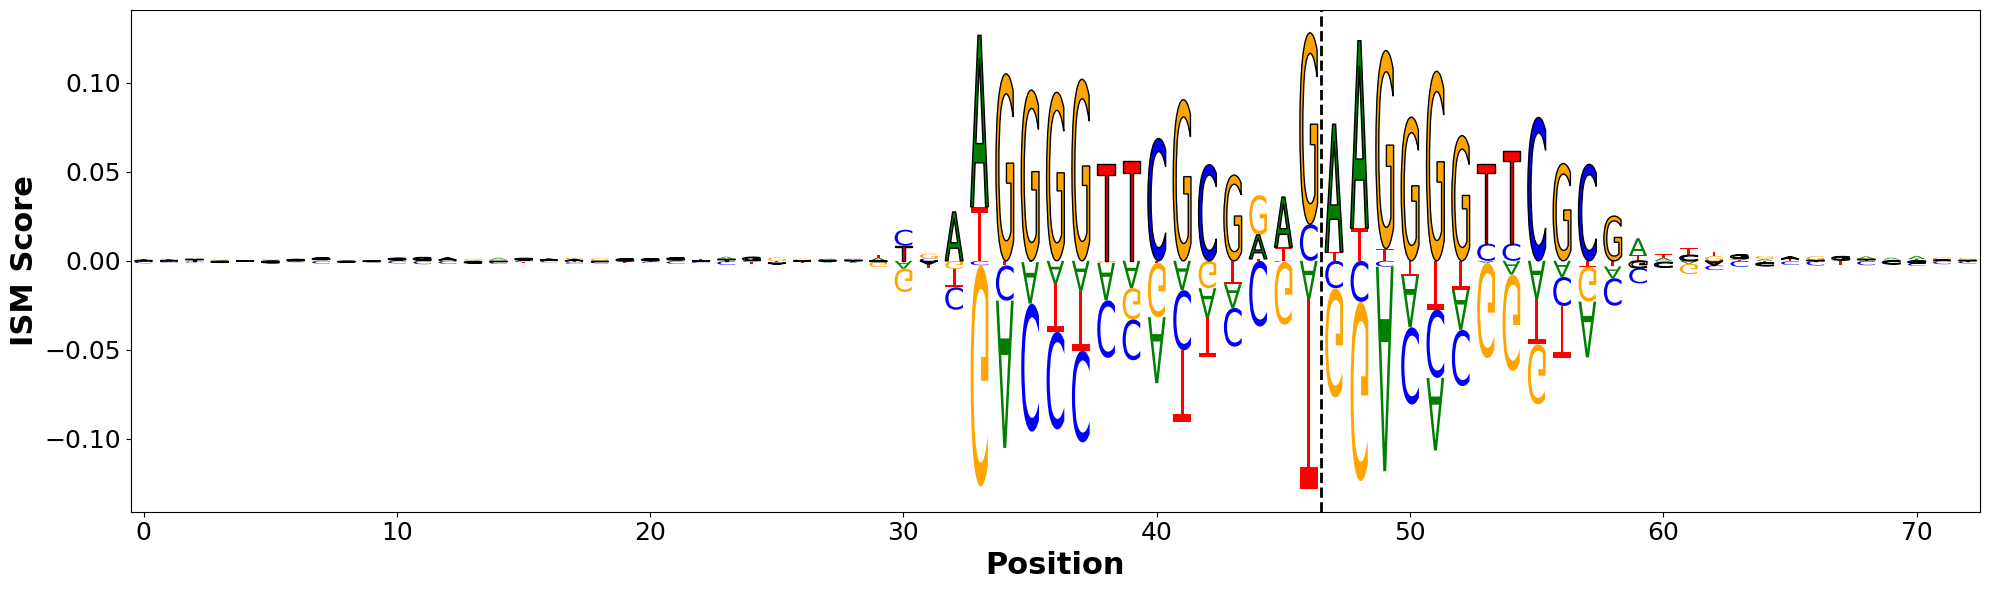

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-15_rank_3.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


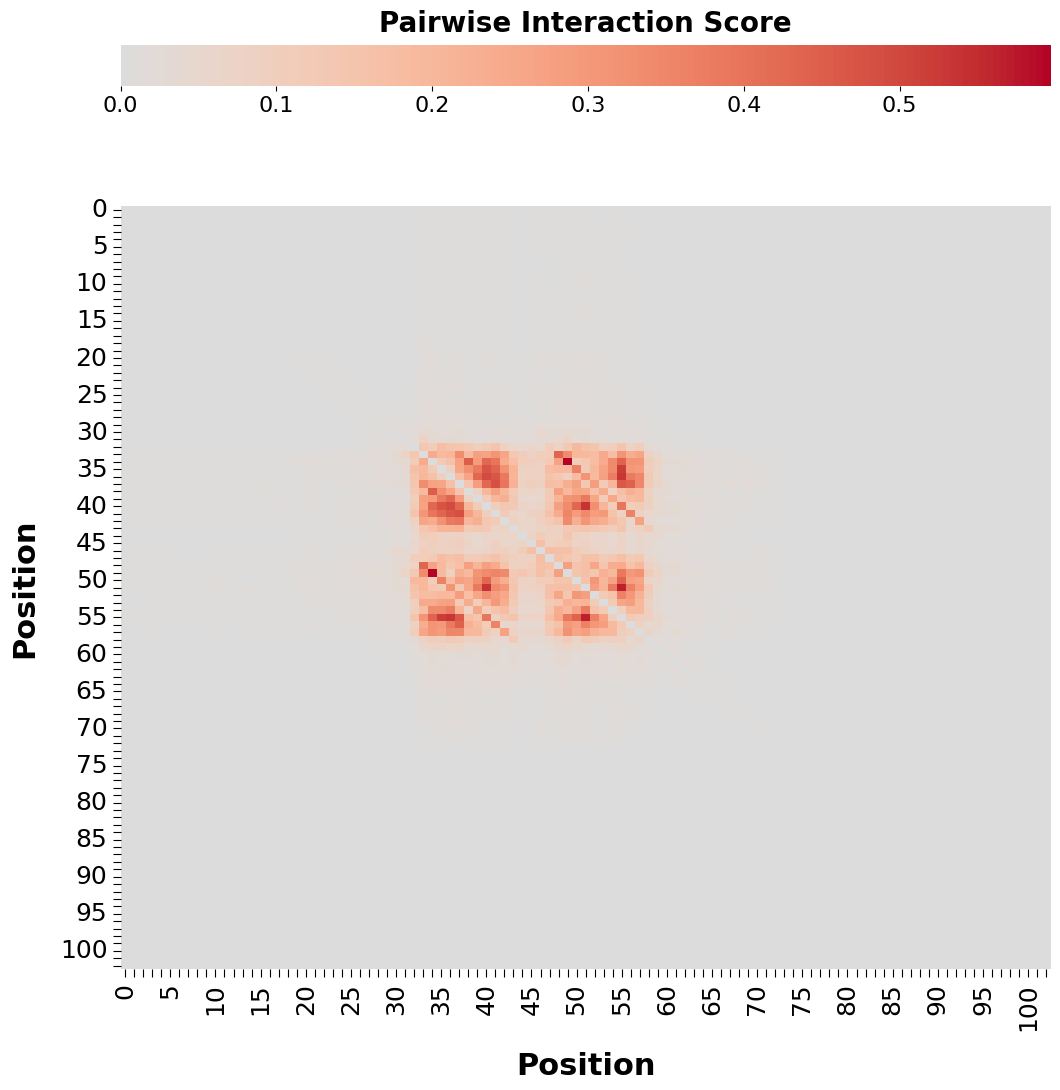

ISM and Influence Map Visualization Run: 1
Processing ISM file: ISM/ism_FORECasT K562_delta_-20_1.csv


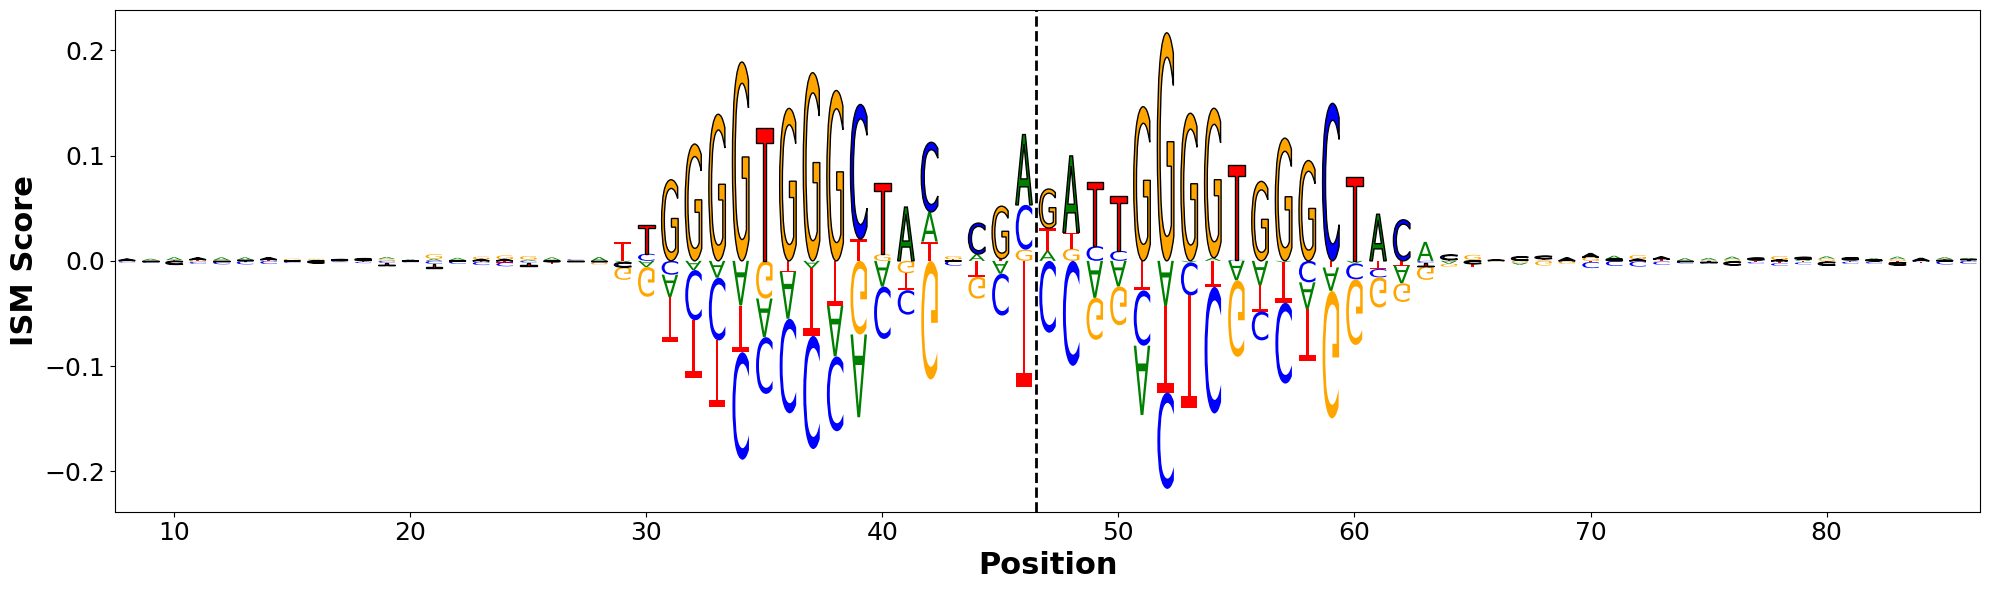

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-20_rank_1.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


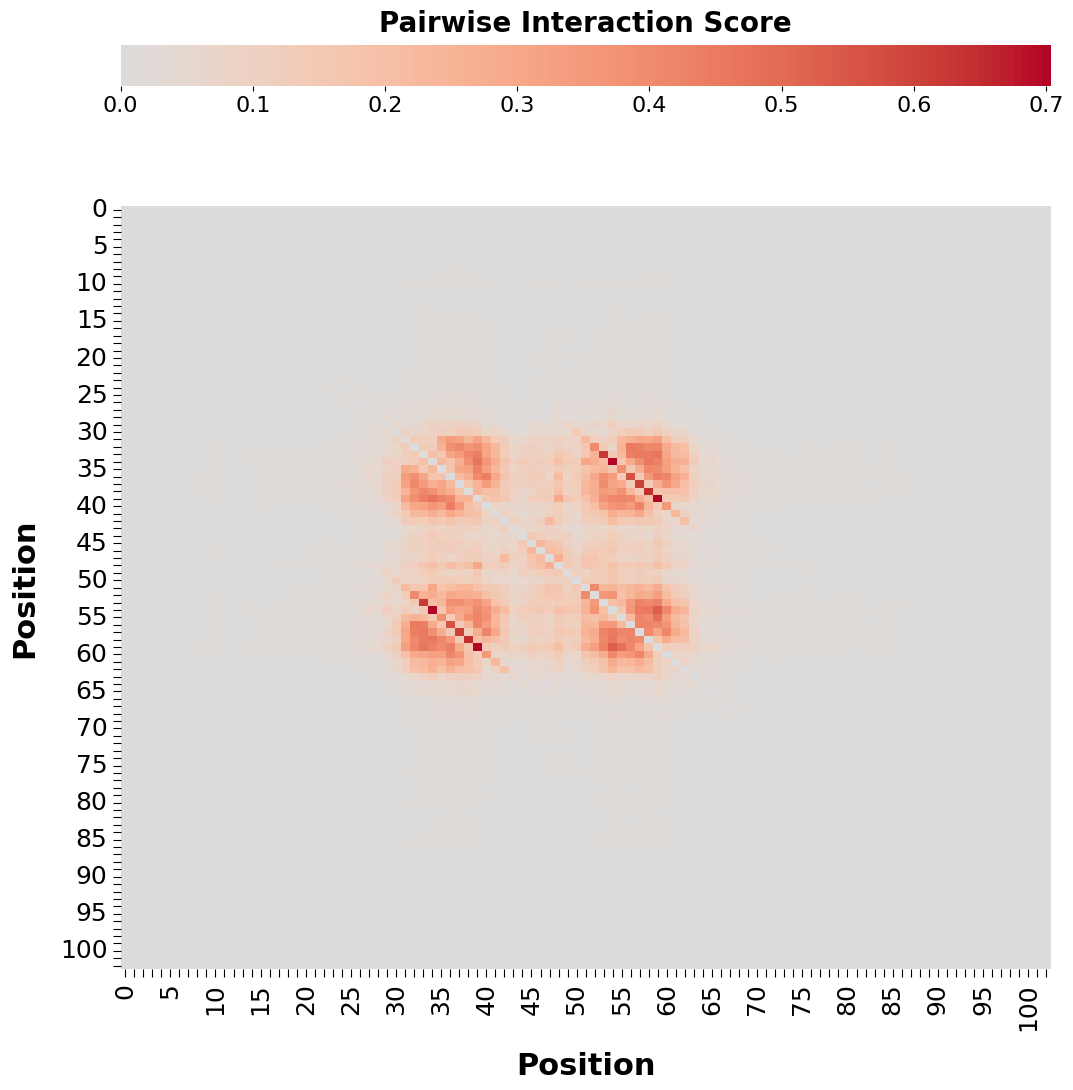

ISM and Influence Map Visualization Run: 2
Processing ISM file: ISM/ism_FORECasT K562_delta_-20_2.csv


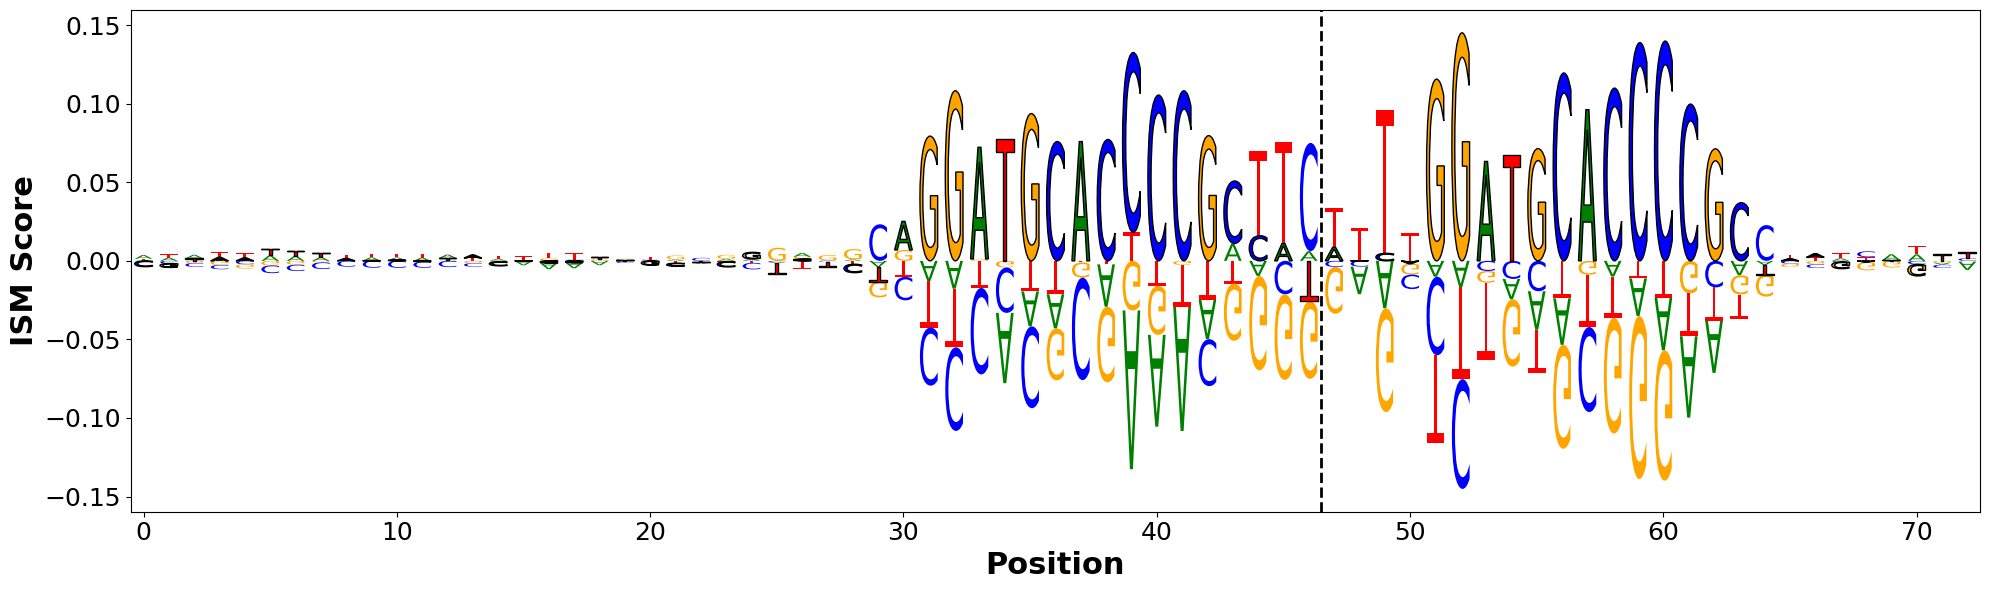

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-20_rank_2.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


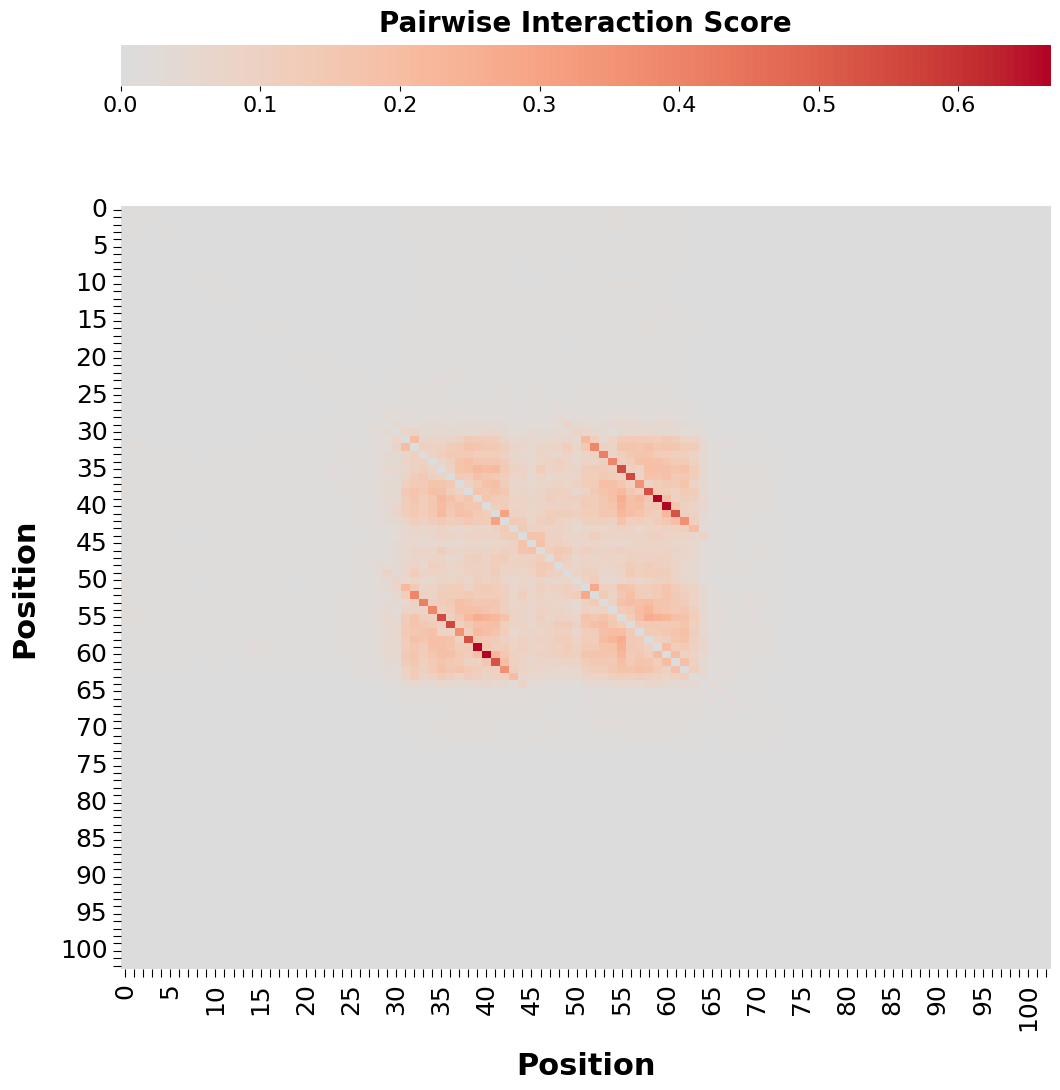

ISM and Influence Map Visualization Run: 3
Processing ISM file: ISM/ism_FORECasT K562_delta_-20_3.csv


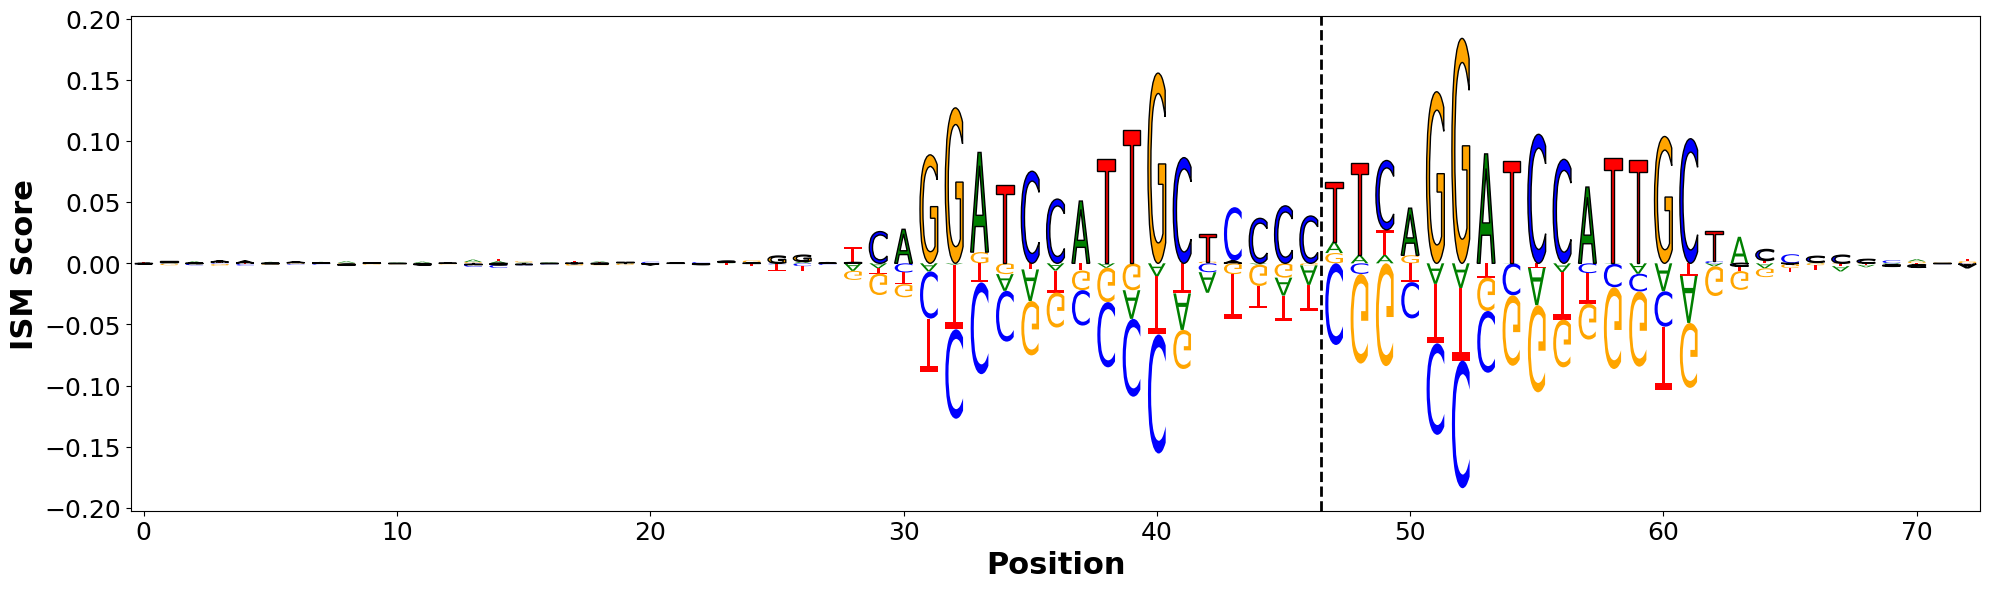

Processing Influence file: ISM/influence_map_FORECasT K562_delta_-20_rank_3.csv


C:\Users\tzion\AppData\Local\Temp\ipykernel_13268\3245588687.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


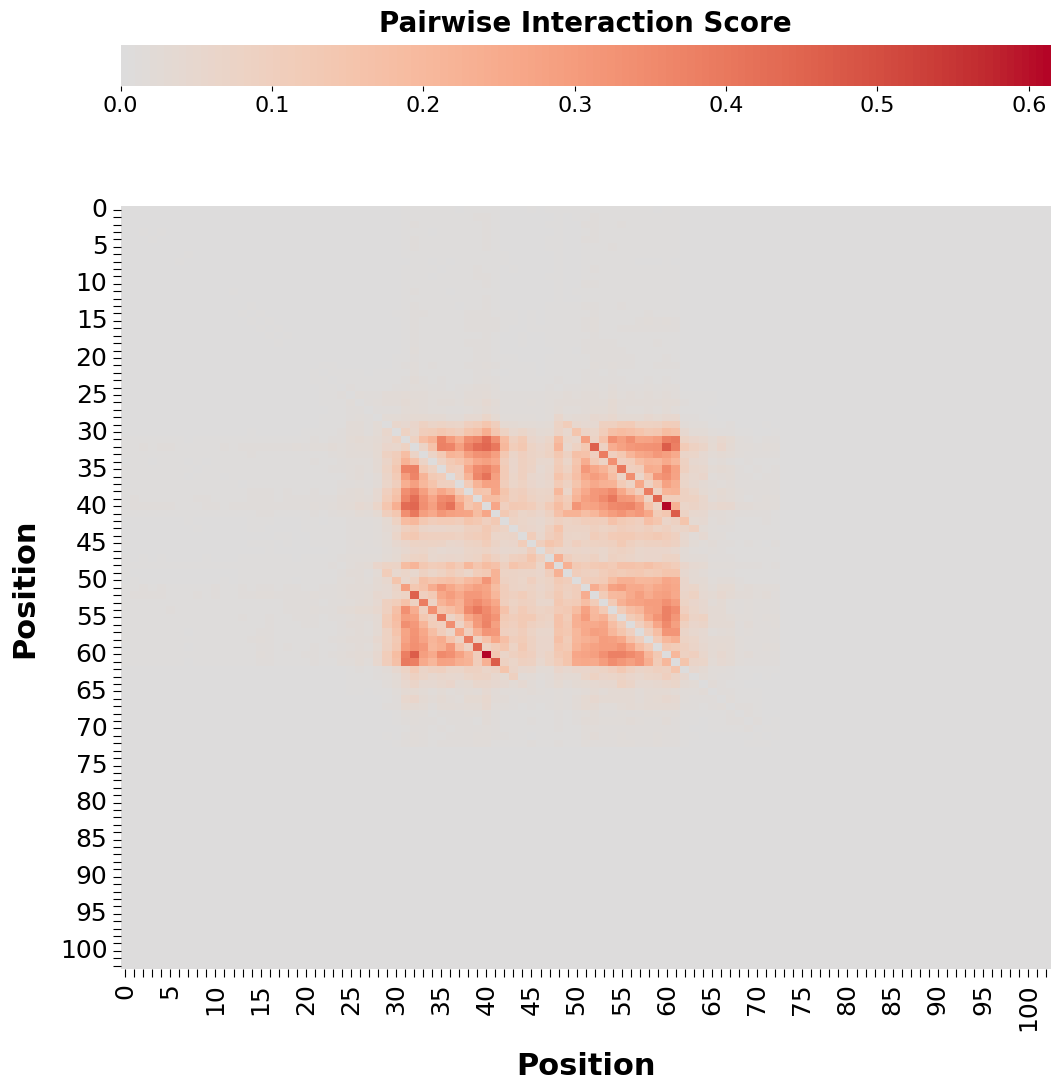

In [3]:
for i in range(1, 4):
    print("ISM and Influence Map Visualization Run:", i)
    # Replace these filenames with your actual local paths
    ism_file = f"ISM/ism_FORECasT K562_delta_-10_{i}.csv"
    inf_file = f"ISM/influence_map_FORECasT K562_delta_-10_rank_{i}.csv"

    visualize_crispr_data(ism_file, inf_file, ism_crop_min=27, ism_crop_max=68, inf_crop_min=37, inf_crop_max=56, delta=-10, i=i)

for delta in [-5, -7, -10, -15, -20]:
    for i in range(1, 4):
        print("ISM and Influence Map Visualization Run:", i)
        # Replace these filenames with your actual local paths
        ism_file = f"ISM/ism_FORECasT K562_delta_{delta}_{i}.csv"
        inf_file = f"ISM/influence_map_FORECasT K562_delta_{delta}_rank_{i}.csv"

        visualize_crispr_data_wide(ism_file, inf_file, ism_crop_min=None, ism_crop_max=None, inf_crop_min=None, inf_crop_max=None, delta=delta, i=i)



## New

Processing: Delta -10, Run 1


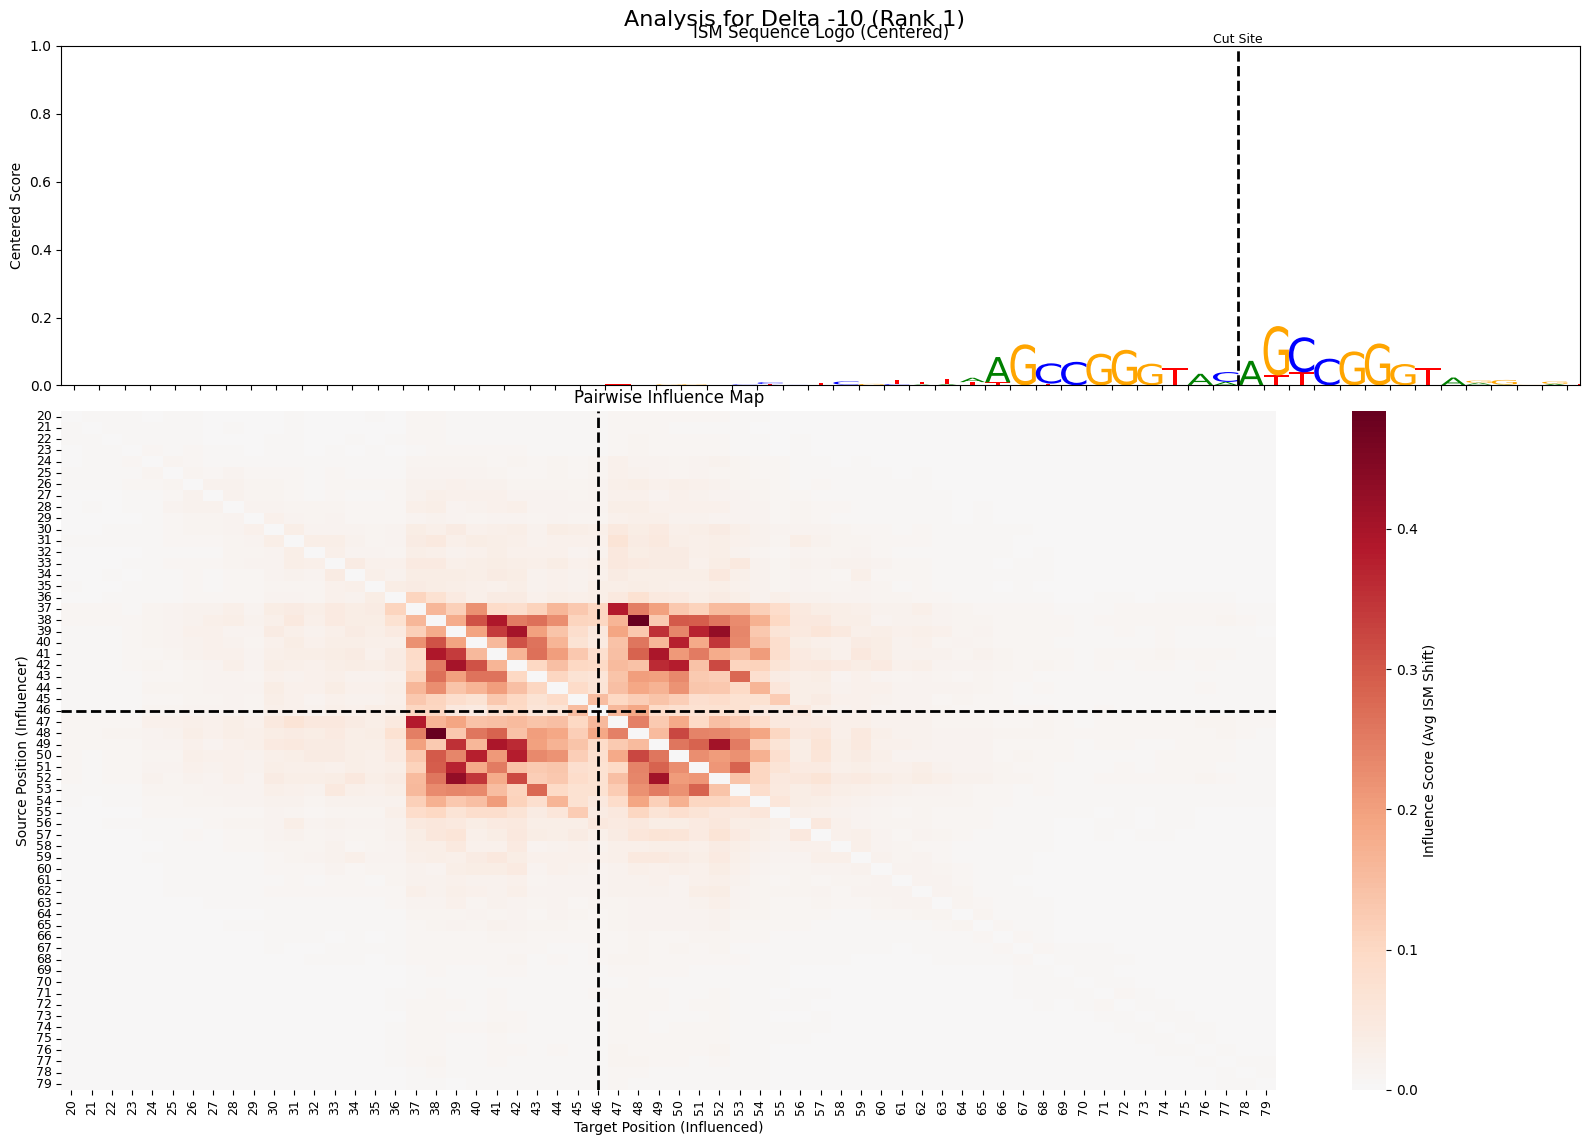

Saved combined plot to output/combined_plot_delta_-10_run_1.svg
Processing: Delta -10, Run 2


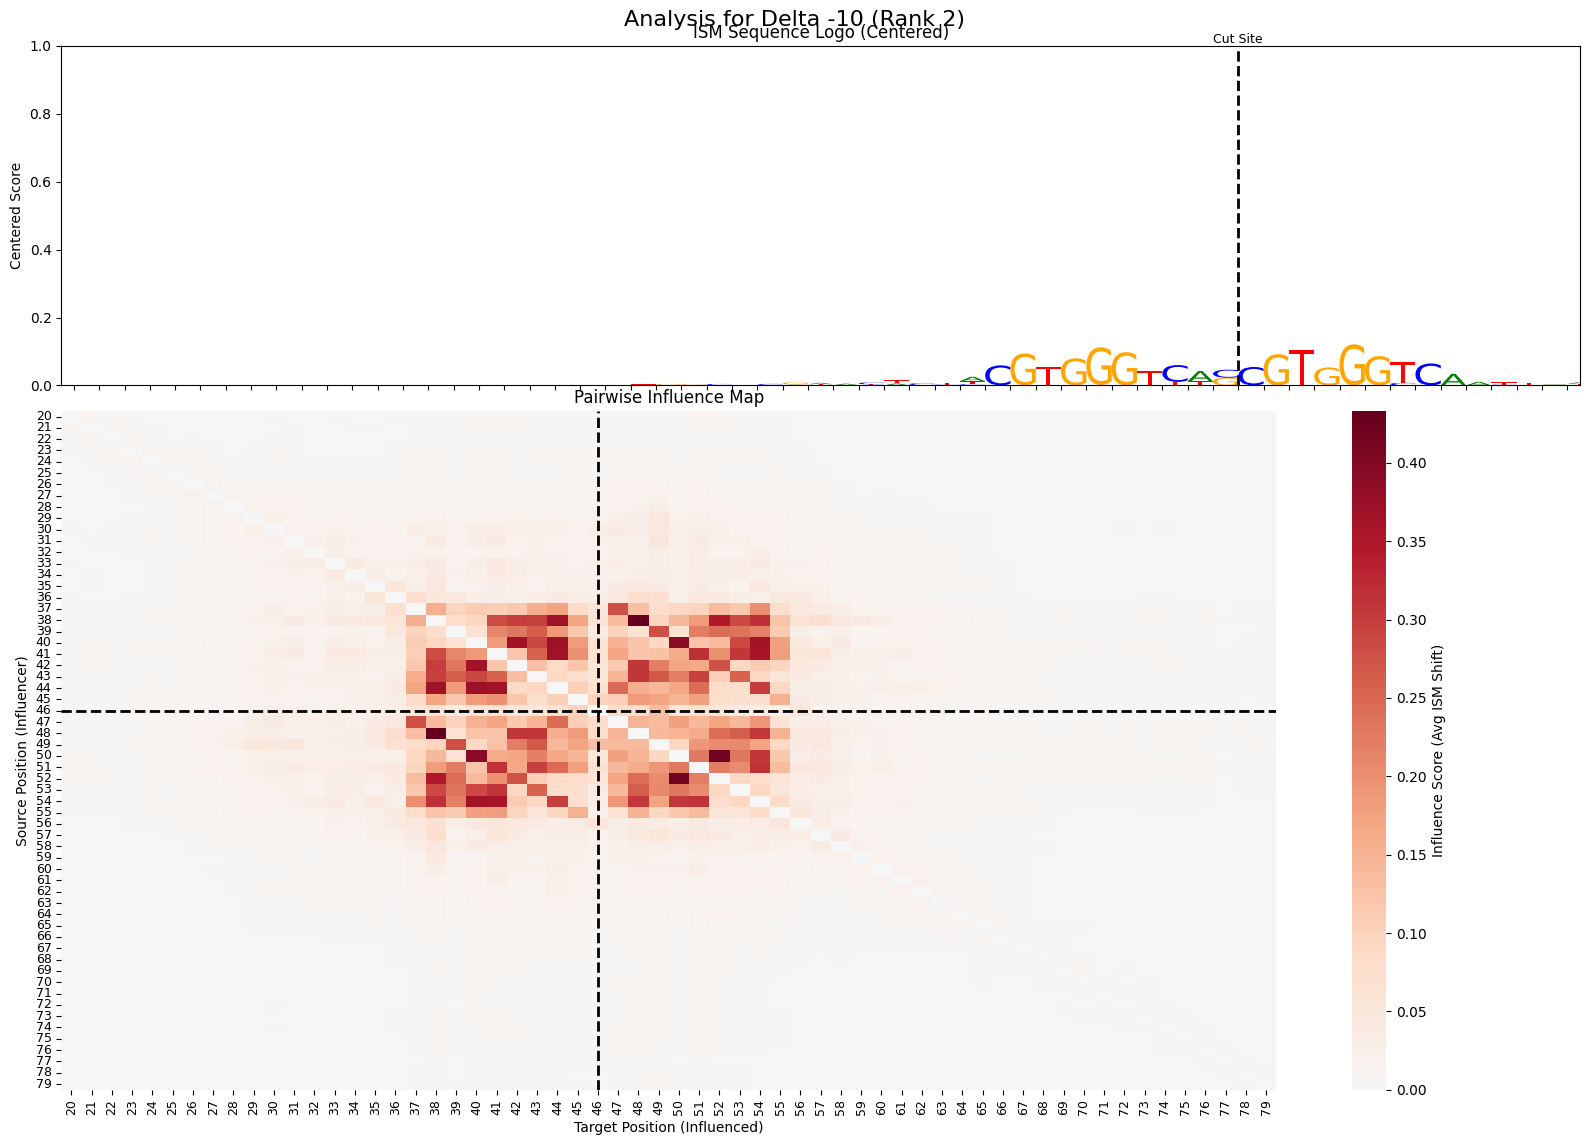

Saved combined plot to output/combined_plot_delta_-10_run_2.svg
Processing: Delta -10, Run 3


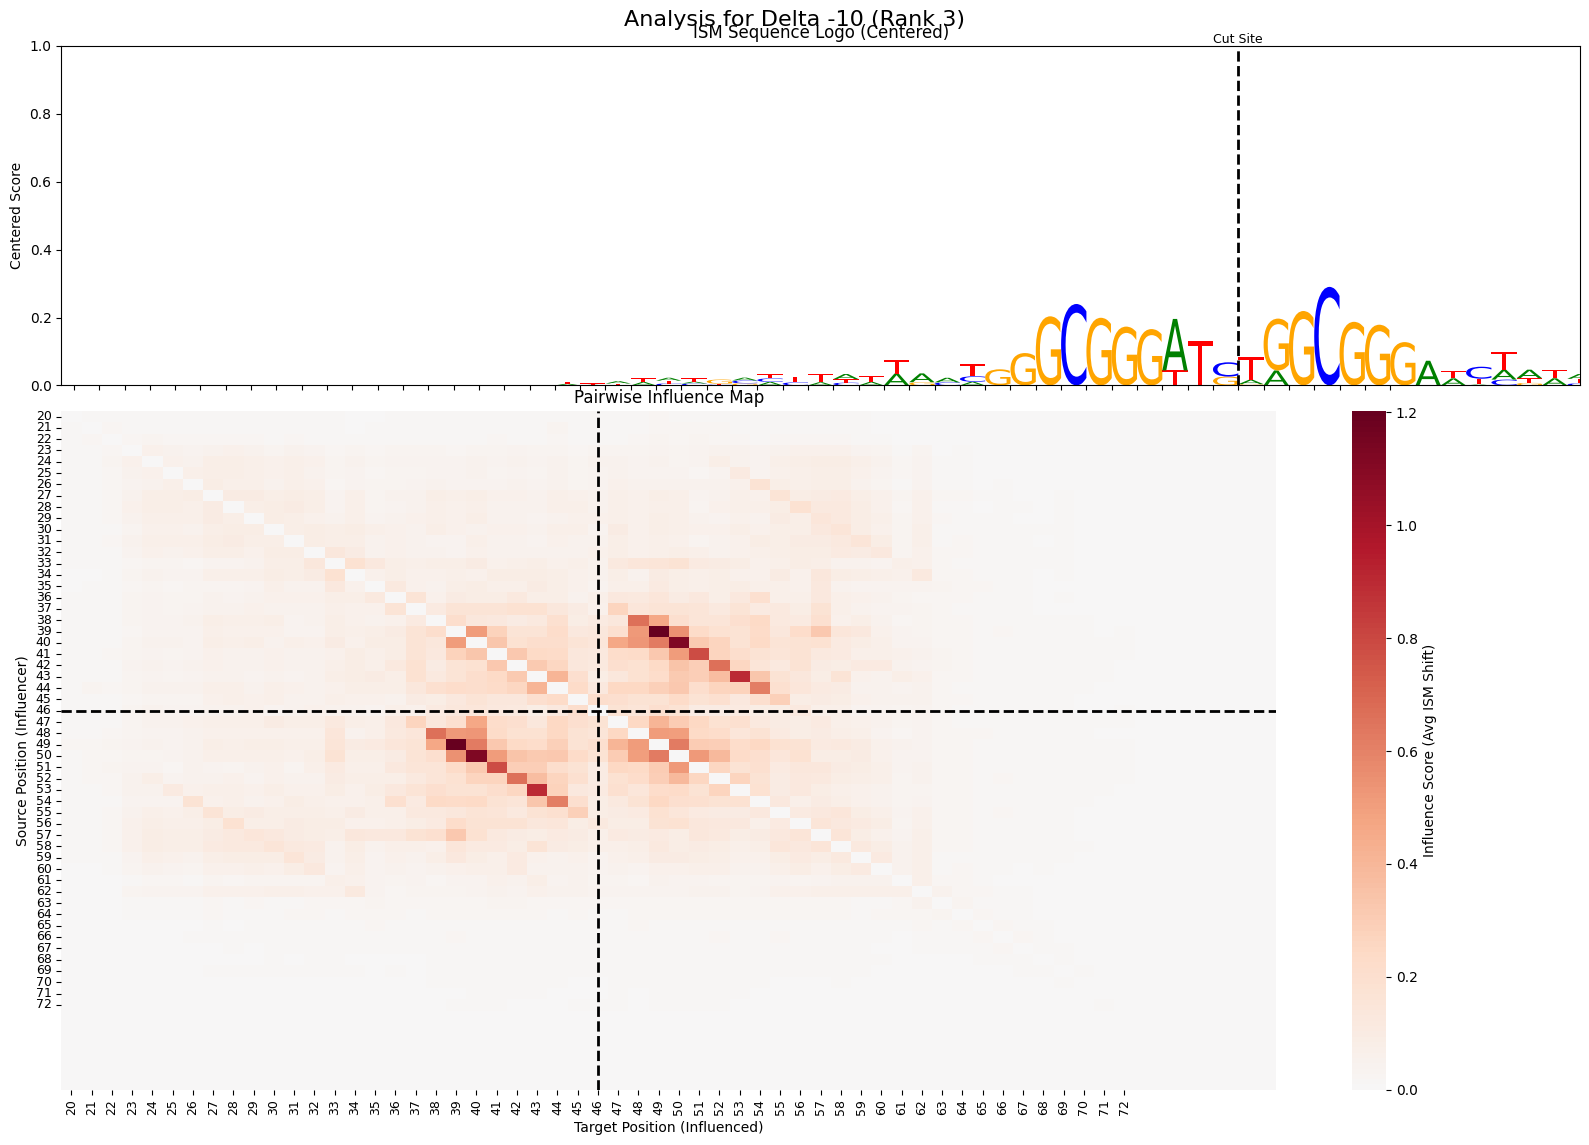

Saved combined plot to output/combined_plot_delta_-10_run_3.svg


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
import seaborn as sns

def visualize_combined_plot(ism_path, influence_path, inf_crop_min=None, inf_crop_max=None, delta=None, i=None):
    """
    Creates a single figure with two subplots stacked vertically:
    Top: ISM Sequence Logo
    Bottom: Influence Heatmap
    They share the X-axis (Genomic Position).
    """

    # --- Helper Function for Drawing Logos ---
    def draw_logo(ax, df, x_col='Pos', cols=['> A', '> C', '> G', '> T']):
        letters = {}
        for char in ['A', 'C', 'G', 'T']:
            tp = TextPath((0, 0), char, size=1)
            bbox = tp.get_extents()
            trans = Affine2D().translate(-bbox.x0, -bbox.y0).scale(1/bbox.width, 1/bbox.height)
            letters[char] = tp.transformed(trans)

        colors = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
        
        for idx, row in df.iterrows():
            x_pos = row[x_col]
            scores = {c[-1]: row[c] for c in cols}
            
            pos_scores = sorted({k: v for k, v in scores.items() if v >= 0}.items(), key=lambda x: x[1])
            neg_scores = sorted({k: v for k, v in scores.items() if v < 0}.items(), key=lambda x: abs(x[1]))
            
            y_off = 0
            for char, h in pos_scores:
                if h < 1e-6: continue
                path = letters[char]
                trans = Affine2D().scale(1.0, h).translate(x_pos - 0.5, y_off)
                patch = PathPatch(path, facecolor=colors[char], edgecolor='none', linewidth=0, transform=trans + ax.transData)
                ax.add_patch(patch)
                y_off += h
                
            y_off = 0
            for char, h in neg_scores:
                if abs(h) < 1e-6: continue
                path = letters[char]
                trans = Affine2D().scale(1.0, h).translate(x_pos - 0.5, y_off)
                patch = PathPatch(path, facecolor=colors[char], edgecolor='none', linewidth=0, transform=trans + ax.transData)
                ax.add_patch(patch)
                y_off += h

    # --- 1. Load Data ---
    print(f"Processing: Delta {delta}, Run {i}")
    df_ism = pd.read_csv(ism_path)
    df_inf = pd.read_csv(influence_path)

    # --- 2. Crop Data ---
    # We must ensure both plots show the exact same region.
    if inf_crop_min is not None and inf_crop_max is not None:
        # Crop ISM based on 'Pos' column values
        mask = (df_ism['Pos'] >= inf_crop_min) & (df_ism['Pos'] < inf_crop_max)
        df_ism_crop = df_ism[mask].copy()
        
        # Crop Influence based on matrix indices (assuming 0-indexed mapping to positions)
        df_inf_crop = df_inf.iloc[inf_crop_min:inf_crop_max, inf_crop_min:inf_crop_max]
        
        current_min_pos = inf_crop_min
        current_max_pos = inf_crop_max - 1
    else:
        df_ism_crop = df_ism.copy()
        df_inf_crop = df_inf.copy()
        current_min_pos = df_ism['Pos'].min()
        current_max_pos = df_ism['Pos'].max()

    # --- 3. Normalize ISM (Mean Centering) ---
    score_cols = ['> A', '> C', '> G', '> T']
    means = df_ism_crop[score_cols].mean(axis=1)
    for col in score_cols:
        df_ism_crop[col] = df_ism_crop[col] - means

    # --- 4. Setup Figure and Subplots ---
    # 2 rows, 1 column. Share X axis. 
    # height_ratios lets us make the heatmap taller than the logo.
    fig, (ax_logo, ax_heatmap) = plt.subplots(
        nrows=2, ncols=1, 
        figsize=(16, 12), 
        sharex=True, 
        gridspec_kw={'height_ratios': [1, 2]}
    )
    
    fig.suptitle(f"Analysis for Delta {delta} (Rank {i})", fontsize=16, y=0.95)

    # --- 5. Plot Top Subplot (Sequence Logo) ---
    draw_logo(ax_logo, df_ism_crop)
    
    ax_logo.set_title("ISM Sequence Logo (Centered)")
    ax_logo.set_ylabel("Centered Score")
    ax_logo.axhline(0, color='black', lw=0.5) # Add baseline
    
    # Mark Cut Site on Logo
    cut_pos = 46.5
    if current_min_pos <= cut_pos <= current_max_pos:
        ax_logo.axvline(x=cut_pos, color='black', linestyle='--', linewidth=2)
        ax_logo.text(cut_pos, ax_logo.get_ylim()[1], 'Cut Site', ha='center', va='bottom', fontsize=9)

    # --- 6. Plot Bottom Subplot (Influence Heatmap) ---
    # Seaborn heatmap plots against index (0..N). We need to force it to plot 
    # against the actual genomic positions.
    
    # Get the actual positions for labels
    tick_labels = df_ism_crop['Pos'].astype(str).tolist()

    sns.heatmap(
        df_inf_crop, 
        cmap='RdBu_r', # Red-Blue diverging usually good for influence (+/-)
        center=0, 
        ax=ax_heatmap,
        cbar_kws={'label': 'Influence Score (Avg ISM Shift)'},
        xticklabels=tick_labels,
        yticklabels=tick_labels
    )
    
    ax_heatmap.set_title("Pairwise Influence Map")
    ax_heatmap.set_xlabel("Target Position (Influenced)")
    ax_heatmap.set_ylabel("Source Position (Influencer)")
    
    # Mark Cut Site on Heatmap (both axes)
    # We need to find the *index* within the cropped view that corresponds to the cut pos
    if current_min_pos <= cut_pos <= current_max_pos:
        # Calculate relative index for the line
        rel_cut_idx = cut_pos - current_min_pos
        ax_heatmap.axvline(x=rel_cut_idx, color='black', linestyle='--', linewidth=2)
        ax_heatmap.axhline(y=rel_cut_idx, color='black', linestyle='--', linewidth=2)

    # Format ticks for cleaner view if many positions exist
    ax_heatmap.tick_params(axis='x', rotation=90, labelsize=9)
    ax_heatmap.tick_params(axis='y', rotation=0, labelsize=9)

    # --- Final Layout Adjustments ---
    plt.tight_layout()
    # Adjust layout to prevent title overlap
    fig.subplots_adjust(top=0.92, hspace=0.05) 
    
    output_filename = f'output/combined_plot_delta_{delta}_run_{i}.svg'
    plt.savefig(output_filename, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved combined plot to {output_filename}")


# --- Execution Loop ---
# Ensure 'output' directory exists
import os
if not os.path.exists('output'):
    os.makedirs('output')

# Example loop (adjust paths and crop ranges to your data)
for i in range(1, 4):
    ism_file = f"ISM/ism_FORECasT K562_delta_-10_{i}.csv"
    inf_file = f"ISM/influence_map_FORECasT K562_delta_-10_rank_{i}.csv"
    
    # Using a wider crop range (e.g., 20 to 80) to see more context
    visualize_combined_plot(ism_file, inf_file, inf_crop_min=20, inf_crop_max=80, delta=-10, i=i)

## Sweeps

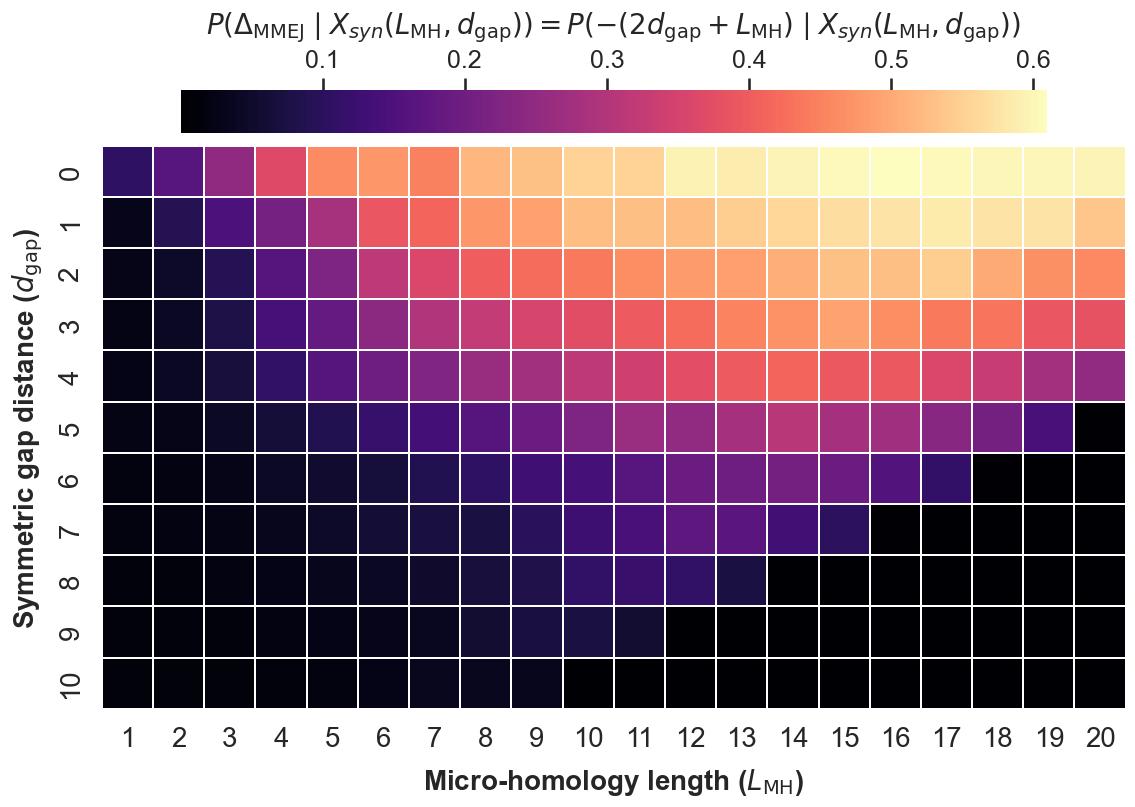

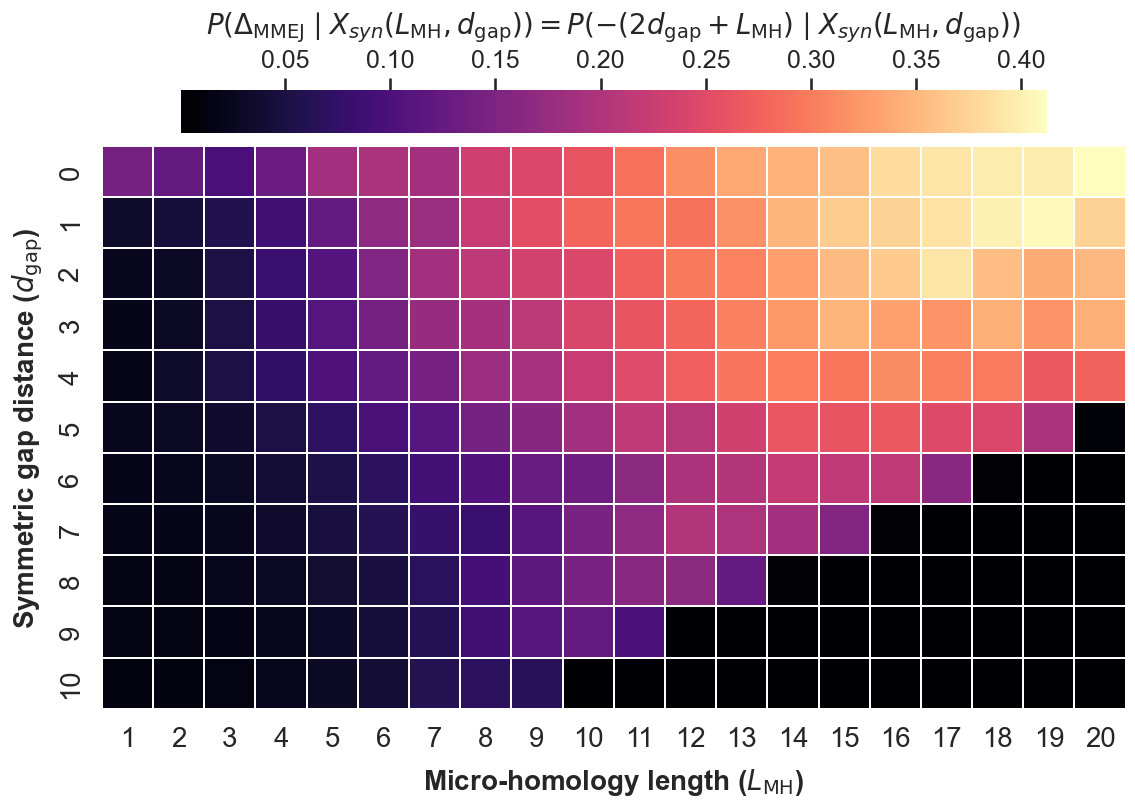

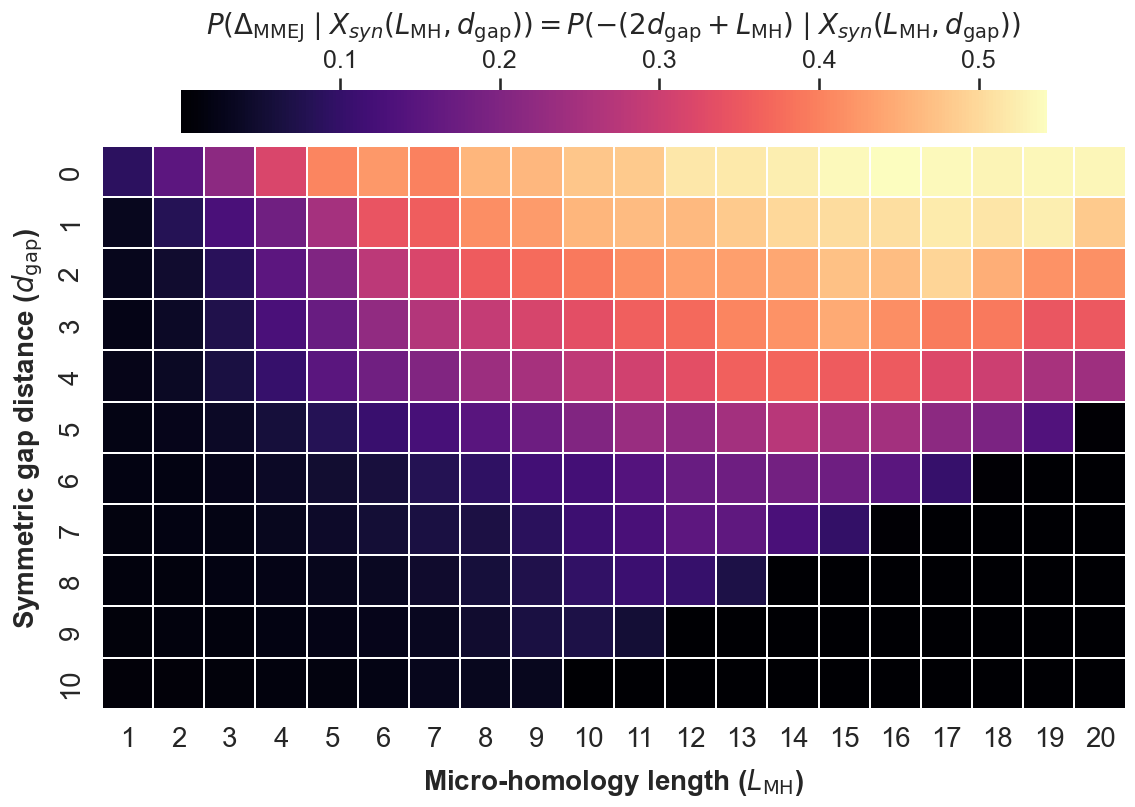

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_mmej_heatmap(path = None, output_path = None):

    # 1. Load the data
    df = pd.read_csv(path, index_col=0)

    # Set global styles
    sns.set_style("white")
    sns.set_context("talk", font_scale=1.2)

    # 2. Plotting
    # Using a slightly taller figure since the heatmap will shrink horizontally
    fig, ax = plt.subplots(figsize=(12, 8))

    # Clean labels
    x_labels = [x.split('_')[1] for x in df.columns]
    y_labels = [x.split('_')[1] for x in df.index]

    # Create the heatmap
    # We remove cbar_ax and use cbar_kws to place it at the top
    heatmap = sns.heatmap(
        df, 
        annot=False, 
        cmap='magma', 
        xticklabels=x_labels, 
        yticklabels=y_labels,
        linewidths=0.01,
        linecolor='white',
        square=True,
        cbar_kws={
            'orientation': 'horizontal', 
            'location': 'top', 
            'fraction': 0.07,  # Adjusts the height of the bar
            'pad': 0.02,       # Space between bar and plot
            'shrink': 0.85,     # THIS MATCHES THE BAR WIDTH TO THE SQUARED HEATMAP
            
        },
        ax=ax
    )

    # Access the colorbar to style it
    cbar = ax.collections[0].colorbar

    # Axis labels
    ax.set_xlabel(r'Micro-homology length ($L_{\text{MH}}$)', fontsize=20, fontweight='bold', labelpad=10)
    ax.set_ylabel(r'Symmetric gap distance ($d_{\text{gap}}$)', fontsize=20, fontweight='bold', labelpad=10)

    # Updated colorbar label
    # colorbar_label = (
    #     r'Expected MMEJ deletion efficiency = '
    #     r'$P(\Delta_{\text{MMEJ}} \mid X_{syn}(L_{\text{MH}}, d_{\text{gap}})) = '
    #     r'P(-(2d_{\text{gap}} + L_{\text{MH}}) \mid X_{syn}(L_{\text{MH}}, d_{\text{gap}}))$'
    # )
    colorbar_label = (
        #r'Expected MMEJ deletion efficiency = '
        r'$P(\Delta_{\text{MMEJ}} \mid X_{syn}(L_{\text{MH}}, d_{\text{gap}})) = '
        r'P(-(2d_{\text{gap}} + L_{\text{MH}}) \mid X_{syn}(L_{\text{MH}}, d_{\text{gap}}))$'
    )
    cbar.set_label(colorbar_label, fontsize=20, fontweight='bold', labelpad=12)
    cbar.ax.xaxis.set_ticks_position('top')

    # Only changed labelsize here to make ticks larger
    cbar.ax.tick_params(labelsize=18) 

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight')
    plt.show()

plot_mmej_heatmap(path = "TRD/mh_sweep_matrix_ds0.csv", output_path = "output/mmej_sweep_aligned_ds0.pdf" )
plot_mmej_heatmap(path = "TRD/mh_sweep_matrix_ds9.csv", output_path = "output/mmej_sweep_aligned_ds9.pdf" )
plot_mmej_heatmap(path = "TRD/mh_sweep_matrix_ds10.csv", output_path = "output/mmej_sweep_aligned_ds10.pdf" )


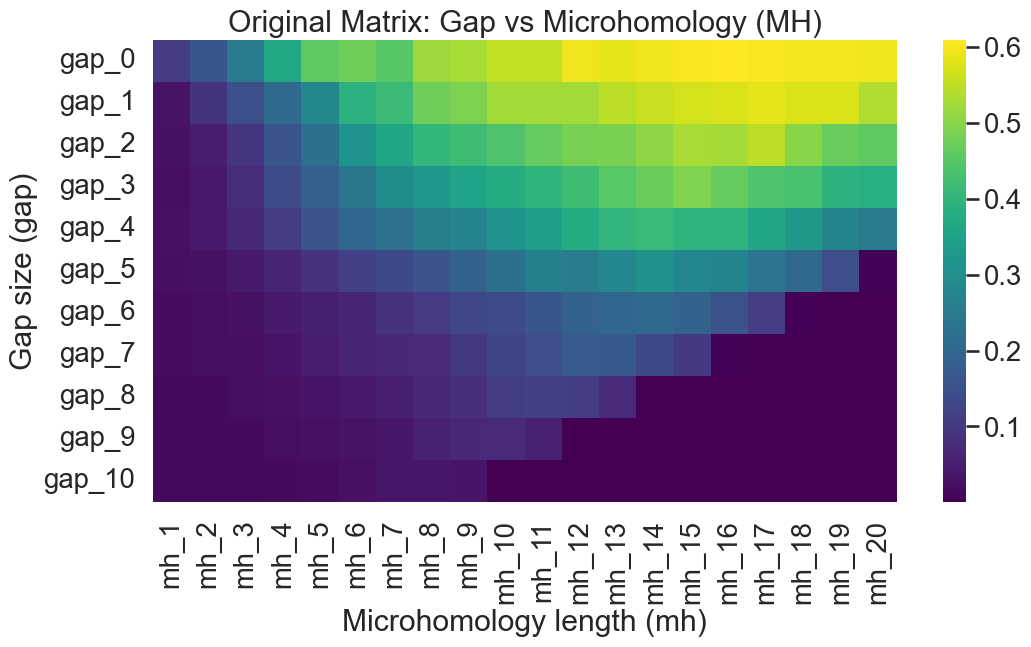

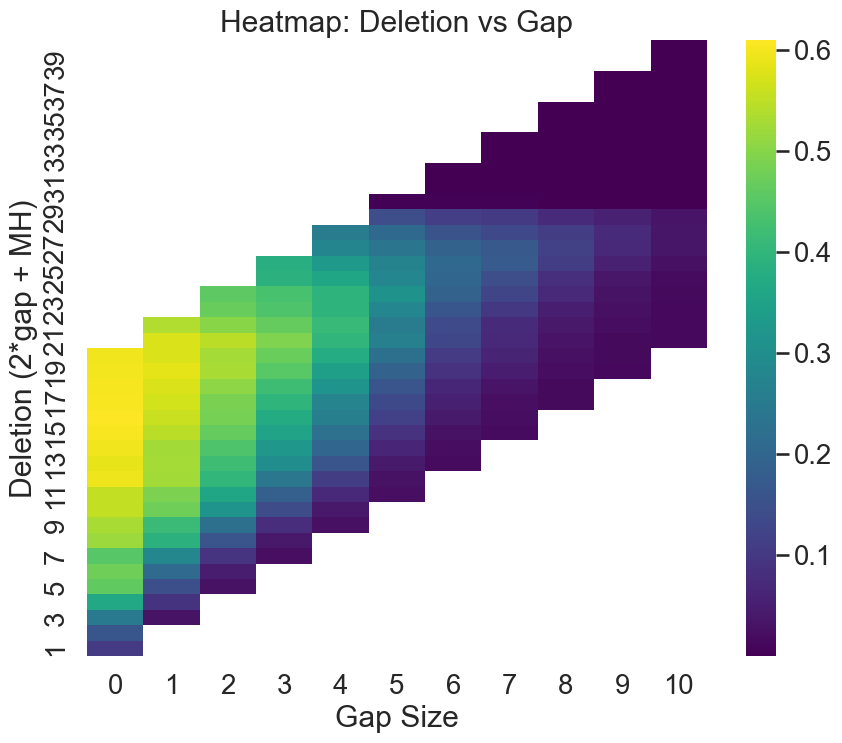

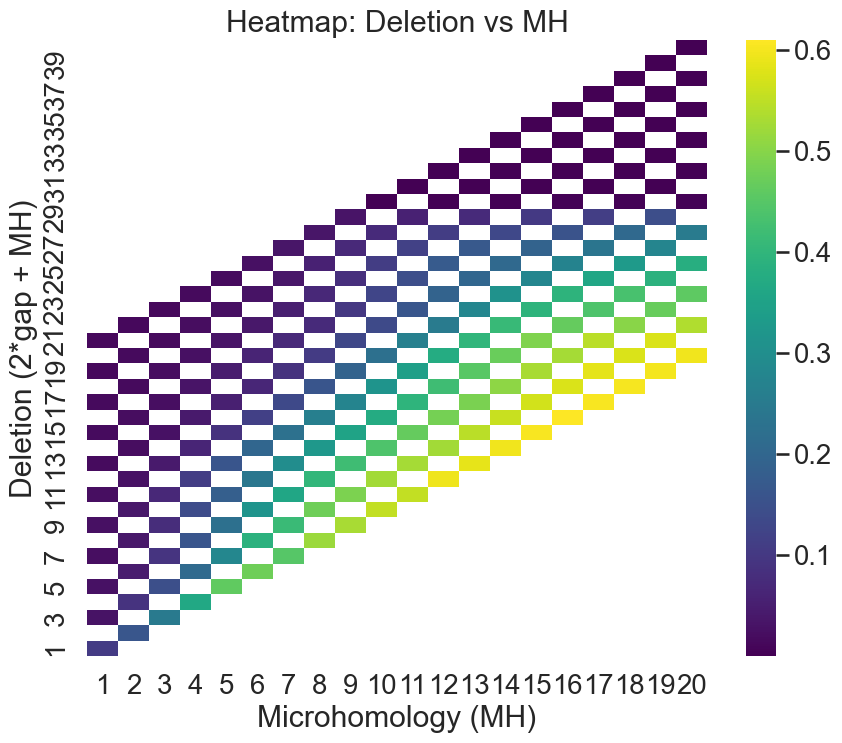

Processing complete. Files 'output/original_matrix.pdf', 'output/deletion_vs_gap.pdf', and 'output/deletion_vs_mh.pdf' have been created.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
# The file has 'gap_X' as index and 'mh_X' as columns
df = pd.read_csv('TRD/mh_sweep_matrix_ds0.csv', index_col=0)

# 2. Plot the original matrix
plt.figure(figsize=(12, 6))
sns.heatmap(df, annot=False, cmap='viridis')
plt.title('Original Matrix: Gap vs Microhomology (MH)')
plt.xlabel('Microhomology length (mh)')
plt.ylabel('Gap size (gap)')
plt.savefig('output/original_matrix.pdf')
plt.show()
plt.close()

# 3. Data Transformation & Calculation
# Clean index and column names to be numeric (removing 'gap_' and 'mh_' prefixes)
df.index = [int(x.split('_')[1]) for x in df.index]
df.columns = [int(x.split('_')[1]) for x in df.columns]

# Reshape (melt) the matrix into a long-form table for calculations
df_long = df.reset_index().melt(id_vars='index', var_name='mh', value_name='value')
df_long.rename(columns={'index': 'gap'}, inplace=True)

# Calculate deletion length: deletion = gap * 2 + MH
df_long['deletion'] = df_long['gap'] * 2 + df_long['mh']

# 4. Plot Matrix: Deletion vs Gap
# Pivot the long-form data back into a matrix format
pivot_del_gap = df_long.pivot(index='deletion', columns='gap', values='value')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_del_gap, cmap='viridis')
plt.title('Heatmap: Deletion vs Gap')
plt.xlabel('Gap Size')
plt.ylabel('Deletion (2*gap + MH)')
plt.gca().invert_yaxis() # Invert y-axis so deletion size increases upwards
plt.savefig('output/deletion_vs_gap.pdf')
plt.show()
plt.close()

# 5. Plot Matrix: Deletion vs MH
pivot_del_mh = df_long.pivot(index='deletion', columns='mh', values='value')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_del_mh, cmap='viridis')
plt.title('Heatmap: Deletion vs MH')
plt.xlabel('Microhomology (MH)')
plt.ylabel('Deletion (2*gap + MH)')
plt.gca().invert_yaxis()
plt.savefig('output/deletion_vs_mh.pdf')
plt.show()
plt.close()

print("Processing complete. Files 'output/original_matrix.pdf', 'output/deletion_vs_gap.pdf', and 'output/deletion_vs_mh.pdf' have been created.")

# Heatmap

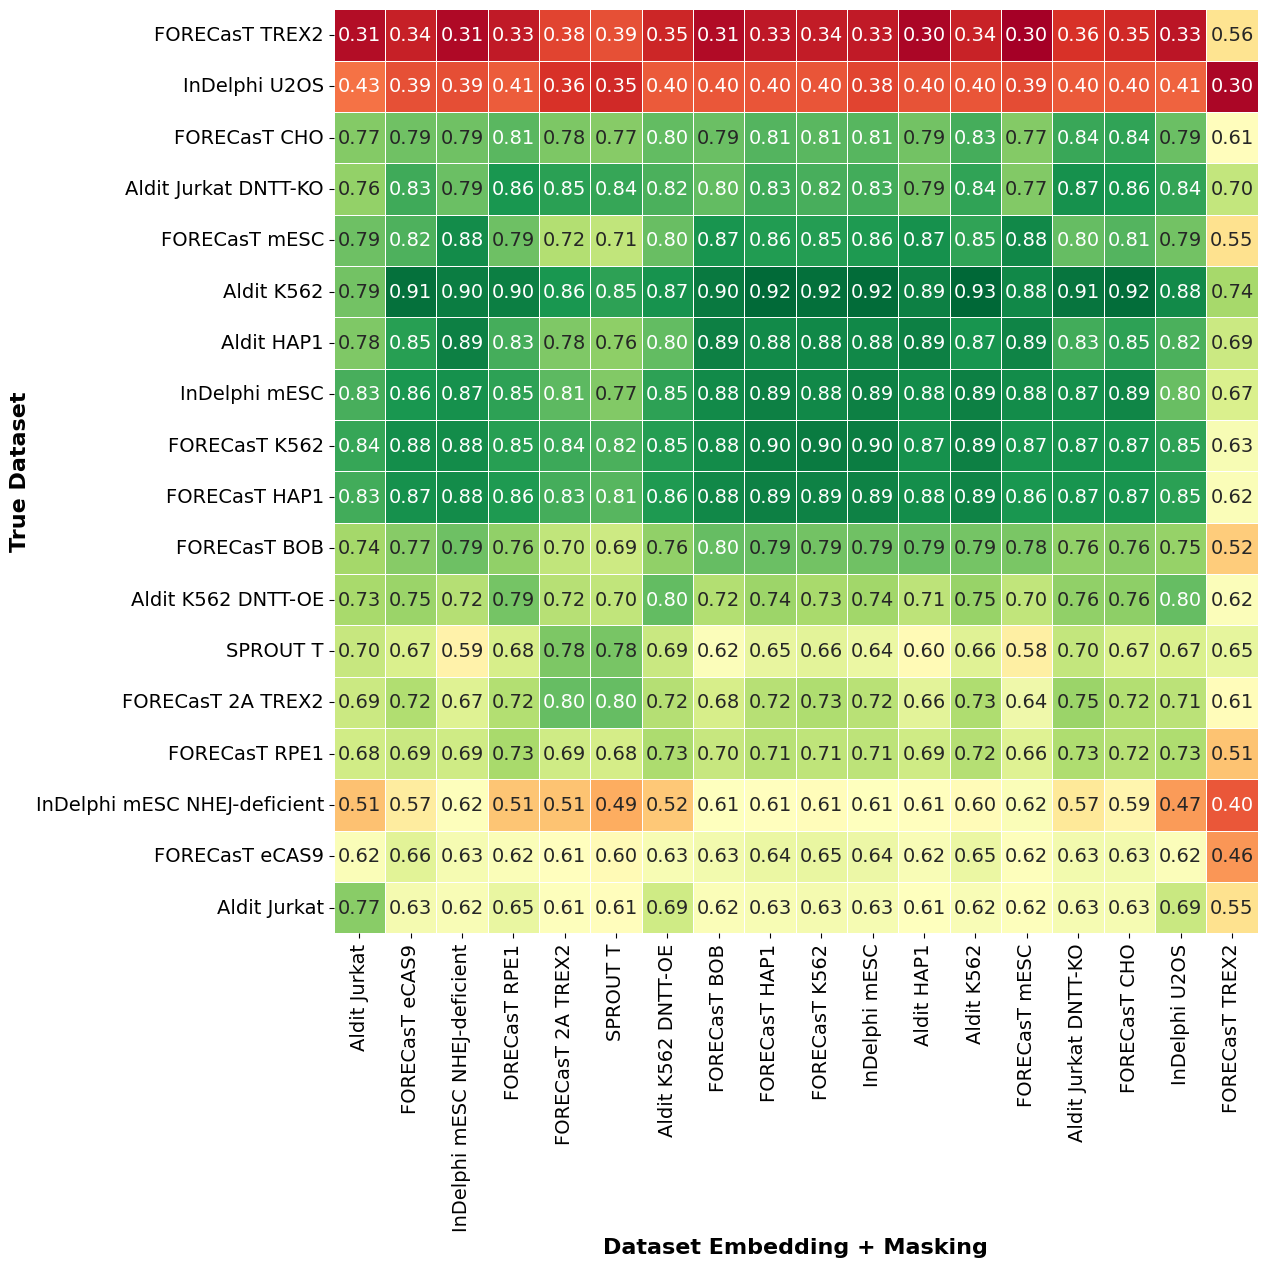

--- Plot saved to output/experiment_1_clean_heatmap.pdf ---


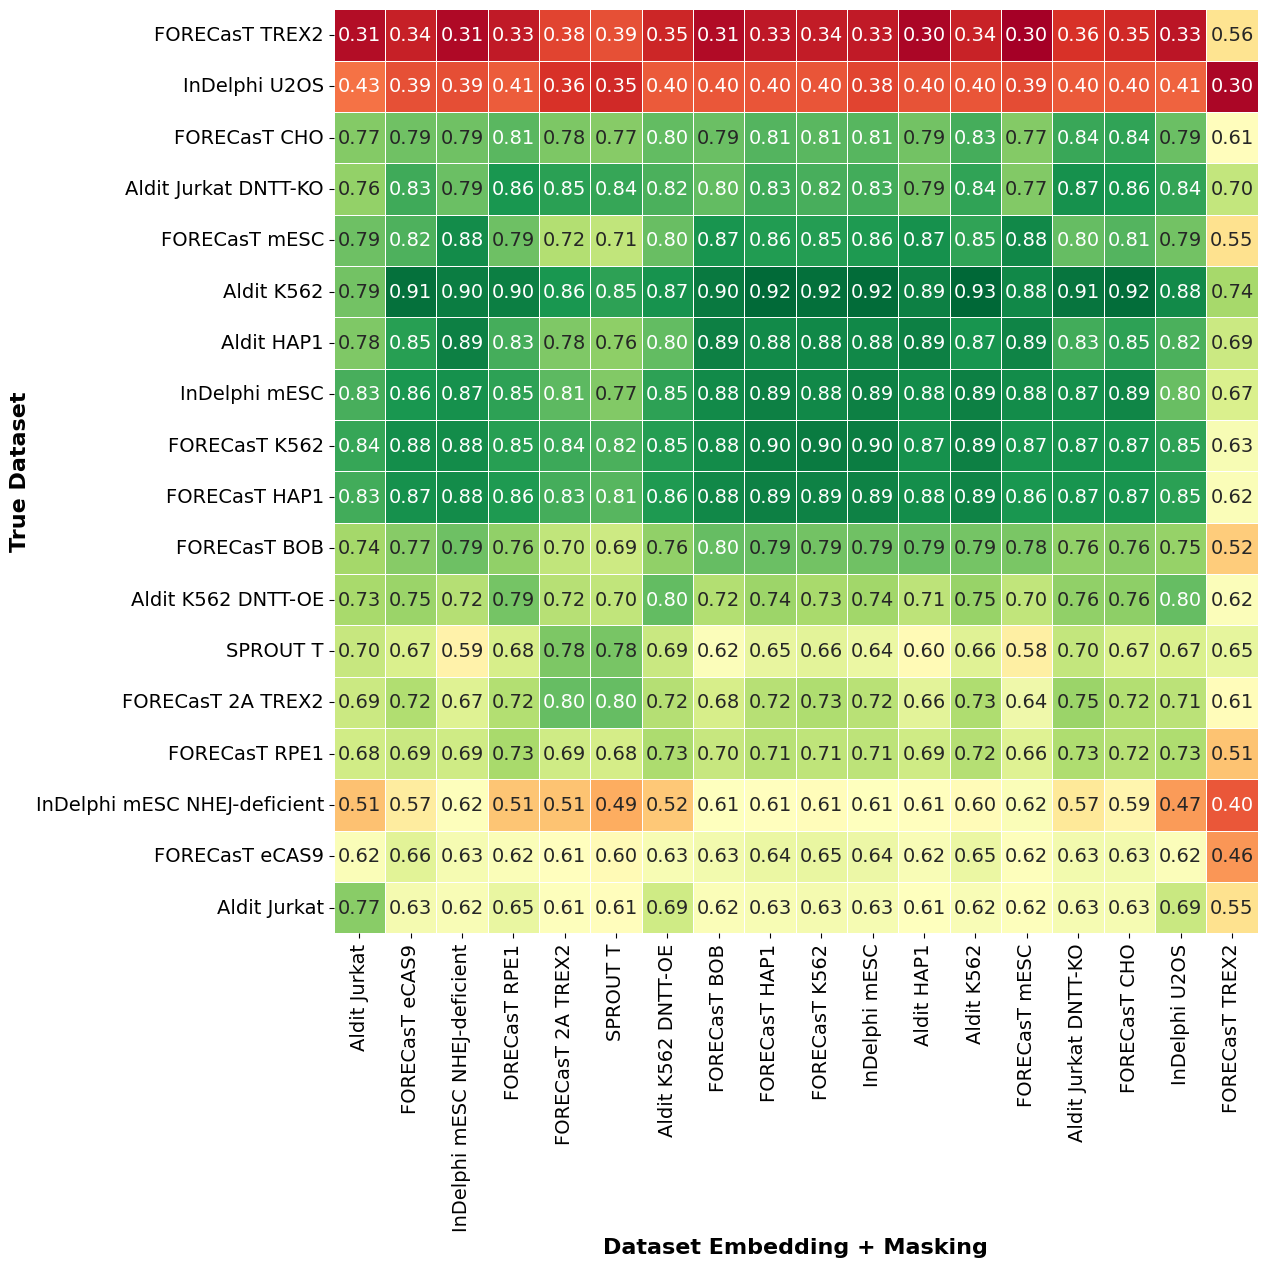

--- Plot saved to output/experiment_1_clean_heatmap.svg ---


In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.spatial import distance

def plot_ordered_pearson_heatmap(csv_path, output_filename='output/ordered_pearson_matrix.pdf'):
    """
    Plots a clean Pearson matrix using sns.heatmap (removes clustermap whitespace).
    """
    # 1. Load the data
    df = pd.read_csv(csv_path, index_col=0)
    
    # 2. Define Manual Selection
    manual_selection = [
        'FORECasT K562', 'FORECasT eCAS9', 'FORECasT TREX2', 'FORECasT 2A TREX2',
        'FORECasT HAP1', 'FORECasT BOB', 'FORECasT CHO', 'FORECasT RPE1', 'FORECasT mESC',
        'SPROUT T', 
        'Aldit K562', 'Aldit K562 DNTTOE', 'Aldit HAP1', 'Aldit Jurkat', 'Aldit Jurkat DNTTKO',
        'InDelphi mESC', 'InDelphi mESC NHEJdeficient', 'InDelphi U2OS'
    ]

    # 3. Filter DataFrame
    existing_order = [x for x in manual_selection if x in df.index]
    df_subset = df.loc[existing_order, existing_order]
    
    df_subset.rename(index={'InDelphi mESC NHEJdeficient': 'InDelphi mESC NHEJ-deficient'},
                     columns={'InDelphi mESC NHEJdeficient': 'InDelphi mESC NHEJ-deficient'}, inplace=True)
    
    df_subset.rename(index={'Aldit Jurkat DNTTKO': 'Aldit Jurkat DNTT-KO'},
                     columns={'Aldit Jurkat DNTTKO': 'Aldit Jurkat DNTT-KO'}, inplace=True)
    
    df_subset.rename(index={'Aldit K562 DNTTOE': 'Aldit K562 DNTT-OE'},
                     columns={'Aldit K562 DNTTOE': 'Aldit K562 DNTT-OE'}, inplace=True)

    # 4. Compute Row Linkage (To find the correct order)
    row_linkage = hierarchy.linkage(distance.pdist(df_subset), method='average')
    
    # 5. Get the order of leaves
    dendro = hierarchy.dendrogram(row_linkage, no_plot=True)
    row_leaf_order = dendro['leaves']

    col_leaf_order = row_leaf_order  # Since we want the same order for columns
    # reverse it
    col_leaf_order = col_leaf_order[::-1]
    
    # 6. Reorder BOTH Rows and Columns manually
    df_final = df_subset.iloc[row_leaf_order, col_leaf_order]

    # 7. Generate the Heatmap (Using sns.heatmap instead of clustermap)
    plt.figure(figsize=(14, 12)) # Control the size directly here
    
# Capture the axes object to modify labels later
    ax = sns.heatmap(
        df_final, 
        cmap='RdYlGn',       
        annot=True, 
        fmt=".2f", 
        linewidths=.5,
        cbar=False,
        square=True,
        # --- CHANGE 1: Increase font size inside the cells ---
        annot_kws={"size": 14}  # Adjust this number to fit your preference
    )

    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    # 8. Label the axes
    plt.xlabel('Dataset Embedding + Masking', fontsize=16, fontweight='bold')
    plt.ylabel('True Dataset', fontsize=16, fontweight='bold')

    # remove labels for cleaner look
    #plt.xlabel('')
    #plt.ylabel('')

    

    # 9. Save and export
    # bbox_inches='tight' works much better with simple heatmaps
    plt.savefig(output_filename, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"--- Plot saved to {output_filename} ---")



# Execute the function
plot_ordered_pearson_heatmap('CD/experiment_1_pearson_matrix.csv', output_filename='output/experiment_1_clean_heatmap.pdf')
plot_ordered_pearson_heatmap('CD/experiment_1_pearson_matrix.csv', output_filename='output/experiment_1_clean_heatmap.svg')


In [93]:
import pandas as pd
import numpy as np

def get_off_diagonal_median(csv_path):
    # 1. Load the data
    df = pd.read_csv(csv_path, index_col=0)
    
    # 2. Filter to the specific datasets used in your study
    manual_selection = [
        'FORECasT K562', 'FORECasT eCAS9', 'FORECasT TREX2', 'FORECasT 2A TREX2',
        'FORECasT HAP1', 'FORECasT BOB', 'FORECasT CHO', 'FORECasT RPE1', 'FORECasT mESC',
        'SPROUT T', 
        'Aldit K562', 'Aldit K562 DNTTOE', 'Aldit HAP1', 'Aldit Jurkat', 'Aldit Jurkat DNTTKO',
        'InDelphi mESC', 'InDelphi mESC NHEJdeficient', 'InDelphi U2OS'
    ]
    existing_order = [x for x in manual_selection if x in df.index]
    df_subset = df.loc[existing_order, existing_order]

    # 3. Extract the underlying numpy array
    matrix_values = df_subset.values
    
    # 4. Create a mask for all elements EXCEPT the diagonal
    # np.eye creates a matrix of 1s on the diagonal; ~ flips it to select everything else
    off_diag_mask = ~np.eye(matrix_values.shape[0], dtype=bool)
    
    # 5. Extract those values and calculate the median
    off_diag_values = matrix_values[off_diag_mask]
    median_val = np.median(off_diag_values)
    
    return median_val

# Execute and print
csv_file = 'CD/experiment_1_pearson_matrix.csv'
median = get_off_diagonal_median(csv_file)

print(f"Median Pearson (Off-Diagonal): {median:.4f}")

Median Pearson (Off-Diagonal): 0.7337


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

def analyze_dataset_correlations(csv_path):
    # 1. Load the data
    df = pd.read_csv(csv_path, index_col=0)
    
    # 2. Define Manual Selection (Matching your heatmap code)
    manual_selection = [
        'FORECasT K562', 'FORECasT eCAS9', 'FORECasT TREX2', 'FORECasT 2A TREX2',
        'FORECasT HAP1', 'FORECasT BOB', 'FORECasT CHO', 'FORECasT RPE1', 'FORECasT mESC',
        'SPROUT T', 
        'Aldit K562', 'Aldit K562 DNTTOE', 'Aldit HAP1', 'Aldit Jurkat', 'Aldit Jurkat DNTTKO',
        'InDelphi mESC', 'InDelphi mESC NHEJdeficient', 'InDelphi U2OS'
    ]

    # 3. Filter and Rename
    existing_order = [x for x in manual_selection if x in df.index]
    df_subset = df.loc[existing_order, existing_order]
    
    rename_map = {
        'InDelphi mESC NHEJdeficient': 'InDelphi mESC NHEJ-deficient',
        'Aldit Jurkat DNTTKO': 'Aldit Jurkat DNTT-KO',
        'Aldit K562 DNTTOE': 'Aldit K562 DNTT-OE'
    }
    df_subset.rename(index=rename_map, columns=rename_map, inplace=True)

    # 4. Calculate Mean and STD for all columns
    column_means = df_subset.mean()
    column_stds = df_subset.std()
    
    # Create a summary table
    summary_stats = pd.DataFrame({
        'Mean': column_means,
        'STD': column_stds
    }).sort_values(by='Mean', ascending=False)

    print("--- Summary Statistics per Column (Ordered by Mean) ---")
    print(summary_stats)
    print("\n" + "="*50 + "\n")

    # 5. Identify the Best Column
    best_dataset = summary_stats.index[0]
    best_vals = df_subset[best_dataset]
    
    print(f"Reference Dataset (Best Avg): {best_dataset}")
    print(f"Stats: {summary_stats.loc[best_dataset, 'Mean']:.4f} ± {summary_stats.loc[best_dataset, 'STD']:.4f}")
    print("-" * 50)

    # 6. Wilcoxon Rank Sum Tests (Pairwise: Best vs Each Other)
    stats_results = []
    others = [col for col in summary_stats.index if col != best_dataset]

    for other_col in others:
        other_vals = df_subset[other_col]
        # Perform Wilcoxon rank-sum test
        stat, p_val = ranksums(best_vals, other_vals)
        
        stats_results.append({
            'Comparison': f"{best_dataset} vs {other_col}",
            'Other_Mean': summary_stats.loc[other_col, 'Mean'],
            'Other_STD': summary_stats.loc[other_col, 'STD'],
            'Statistic': stat,
            'P_Value': p_val
        })

    # 7. Multiple Comparisons Correction (Benjamini-Hochberg)
    results_df = pd.DataFrame(stats_results)
    if not results_df.empty:
        rejected, p_corrected, _, _ = multipletests(results_df['P_Value'], method='fdr_bh')
        results_df['P_Value_Corrected'] = p_corrected
        results_df['Significant (alpha=0.05)'] = rejected

    # Display results
    print("--- Wilcoxon Test Results (Ordered by Mean) ---")
    pd.set_option('display.max_colwidth', None)
    # Added Other_STD to the display columns
    display_cols = ['Comparison', 'Other_Mean', 'Other_STD', 'P_Value', 'P_Value_Corrected', 'Significant (alpha=0.05)']
    print(results_df[display_cols].to_string(index=False))

# Execute
analyze_dataset_correlations('CD/experiment_1_pearson_matrix.csv')

--- Summary Statistics per Column (Ordered by Mean) ---
                                  Mean       STD
Aldit K562                    0.735896  0.166942
FORECasT HAP1                 0.734433  0.169585
FORECasT K562                 0.732876  0.167087
InDelphi mESC                 0.732772  0.171084
Aldit Jurkat DNTT-KO          0.730424  0.158879
FORECasT CHO                  0.730409  0.161365
FORECasT eCAS9                0.723369  0.160986
FORECasT BOB                  0.722054  0.170337
FORECasT RPE1                 0.718976  0.161520
Aldit K562 DNTT-OE            0.718788  0.154375
InDelphi mESC NHEJ-deficient  0.716771  0.172009
Aldit HAP1                    0.714564  0.171573
InDelphi U2OS                 0.711274  0.159618
FORECasT mESC                 0.706085  0.172702
FORECasT 2A TREX2             0.701405  0.151196
Aldit Jurkat                  0.697592  0.144316
SPROUT T                      0.690224  0.149236
FORECasT TREX2                0.577873  0.109401


Reference D

# Perf bar

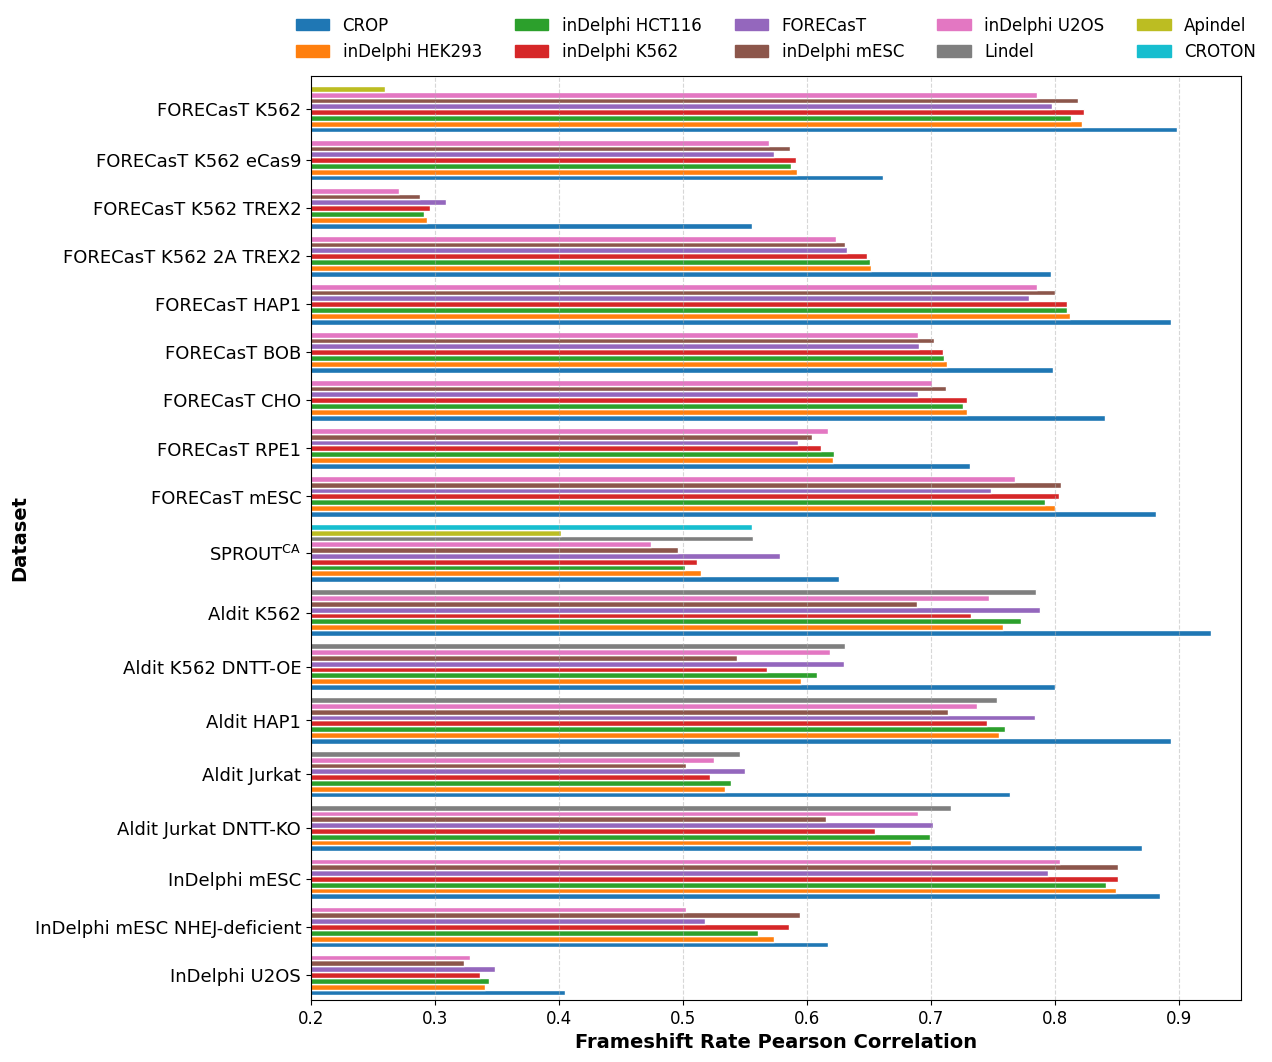

Success: Plot saved as output/pearson_bar_plot_custom.pdf


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_pearson_bar_custom(csv_path, output_name='pearson_bar_plot.png'):
    """
    Plots the Pearson correlation matrix as a grouped bar chart.
    - SORTING: Models ordered by Frequency (Count) -> Average Pearson.
    - LAYOUT: Variable row height (datasets with missing models take less space).
    - FORMATTING: Uses LaTeX formatting for SPROUT.
    """
    # 1. Load the data
    df = pd.read_csv(csv_path, index_col=0)
    
    # 2. Cleanup
    df = df.dropna(axis=1, how='all')
    df.index = [str(i).replace('.csv', '') for i in df.index]

    # --- STEP A: Rename DATASETS (Rows) ---
    dataset_rename_map = {
        'FORECasT_K562':           'FORECasT K562',
        'FORECasT_K562_eCAS9':     'FORECasT K562 eCas9',
        'FORECasT_K562_TREX2':     'FORECasT K562 TREX2',
        'FORECasT_K562_2A_TREX2':  'FORECasT K562 2A TREX2',
        'FORECasT_HAP1':           'FORECasT HAP1',
        'FORECasT_BOB':            'FORECasT BOB',
        'FORECasT_CHO':            'FORECasT CHO',
        'FORECasT_RPE1':           'FORECasT RPE1',
        'FORECasT_mESC':           'FORECasT mESC',
        'SPROUT_T_CROTON_VERSION': r'SPROUT$^{\mathrm{CA}}$',
        'ALDIT_K562':              'Aldit K562',
        'ALDIT_K562_DNTTOE':       'Aldit K562 DNTT-OE',
        'ALDIT_HAP1':              'Aldit HAP1',
        'ALDIT_Jurkat':            'Aldit Jurkat',
        'ALDIT_Jurkat_DNTTKO':     'Aldit Jurkat DNTT-KO',
        'XCRISP_inDelphi_mESC':                'InDelphi mESC',
        'XCRISP_inDelphi_mESC_NHEJdeficient':  'InDelphi mESC NHEJ-deficient',
        'XCRISP_inDelphi_U2OS':                'InDelphi U2OS'
    }
    df = df.rename(index=dataset_rename_map)

    # --- STEP B: Rename MODELS (Columns) ---
    model_rename_map = {
        'FORECasT_FS_ratio':  'FORECasT',
        'Lindel_FS_ratio':    'Lindel',
        'inDelphi_FS_HCT116': 'inDelphi HCT116',
        'inDelphi_FS_HEK293': 'inDelphi HEK293',
        'inDelphi_FS_K562':   'inDelphi K562',
        'inDelphi_FS_U2OS':   'inDelphi U2OS',
        'inDelphi_FS_mESC':   'inDelphi mESC',
        'Apindel':            'Apindel',
        'CROTON':             'CROTON',
        'CROP':               'CROP'
    }
    df = df.rename(columns=model_rename_map)

    # --- STEP C: Enforce Dataset Order ---
    dataset_order = [
        'FORECasT K562', 'FORECasT K562 eCas9', 'FORECasT K562 TREX2', 'FORECasT K562 2A TREX2',
        'FORECasT HAP1', 'FORECasT BOB', 'FORECasT CHO', 'FORECasT RPE1', 'FORECasT mESC',
        r'SPROUT$^{\mathrm{CA}}$',
        'Aldit K562', 'Aldit K562 DNTT-OE', 'Aldit HAP1', 'Aldit Jurkat', 'Aldit Jurkat DNTT-KO',
        'InDelphi mESC', 'InDelphi mESC NHEJ-deficient', 'InDelphi U2OS'
    ]
    # Filter to only datasets present in the file
    existing_dataset_order = [x for x in dataset_order if x in df.index]
    df = df.reindex(existing_dataset_order)

    # --- STEP D: DATA-DRIVEN MODEL SORTING ---
    # 1. Calculate Count (Frequency of non-NaNs)
    model_counts = df.count()
    # 2. Calculate Average Pearson
    model_means = df.mean(skipna=True)
    
    # Create a temporary sorting dataframe
    sort_df = pd.DataFrame({'count': model_counts, 'mean': model_means})
    
    # Sort by Count (Descending), then Mean (Descending)
    sort_df = sort_df.sort_values(by=['count', 'mean'], ascending=[False, False])
    
    # Extract the new sorted list of models
    sorted_models = list(sort_df.index)
    
    # Reorder DataFrame columns
    df = df[sorted_models]

    # --- STEP E: MANUAL PLOTTING (For Variable Height) ---
    # We cannot use sns.barplot easily for variable heights. 
    # We will iterate and plot bars manually using plt.barh
    
    plt.figure(figsize=(12, 12))
    
    # Define colors
    palette = sns.color_palette("tab10", n_colors=len(sorted_models))
    color_map = dict(zip(sorted_models, palette))
    
    y_cursor = 0  # Tracks the vertical position on the plot
    y_ticks_pos = []
    y_ticks_labels = []
    
    bar_height = 0.8  # Thickness of individual bars
    group_gap = 1.0   # Space between dataset groups
    
    # Iterate through datasets (reversed so the first one appears at the top)
    for dataset in reversed(existing_dataset_order):
        # Get valid data for this dataset
        row_data = df.loc[dataset]
        valid_models = row_data.dropna().index.tolist()
        
        # Ensure valid models follow our sorted global order
        valid_models = [m for m in sorted_models if m in valid_models]
        
        if not valid_models:
            continue # Skip empty datasets
            
        # Determine Y positions for this group
        # We stack them going UP from the cursor
        num_bars = len(valid_models)
        current_y_positions = [y_cursor + i * bar_height for i in range(num_bars)]
        
        # Plot the bars
        for i, model in enumerate(valid_models):
            value = row_data[model]
            plt.barh(
                y=current_y_positions[i], 
                width=value, 
                height=bar_height, 
                color=color_map[model], 
                edgecolor='white', 
                linewidth=1.0
            )
            
        # Store label position (center of the group)
        center_y = y_cursor + (num_bars * bar_height) / 2 - (bar_height / 2)
        y_ticks_pos.append(center_y)
        y_ticks_labels.append(dataset)
        
        # Update cursor for the next group
        y_cursor += (num_bars * bar_height) + group_gap

    # --- F. Aesthetics ---
    plt.xlabel('Frameshift Rate Pearson Correlation', fontsize=14, fontweight='bold')
    plt.ylabel('Dataset', fontsize=14, fontweight='bold')
    
    # Set Y-axis ticks
    plt.yticks(y_ticks_pos, y_ticks_labels, fontsize=13)
    plt.xticks(fontsize=12)
    
    # Adjust axes
    plt.ylim(-1, y_cursor) # Limits based on total height
    plt.xlim(0.2, 0.95)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Manual Legend Creation
    patches = [mpatches.Patch(color=color_map[m], label=m) for m in sorted_models]
    
    plt.legend(
        handles=patches,
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.0), 
        ncol=5, 
        #title='Models',
        frameon=False,
        fontsize=12,      
        title_fontsize=14 
    )

    # Save
    plt.savefig(output_name, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"Success: Plot saved as {output_name}")

# Execute
plot_pearson_bar_custom('VOM/pearson_ex3_CROTON_APINDEL_with_CROP.csv', output_name='output/pearson_bar_plot_custom.pdf')

In [8]:
from scipy.stats import ranksums

def calculate_rank_sum_test(csv_path):
    # Load data
    df = pd.read_csv(csv_path, index_col=0)
    
    # Clean column names to match your rename map logic
    model_rename_map = {
        'FORECasT_FS_ratio': 'FORECasT', 'Lindel_FS_ratio': 'Lindel',
        'inDelphi_FS_HCT116': 'inDelphi HCT116', 'inDelphi_FS_HEK293': 'inDelphi HEK293',
        'inDelphi_FS_K562': 'inDelphi K562', 'inDelphi_FS_U2OS': 'inDelphi U2OS',
        'inDelphi_FS_mESC': 'inDelphi mESC', 'Apindel': 'Apindel',
        'CROTON': 'CROTON', 'CROP': 'CROP'
    }
    df = df.rename(columns=model_rename_map)
    
    # We compare CROP against every other model
    target_model = 'CROP'
    results = []
    
    if target_model not in df.columns:
        print(f"Error: {target_model} not found in CSV.")
        return

    for model in df.columns:
        if model == target_model:
            continue
        
        # Drop NaNs to get paired samples where both models have results
        # or use all available data for independent rank-sum
        group_crop = df[target_model].dropna()
        group_other = df[model].dropna()
        
        # Perform Wilcoxon Rank-Sum (Mann-Whitney U)
        statistic, p_value = ranksums(group_crop, group_other, alternative='greater')
        
        results.append({
            'Comparison': f'{target_model} > {model}',
            'Rank-Sum Statistic': statistic,
            'p-value': p_value,
            'Significant (0.05)': 'Yes' if p_value < 0.05 else 'No'
        })
    
    # Display results
    results_df = pd.DataFrame(results)
    print("\n--- Wilcoxon Rank-Sum Test Results (Alternative: CROP > Other) ---")
    print(results_df.to_string(index=False))
    return results_df

# Run the test
calculate_rank_sum_test('VOM/pearson_ex3_CROTON_APINDEL_with_CROP.csv')


--- Wilcoxon Rank-Sum Test Results (Alternative: CROP > Other) ---
            Comparison  Rank-Sum Statistic  p-value Significant (0.05)
       CROP > FORECasT            2.815835 0.002433                Yes
         CROP > Lindel            1.933333 0.026598                Yes
CROP > inDelphi HCT116            2.562727 0.005193                Yes
CROP > inDelphi HEK293            2.531088 0.005685                Yes
  CROP > inDelphi K562            2.562727 0.005193                Yes
  CROP > inDelphi U2OS            2.847474 0.002203                Yes
  CROP > inDelphi mESC            2.752558 0.002957                Yes
        CROP > Apindel            2.267787 0.011671                Yes
         CROP > CROTON            1.460593 0.072064                 No
    CROP > Unnamed: 11                 NaN      NaN                 No


c:\Users\tzion\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:9205: RuntimeWarning: invalid value encountered in scalar divide
  z = (s - expected) / np.sqrt(n1*n2*(n1+n2+1)/12.0)


,Comparison,Rank-Sum Statistic,p-value,Significant (0.05)
0,CROP > FORECasT,2.815835,0.002433,Yes
1,CROP > Lindel,1.933333,0.026598,Yes
2,CROP > inDelphi HCT116,2.562727,0.005193,Yes
3,CROP > inDelphi HEK293,2.531088,0.005685,Yes
4,CROP > inDelphi K562,2.562727,0.005193,Yes
5,CROP > inDelphi U2OS,2.847474,0.002203,Yes
6,CROP > inDelphi mESC,2.752558,0.002957,Yes
7,CROP > Apindel,2.267787,0.011671,Yes
8,CROP > CROTON,1.460593,0.072064,No
9,CROP > Unnamed: 11,NaN,NaN,No


# Val plots

In [22]:
import re
import collections
import pandas as pd

file_path = 'VLT/ex0.log'

# Data storage: all_data[run_id][epoch][metric_or_dataset] = value
all_data = collections.defaultdict(lambda: collections.defaultdict(dict))
current_run = None
current_epoch = 0
epoch_offset = 0
last_raw_epoch = 0

# Regex Patterns
RE_RUN = r'=== SPLIT WITH VAL BUCKET (\d+) ==='
RE_EPOCH_HEAD = r'={16} EPOCH (\d+) ={17}'
RE_PEARSON = r'^(.*?)\s+\|\s+Pearson:\s+([0-9\.]+|nan)'
RE_VAL_LOSS = r'.*?val_val_loss:\s+([0-9\.]+)'

with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        line = line.strip()
        
        # 1. Detect Split/Run
        run_match = re.search(RE_RUN, line)
        if run_match:
            current_run = int(run_match.group(1))
            epoch_offset = 0
            last_raw_epoch = 0
            continue

        # 2. Detect Epoch header and handle 50 + 10 logic
        epoch_match = re.search(RE_EPOCH_HEAD, line)
        if epoch_match:
            raw_epoch = int(epoch_match.group(1))
            # If counter resets to 1 after being at 50, we are in the +10 phase
            if raw_epoch == 1 and last_raw_epoch >= 50:
                epoch_offset = 50
            
            current_epoch = raw_epoch + epoch_offset
            last_raw_epoch = raw_epoch
            continue

        # 3. Detect Dataset Pearson lines (Table lines)
        data_match = re.search(RE_PEARSON, line)
        if data_match and current_run is not None:
            ds_name = data_match.group(1).strip()
            val = data_match.group(2)
            pearson = float(val) if val != 'nan' else None
            all_data[current_run][current_epoch][ds_name] = pearson
            continue

        # 4. Detect the specific progress line for Val Loss
        loss_match = re.search(RE_VAL_LOSS, line)
        if loss_match and current_run is not None:
            # Storing val_loss alongside the pearson metrics
            all_data[current_run][current_epoch]['FULL_VAL_LOSS'] = float(loss_match.group(1))

# --- OUTPUT GENERATION ---

# 1. Print Separate Runs
for run in sorted(all_data.keys()):
    print(f"\n>>> RUN {run} (1-60 Epochs) <<<")
    df_run = pd.DataFrame(all_data[run]).T.sort_index()
    # Ensure columns are organized (Val Loss first, then datasets)
    cols = ['FULL_VAL_LOSS'] + [c for c in df_run.columns if c != 'FULL_VAL_LOSS']
    print(df_run[cols].to_string())

# 2. Calculate and Print Averages
print("\n" + "="*50)
print("AVERAGED METRICS OVER ALL RUNS")
print("="*50)

# Build list for aggregation
flat_records = []
for run, epochs in all_data.items():
    for ep, metrics in epochs.items():
        row = {'epoch': ep, **metrics}
        flat_records.append(row)

if flat_records:
    avg_df = pd.DataFrame(flat_records).groupby('epoch').mean().sort_index()
    print(avg_df.to_string())
else:
    print("No data found matching the specific patterns.")


>>> RUN 0 (1-60 Epochs) <<<
    FULL_VAL_LOSS  FORECasT K562  FORECasT mESC  FORECasT BOB  FORECasT CHO  FORECasT HAP1  FORECasT RPE1  FORECasT TREX2  FORECasT 2A TREX2  FORECasT eCAS9  SPROUT T  Aldit K562  Aldit Jurkat  Aldit HAP1  Aldit K562 DNTTOE  Aldit Jurkat DNTTKO  InDelphi mESC  InDelphi mESC NHEJdeficient  InDelphi U2OS
1          0.5855          0.382          0.339         0.362         0.402          0.411          0.369           0.174              0.406           0.269       NaN       0.656         0.469       0.493              0.572                0.698          0.419                        0.248          0.340
2          0.5439          0.495          0.506         0.479         0.491          0.524          0.438           0.244              0.449           0.334       NaN       0.762         0.573       0.635              0.640                0.749          0.598                        0.353          0.411
3          0.5030          0.603          0.610         0.5

In [23]:
import matplotlib.pyplot as plt
import os

# 3. Plotting and Saving to PDFs
output_folder = 'output/val_plots/'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

if not avg_df.empty:
    print(f"\nGenerating plots in /{output_folder}...")
    
    for column in avg_df.columns:
        plt.figure(figsize=(10, 6))
        
        # Plot the data
        plt.plot(avg_df.index, avg_df[column], marker='o', linestyle='-', linewidth=1.5, markersize=4)
        
        # Remove Title and Set Labels
        # Determine if label should be "Loss" or "Pearson"
        y_label = "Loss" if "LOSS" in column.upper() else "Pearson"
        
        plt.xlabel('Epoch', fontsize=20)
        plt.ylabel(y_label, fontsize=20)
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # Formatting filename (replacing spaces/slashes for safety)
        safe_filename = column.replace(' ', '_').replace('/', '_')
        pdf_path = os.path.join(output_folder, f"{safe_filename}.pdf")
        
        # Save as PDF
        plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
        plt.close()  # Close plot to save memory
        print(f"Saved: {pdf_path}")
        
    print("\nAll plots have been saved successfully.")
else:
    print("No data available to plot.")


Generating plots in /output/val_plots/...
Saved: output/val_plots/FORECasT_K562.pdf
Saved: output/val_plots/FORECasT_mESC.pdf
Saved: output/val_plots/FORECasT_BOB.pdf
Saved: output/val_plots/FORECasT_CHO.pdf
Saved: output/val_plots/FORECasT_HAP1.pdf
Saved: output/val_plots/FORECasT_RPE1.pdf
Saved: output/val_plots/FORECasT_TREX2.pdf
Saved: output/val_plots/FORECasT_2A_TREX2.pdf
Saved: output/val_plots/FORECasT_eCAS9.pdf
Saved: output/val_plots/SPROUT_T.pdf
Saved: output/val_plots/Aldit_K562.pdf
Saved: output/val_plots/Aldit_Jurkat.pdf
Saved: output/val_plots/Aldit_HAP1.pdf
Saved: output/val_plots/Aldit_K562_DNTTOE.pdf
Saved: output/val_plots/Aldit_Jurkat_DNTTKO.pdf
Saved: output/val_plots/InDelphi_mESC.pdf
Saved: output/val_plots/InDelphi_mESC_NHEJdeficient.pdf
Saved: output/val_plots/InDelphi_U2OS.pdf
Saved: output/val_plots/FULL_VAL_LOSS.pdf

All plots have been saved successfully.


# Ablation

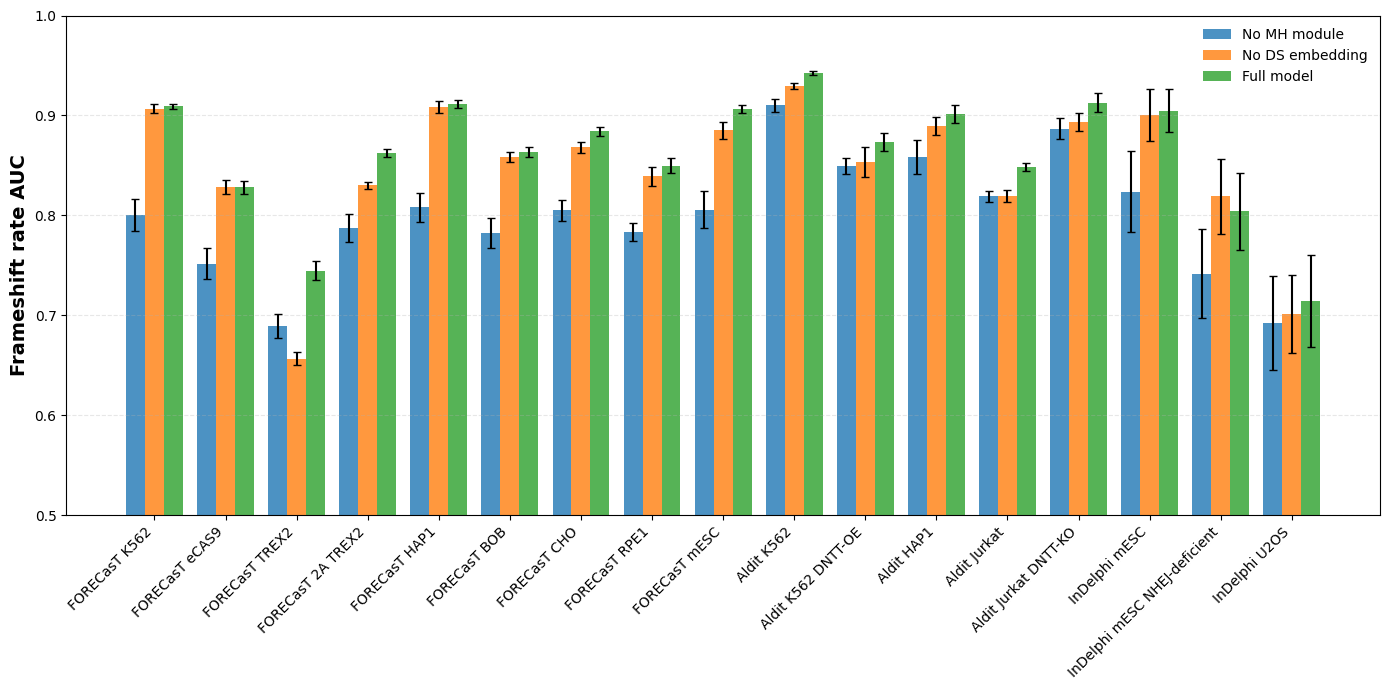

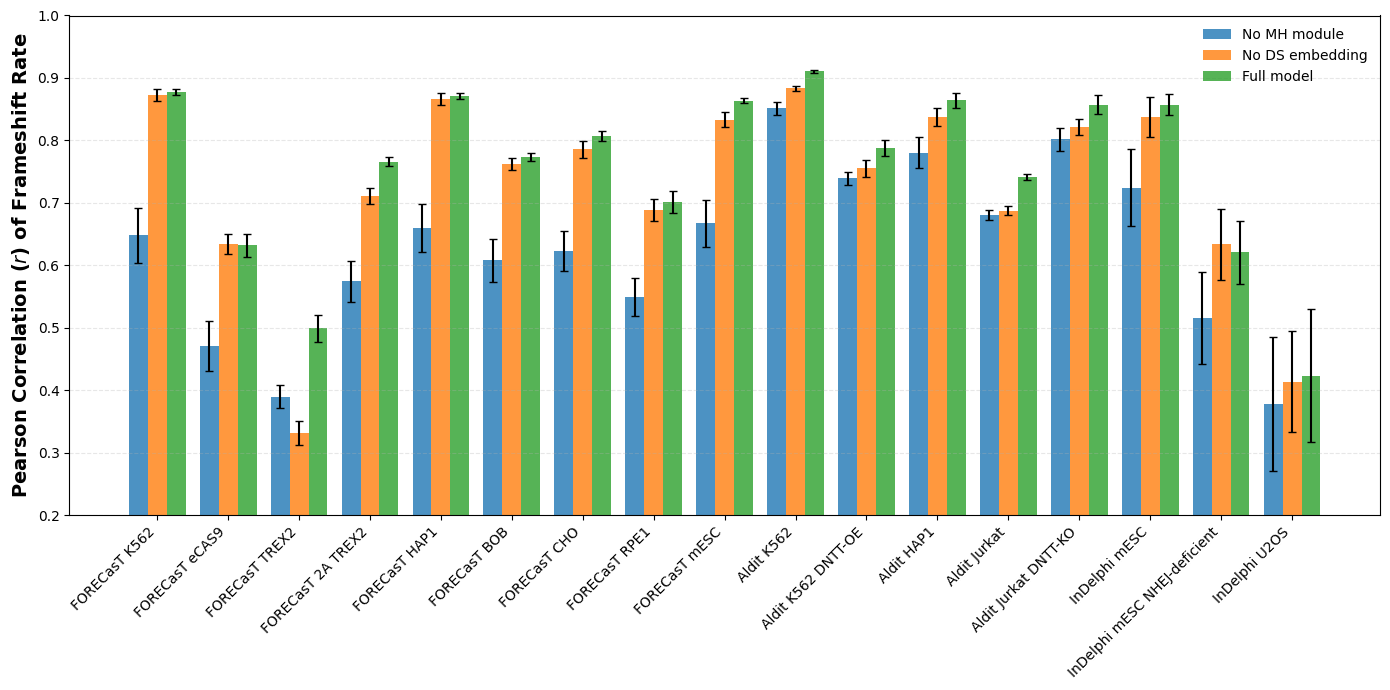

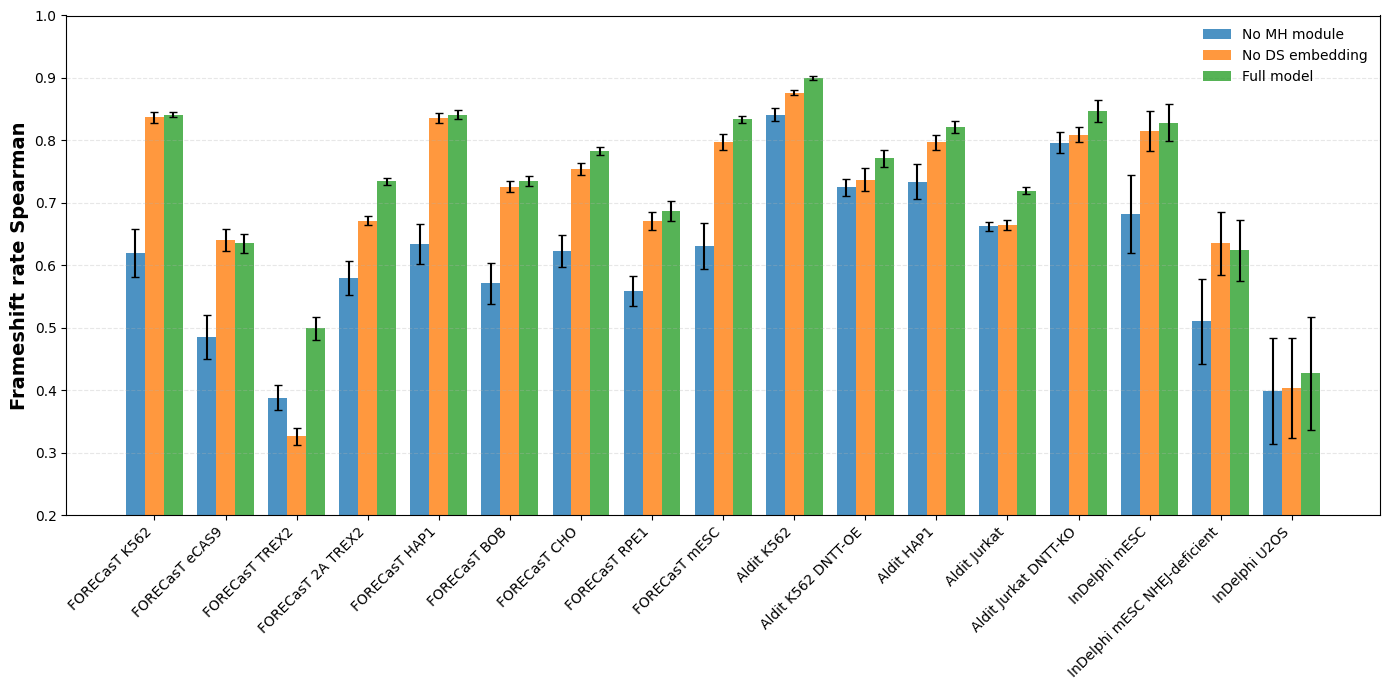

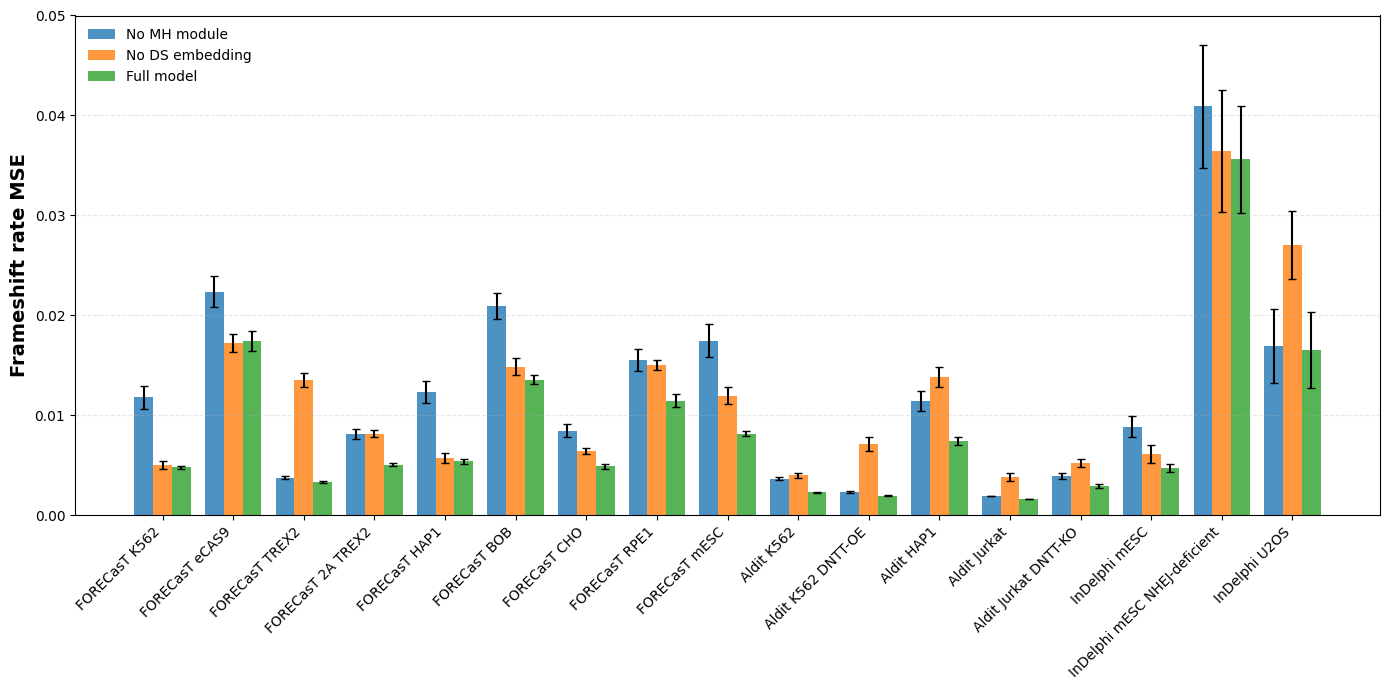

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon
from itertools import combinations

def generate_ablation_plots():
    # 1. Mapping of original CSV row indices to dataset names
    csv_row_to_name = {
        0: "Aldit HAP1", 1: "Aldit Jurkat", 2: "Aldit Jurkat DNTT-KO",
        3: "Aldit K562", 4: "Aldit K562 DNTT-OE", 5: "FORECasT 2A TREX2",
        6: "FORECasT BOB", 7: "FORECasT CHO", 8: "FORECasT HAP1",
        9: "FORECasT K562", 10: "FORECasT RPE1", 11: "FORECasT TREX2",
        12: "FORECasT eCAS9", 13: "FORECasT mESC", 14: "InDelphi U2OS",
        15: "InDelphi mESC", 16: "InDelphi mESC NHEJ-deficient"
    }

    legend_rename = {
        'experiment_twoA': 'No MH module',
        'experiment_twoB': 'No DS embedding',
        'experiment_twoORIG': 'Full model'
    }

    # 2. Target sort order
    target_order = [
        "FORECasT K562", "FORECasT eCAS9", "FORECasT TREX2", "FORECasT 2A TREX2", 
        "FORECasT HAP1", "FORECasT BOB", "FORECasT CHO", "FORECasT RPE1", "FORECasT mESC",
        "Aldit K562", "Aldit K562 DNTT-OE", "Aldit HAP1", "Aldit Jurkat", "Aldit Jurkat DNTT-KO",
        "InDelphi mESC", "InDelphi mESC NHEJ-deficient", "InDelphi U2OS"
    ]

    base_folder = 'AB'
    output_folder = os.path.join('output', 'abalation')
    metrics = ['AUC', 'Pearson', 'Spearman', 'MSE']
    
    y_lims_per_metric = {
        'AUC': (0.5, 1.0),
        'Pearson': (0.2, 1.0),
        'Spearman': (0.2, 1.0),
        'MSE': (0.0, 0.05)
    }


    os.makedirs(output_folder, exist_ok=True)
    
    study_folders = sorted([
        d for d in os.listdir(base_folder) 
        if os.path.isdir(os.path.join(base_folder, d))
    ])
    
    processed_data = {}
    processed_stds = {}

    for study in study_folders:
        mean_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_mean.csv')
        std_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_std.csv')
        
        if os.path.exists(mean_path) and os.path.exists(std_path):
            # Process Means
            df_mean = pd.read_csv(mean_path)
            df_mean['dataset_name'] = df_mean.index.map(csv_row_to_name)
            df_mean = df_mean.set_index('dataset_name').reindex(target_order).reset_index()
            processed_data[study] = df_mean
            
            # Process STDs (Must follow the same reindexing)
            df_std = pd.read_csv(std_path)
            df_std['dataset_name'] = df_std.index.map(csv_row_to_name)
            df_std = df_std.set_index('dataset_name').reindex(target_order).reset_index()
            processed_stds[study] = df_std

    if not processed_data:
        print("No valid CSV data found.")
        return

    # --- STATISTICAL ANALYSIS ---
    stats_summary = []
    for metric in metrics:
        is_higher_better = False if metric == 'MSE' else True
        for s1, s2 in combinations(study_folders, 2):
            data1 = processed_data[s1][metric].values
            data2 = processed_data[s2][metric].values
            try:
                stat, p = wilcoxon(data1, data2)
            except ValueError:
                p = 1.0
            
            mean1, mean2 = np.mean(data1), np.mean(data2)
            if is_higher_better:
                winner = s1 if mean1 > mean2 else s2
            else:
                winner = s1 if mean1 < mean2 else s2
            
            stats_summary.append({
                'Metric': metric, 'Comparison': f"{s1} vs {s2}",
                'P-Value': round(p, 4), 'Significant(0.05)': 'Yes' if p < 0.05 else 'No',
                'Better_Model': winner
            })

    pd.DataFrame(stats_summary).to_csv(os.path.join(output_folder, 'statistical_tests.csv'), index=False)

    # --- PLOTTING ---
    num_datasets = len(target_order)
    num_studies = len(processed_data)
    x = np.arange(num_datasets)
    total_width = 0.8
    bar_width = total_width / num_studies
    
    for metric in metrics:
        plt.figure(figsize=(14, 7))
        for i, study in enumerate(study_folders):
            if study not in processed_data: continue
            
            means = processed_data[study][metric]
            stds = processed_stds[study][metric] # Re-introduced STD
            
            clean_label = legend_rename.get(study, study)
            pos = x - (total_width / 2) + (i * bar_width) + (bar_width / 2)
            
            # Added yerr and capsize to show STDs
            plt.bar(pos, means, bar_width, yerr=stds, capsize=3, label=clean_label, alpha=0.8)
        
        if metric == 'Pearson':
            plt.ylabel('Pearson Correlation ($r$) of Frameshift Rate', fontsize=14, fontweight='bold')
        else:
            plt.ylabel(f'Frameshift rate {metric}', fontsize=14, fontweight='bold')
            
        plt.xticks(x, target_order, rotation=45, ha='right')
        plt.legend(frameon=False)
        plt.ylim(y_lims_per_metric[metric])
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.tight_layout()
        
        file_path = os.path.join(output_folder, f'{metric.lower()}_comparison.pdf')
        plt.savefig(file_path, dpi=300)
        plt.show()
        plt.close()

if __name__ == "__main__":
    generate_ablation_plots()

In [12]:
import os
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def analyze_ablation_stats():
    # 1. Mappings
    csv_row_to_name = {
        0: "Aldit HAP1", 1: "Aldit Jurkat", 2: "Aldit Jurkat DNTT-KO",
        3: "Aldit K562", 4: "Aldit K562 DNTT-OE", 5: "FORECasT 2A TREX2",
        6: "FORECasT BOB", 7: "FORECasT CHO", 8: "FORECasT HAP1",
        9: "FORECasT K562", 10: "FORECasT RPE1", 11: "FORECasT TREX2",
        12: "FORECasT eCAS9", 13: "FORECasT mESC", 14: "InDelphi U2OS",
        15: "InDelphi mESC", 16: "InDelphi mESC NHEJ-deficient"
    }

    legend_rename = {
        'experiment_twoA': 'No MH module',
        'experiment_twoB': 'No DS embedding',
        'experiment_twoORIG': 'Full model'
    }

    base_folder = 'AB'
    metrics = ['AUC', 'Pearson', 'Spearman', 'MSE']
    
    # Identify folders
    study_folders = sorted([
        d for d in os.listdir(base_folder) 
        if os.path.isdir(os.path.join(base_folder, d))
    ])
    
    processed_data = {}

    # 2. Load and Align Data
    for study in study_folders:
        mean_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_mean.csv')
        if os.path.exists(mean_path):
            df = pd.read_csv(mean_path)
            df['dataset_name'] = df.index.map(csv_row_to_name)
            processed_data[study] = df.set_index('dataset_name')

    if not processed_data:
        print("No valid CSV data found.")
        return

    # --- 3. CALCULATE GLOBAL SUMMARY (Mean ± SD) ---
    summary_results = []
    for study, df in processed_data.items():
        res = {'Model': legend_rename.get(study, study)}
        for m in metrics:
            avg = df[m].mean()
            std = df[m].std()
            res[f'{m} Summary'] = f"{avg:.3f} ± {std:.3f}"
        summary_results.append(res)
    
    print("--- Global Model Performance (Across all Datasets) ---")
    print(pd.DataFrame(summary_results).to_string(index=False))
    print("\n" + "="*80 + "\n")

    # --- 4. PAIRWISE WILCOXON (Full Model vs Ablations) ---
    stats_list = []
    full_model_key = 'experiment_twoORIG'
    
    if full_model_key not in processed_data:
        print(f"Error: {full_model_key} not found in data.")
        return

    # Compare Full Model against every other model for every metric
    for metric in metrics:
        full_vals = processed_data[full_model_key][metric].values
        
        for study in processed_data.keys():
            if study == full_model_key: continue
            
            abl_vals = processed_data[study][metric].values
            
            # Wilcoxon Signed-Rank Test (Paired)
            # We test if the 'Full Model' is significantly different from the ablation
            try:
                stat, p = wilcoxon(full_vals, abl_vals)
            except:
                p = 1.0 # In case of zero variance

            stats_list.append({
                'Metric': metric,
                'Comparison': f"{legend_rename[full_model_key]} vs {legend_rename[study]}",
                'Raw_P': p
            })

    # 5. Multiple Comparisons Correction (BH)
    stats_df = pd.DataFrame(stats_list)
    if not stats_df.empty:
        _, p_adj, _, _ = multipletests(stats_df['Raw_P'], method='fdr_bh')
        stats_df['Adj_P'] = p_adj
        stats_df['Sig'] = stats_df['Adj_P'] < 0.05

    print("--- Statistical Tests (Benjamini-Hochberg Corrected) ---")
    print(stats_df.sort_values(by=['Metric', 'Adj_P']).to_string(index=False))

if __name__ == "__main__":
    analyze_ablation_stats()

--- Global Model Performance (Across all Datasets) ---
          Model   AUC Summary Pearson Summary Spearman Summary   MSE Summary
   No MH module 0.800 ± 0.060   0.627 ± 0.136    0.614 ± 0.125 0.012 ± 0.010
No DS embedding 0.846 ± 0.072   0.727 ± 0.156    0.706 ± 0.149 0.012 ± 0.009
     Full model 0.862 ± 0.061   0.756 ± 0.140    0.737 ± 0.129 0.009 ± 0.009


--- Statistical Tests (Benjamini-Hochberg Corrected) ---
  Metric                    Comparison    Raw_P    Adj_P  Sig
     AUC    Full model vs No MH module 0.000015 0.000031 True
     AUC Full model vs No DS embedding 0.000839 0.000839 True
     MSE    Full model vs No MH module 0.000015 0.000031 True
     MSE Full model vs No DS embedding 0.000031 0.000049 True
 Pearson    Full model vs No MH module 0.000015 0.000031 True
 Pearson Full model vs No DS embedding 0.000381 0.000436 True
Spearman    Full model vs No MH module 0.000015 0.000031 True
Spearman Full model vs No DS embedding 0.000381 0.000436 True


In [13]:
import os
import pandas as pd

def analyze_dataset_level_stats():
    # 1. Mappings
    csv_row_to_name = {
        0: "Aldit HAP1", 1: "Aldit Jurkat", 2: "Aldit Jurkat DNTT-KO",
        3: "Aldit K562", 4: "Aldit K562 DNTT-OE", 5: "FORECasT 2A TREX2",
        6: "FORECasT BOB", 7: "FORECasT CHO", 8: "FORECasT HAP1",
        9: "FORECasT K562", 10: "FORECasT RPE1", 11: "FORECasT TREX2",
        12: "FORECasT eCAS9", 13: "FORECasT mESC", 14: "InDelphi U2OS",
        15: "InDelphi mESC", 16: "InDelphi mESC NHEJ-deficient"
    }

    legend_rename = {
        'experiment_twoA': 'No MH module',
        'experiment_twoB': 'No DS embedding',
        'experiment_twoORIG': 'Full model'
    }

    target_order = [
        "FORECasT K562", "FORECasT eCAS9", "FORECasT TREX2", "FORECasT 2A TREX2", 
        "FORECasT HAP1", "FORECasT BOB", "FORECasT CHO", "FORECasT RPE1", "FORECasT mESC",
        "Aldit K562", "Aldit K562 DNTT-OE", "Aldit HAP1", "Aldit Jurkat", "Aldit Jurkat DNTT-KO",
        "InDelphi mESC", "InDelphi mESC NHEJ-deficient", "InDelphi U2OS"
    ]

    base_folder = 'AB'
    metrics = ['AUC', 'Pearson', 'Spearman', 'MSE']
    
    study_folders = sorted([
        d for d in os.listdir(base_folder) 
        if os.path.isdir(os.path.join(base_folder, d))
    ])
    
    # Structure: data[study][metric] = pd.Series (indexed by dataset name)
    means_all = {}
    stds_all = {}

    # 2. Load Data
    for study in study_folders:
        mean_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_mean.csv')
        std_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_std.csv')
        
        if os.path.exists(mean_path) and os.path.exists(std_path):
            df_mean = pd.read_csv(mean_path)
            df_std = pd.read_csv(std_path)
            
            # Map names and reindex
            df_mean['dataset_name'] = df_mean.index.map(csv_row_to_name)
            df_std['dataset_name'] = df_std.index.map(csv_row_to_name)
            
            means_all[study] = df_mean.set_index('dataset_name').reindex(target_order)
            stds_all[study] = df_std.set_index('dataset_name').reindex(target_order)

    if not means_all:
        print("No valid CSV data found.")
        return

    # 3. Print Breakdown per Metric
    for metric in metrics:
        print(f"\n--- Detailed Breakdown for Metric: {metric} (Mean ± SD) ---")
        
        # Build a dataframe for this specific metric
        metric_table = pd.DataFrame(index=target_order)
        
        for study in study_folders:
            if study not in means_all: continue
            
            model_name = legend_rename.get(study, study)
            m_vals = means_all[study][metric]
            s_vals = stds_all[study][metric]
            
            # Combine into "Mean ± SD" string
            metric_table[model_name] = [
                f"{m:.3f} ± {s:.3f}" if pd.notnull(m) else "N/A" 
                for m, s in zip(m_vals, s_vals)
            ]
        
        # Display the table for this metric
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 1000)
        print(metric_table)
        print("-" * 100)

if __name__ == "__main__":
    analyze_dataset_level_stats()


--- Detailed Breakdown for Metric: AUC (Mean ± SD) ---
                               No MH module No DS embedding     Full model
FORECasT K562                 0.801 ± 0.016   0.907 ± 0.005  0.909 ± 0.002
FORECasT eCAS9                0.752 ± 0.015   0.828 ± 0.007  0.828 ± 0.006
FORECasT TREX2                0.689 ± 0.012   0.657 ± 0.007  0.745 ± 0.009
FORECasT 2A TREX2             0.788 ± 0.014   0.830 ± 0.004  0.863 ± 0.004
FORECasT HAP1                 0.808 ± 0.015   0.909 ± 0.006  0.912 ± 0.004
FORECasT BOB                  0.782 ± 0.015   0.858 ± 0.005  0.863 ± 0.005
FORECasT CHO                  0.805 ± 0.011   0.868 ± 0.006  0.884 ± 0.005
FORECasT RPE1                 0.784 ± 0.009   0.839 ± 0.010  0.850 ± 0.007
FORECasT mESC                 0.806 ± 0.019   0.885 ± 0.008  0.906 ± 0.004
Aldit K562                    0.910 ± 0.006   0.929 ± 0.003  0.943 ± 0.002
Aldit K562 DNTT-OE            0.849 ± 0.008   0.853 ± 0.015  0.873 ± 0.009
Aldit HAP1                    0.858 ± 0.017 

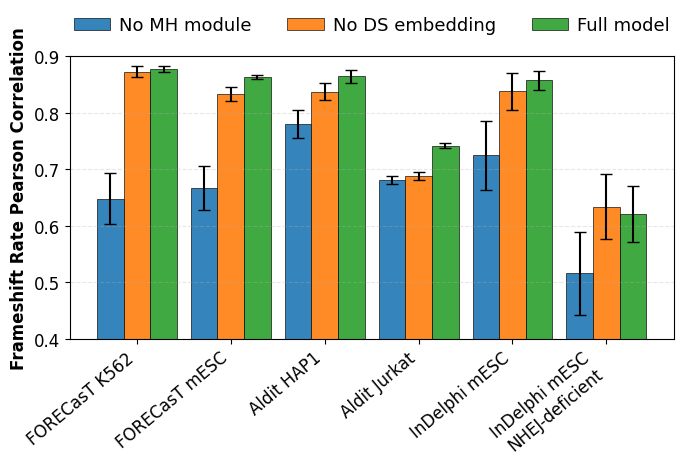

Saved: output\abalation\pearson_comparison_subset_specific.pdf


In [63]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def generate_ablation_plots(selected_datasets=None):
    """
    selected_datasets: List of strings.
    - Legend Renamed: No MH module, No DS embedding, Full model.
    - Narrower layout and larger labels for paper publication.
    """
    
    csv_row_to_name = {
        0: "Aldit HAP1", 1: "Aldit Jurkat", 2: "Aldit Jurkat DNTTKO",
        3: "Aldit K562", 4: "Aldit K562 DNTTOE", 5: "FORECasT 2A TREX2",
        6: "FORECasT BOB", 7: "FORECasT CHO", 8: "FORECasT HAP1",
        9: "FORECasT K562", 10: "FORECasT RPE1", 11: "FORECasT TREX2",
        12: "FORECasT eCAS9", 13: "FORECasT mESC", 14: "InDelphi U2OS",
        15: "InDelphi mESC", 16: "InDelphi mESC\nNHEJ-deficient"
    }

    default_table_order = [
        "FORECasT K562", "FORECasT eCAS9", "FORECasT TREX2", "FORECasT 2A TREX2", 
        "FORECasT HAP1", "FORECasT BOB", "FORECasT CHO", "FORECasT RPE1", "FORECasT mESC",
        "Aldit K562", "Aldit K562 DNTTOE", "Aldit HAP1", "Aldit Jurkat", "Aldit Jurkat DNTTKO",
        "InDelphi mESC", "InDelphi mESC\nNHEJ-deficient", "InDelphi U2OS"
    ]

    legend_rename = {
        'experiment_twoA': 'No MH module',
        'experiment_twoB': 'No DS embedding',
        'experiment_twoORIG': 'Full model'
    }
    
    plot_order = selected_datasets if selected_datasets is not None else default_table_order
    base_folder = 'AB'
    output_folder = os.path.join('output', 'abalation')
    os.makedirs(output_folder, exist_ok=True)
    
    study_folders = sorted([d for d in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, d))])
    
    processed_data = {}
    processed_stds = {}

    for study in study_folders:
        mean_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_mean.csv')
        std_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_std.csv')
        
        if os.path.exists(mean_path) and os.path.exists(std_path):
            df_mean = pd.read_csv(mean_path)
            df_std = pd.read_csv(std_path)
            
            df_mean['dataset_name'] = df_mean.index.map(csv_row_to_name)
            df_std['dataset_name'] = df_std.index.map(csv_row_to_name)
            
            processed_data[study] = df_mean.set_index('dataset_name').reindex(plot_order).reset_index()
            processed_stds[study] = df_std.set_index('dataset_name').reindex(plot_order).reset_index()

    # --- Plotting Adjustments ---
    num_datasets = len(plot_order)
    num_studies = len(processed_data)
    x = np.arange(num_datasets)
    total_width = 0.85
    bar_width = total_width / num_studies
    
    fig_width = max(6, num_datasets * 1.2) 
    plt.figure(figsize=(fig_width, 5))
    
    for i, study in enumerate(study_folders):
        if study not in processed_data: continue
        
        means = processed_data[study]['Pearson']
        stds = processed_stds[study]['Pearson']
        clean_label = legend_rename.get(study, study)
        
        pos = x - (total_width / 2) + (i * bar_width) + (bar_width / 2)
        plt.bar(pos, means, bar_width, yerr=stds, label=clean_label, capsize=4, alpha=0.9, edgecolor='black', linewidth=0.5)
    
    # Text Formatting
    plt.ylabel('Frameshift Rate Pearson Correlation', fontsize=12, fontweight='bold')
    plt.xticks(x, plot_order, rotation=40, ha='right', fontsize=12, fontweight='medium')
    plt.yticks(fontsize=12)
    
    # --- FIXED LEGEND ---
    # ncol=3 makes it 1 row (shorter top-to-bottom)
    # bbox_to_anchor moves it above the plot
    plt.legend(
        fontsize=13, 
        frameon=False, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.02), 
        ncol=3,
        labelspacing=0.1, # Reduces vertical padding between items (though ncol=3 already does this)
        handletextpad=0.5  # Controls distance between icon and text
    )
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.ylim(0.4, 0.9)
    
    # Added rect to tight_layout to ensure the legend above isn't cut off
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    suffix = "subset" if selected_datasets else "full"
    file_path = os.path.join(output_folder, f'pearson_comparison_{suffix}_specific.pdf')
    plt.savefig(file_path, bbox_inches='tight')
    file_path_2 = os.path.join(output_folder, f'pearson_comparison_{suffix}_specific.svg')
    plt.savefig(file_path_2, bbox_inches='tight')
    plt.show()
    print(f"Saved: {file_path}")

# Run
my_subset = ["FORECasT K562", "FORECasT mESC", "Aldit HAP1", "Aldit Jurkat", "InDelphi mESC", "InDelphi mESC\nNHEJ-deficient"]
generate_ablation_plots(selected_datasets=my_subset)

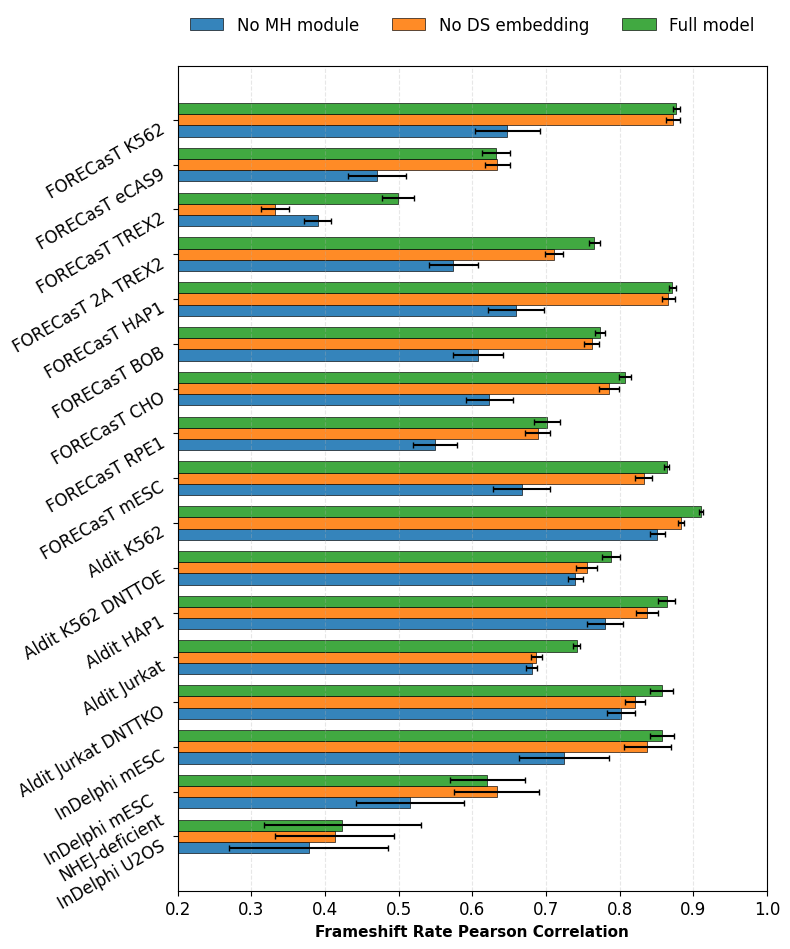

Saved: output\abalation\pearson_comparison_subset_horiz_narrow.svg


In [91]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def generate_ablation_plots(selected_datasets=None):
    csv_row_to_name = {
        0: "Aldit HAP1", 1: "Aldit Jurkat", 2: "Aldit Jurkat DNTTKO",
        3: "Aldit K562", 4: "Aldit K562 DNTTOE", 5: "FORECasT 2A TREX2",
        6: "FORECasT BOB", 7: "FORECasT CHO", 8: "FORECasT HAP1",
        9: "FORECasT K562", 10: "FORECasT RPE1", 11: "FORECasT TREX2",
        12: "FORECasT eCAS9", 13: "FORECasT mESC", 14: "InDelphi U2OS",
        15: "InDelphi mESC", 16: "InDelphi mESC\nNHEJ-deficient"
    }

    default_table_order = [
        "FORECasT K562", "FORECasT eCAS9", "FORECasT TREX2", "FORECasT 2A TREX2", 
        "FORECasT HAP1", "FORECasT BOB", "FORECasT CHO", "FORECasT RPE1", "FORECasT mESC",
        "Aldit K562", "Aldit K562 DNTTOE", "Aldit HAP1", "Aldit Jurkat", "Aldit Jurkat DNTTKO",
        "InDelphi mESC", "InDelphi mESC\nNHEJ-deficient", "InDelphi U2OS"
    ]

    legend_rename = {
        'experiment_twoA': 'No MH module',
        'experiment_twoB': 'No DS embedding',
        'experiment_twoORIG': 'Full model'
    }
    
    plot_order = (selected_datasets if selected_datasets is not None else default_table_order)[::-1]
    
    base_folder = 'AB'
    output_folder = os.path.join('output', 'abalation')
    os.makedirs(output_folder, exist_ok=True)
    
    study_folders = sorted([d for d in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, d))])
    
    processed_data = {}
    processed_stds = {}

    for study in study_folders:
        mean_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_mean.csv')
        std_path = os.path.join(base_folder, study, 'seed_1', 'cross_val_report_std.csv')
        
        if os.path.exists(mean_path) and os.path.exists(std_path):
            df_mean = pd.read_csv(mean_path)
            df_std = pd.read_csv(std_path)
            df_mean['dataset_name'] = df_mean.index.map(csv_row_to_name)
            df_std['dataset_name'] = df_std.index.map(csv_row_to_name)
            processed_data[study] = df_mean.set_index('dataset_name').reindex(plot_order).reset_index()
            processed_stds[study] = df_std.set_index('dataset_name').reindex(plot_order).reset_index()

    # --- Plotting Adjustments ---
    num_datasets = len(plot_order)
    num_studies = len(processed_data)
    y = np.arange(num_datasets)
    
    # NARROWER BARS: total_height decreased (e.g., 0.7 or 0.75) to leave more space between groups
    total_height = 0.75 
    bar_height = total_height / num_studies
    
    # Increase figure height slightly to maintain readability with more datasets
    fig_height = max(6, num_datasets * 0.6) 
    plt.figure(figsize=(8, fig_height)) 
    
    for i, study in enumerate(study_folders):
        if study not in processed_data: continue
        
        means = processed_data[study]['Pearson']
        stds = processed_stds[study]['Pearson']
        clean_label = legend_rename.get(study, study)
        
        pos = y - (total_height / 2) + (i * bar_height) + (bar_height / 2)
        plt.barh(pos, means, bar_height, xerr=stds, label=clean_label, capsize=2, alpha=0.9, edgecolor='black', linewidth=0.5)
    
    # Text Formatting
    plt.xlabel('Frameshift Rate Pearson Correlation', fontsize=11, fontweight='bold')
    plt.yticks(y, plot_order, fontsize=12, rotation=30, va='top')
    plt.xticks(fontsize=12)
    
    # Legend: Moved definitively ABOVE the plot area
    plt.legend(
        fontsize=12, 
        frameon=False, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.02), # 1.02 ensures it is clearly above the axes
        ncol=3 
    )
    
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.xlim(0.2, 1.0)
    
    # Adjust rect top to 0.94 to provide enough room for the legend above the plot
    plt.tight_layout(rect=[0, 0, 1, 0.94]) 
    
    suffix = "subset_horiz_narrow" if selected_datasets else "full_horiz_narrow"
    file_path = os.path.join(output_folder, f'pearson_comparison_{suffix}.svg')
    plt.savefig(file_path, bbox_inches='tight')
    plt.show()
    print(f"Saved: {file_path}")

# Run
my_subset = [
        "FORECasT K562", "FORECasT eCAS9", "FORECasT TREX2", "FORECasT 2A TREX2", 
        "FORECasT HAP1", "FORECasT BOB", "FORECasT CHO", "FORECasT RPE1", "FORECasT mESC",
        "Aldit K562", "Aldit K562 DNTTOE", "Aldit HAP1", "Aldit Jurkat", "Aldit Jurkat DNTTKO",
        "InDelphi mESC", "InDelphi mESC\nNHEJ-deficient", "InDelphi U2OS"
    ]
generate_ablation_plots(selected_datasets=my_subset)